# Photonic Crystal Slab Template

## Configuration

In [7]:
root = r"/zhome/2f/7/202918/phc_nzi"
src = r"/zhome/2f/7/202918/phc_nzi/src"
import sys
sys.path.append(root)
sys.path.append(src)

## Define the materials
from phc_nzi.photonic_crystal_maker import (Material, Geometry, PhotonicCrystal, 
                                        ScriptParam, ScriptParamVector3, BaseDielectricDistribution,
                                        HexagonalLattice)
import meep as mp
from phc_nzi.mpb_configurator import *
from phc_nzi.mpi_differential_evolution import MPIdeOptimizator
from phc_nzi.simulation_handler import LSFJobConfiguration, MPBDataOptions, Simulation
from phc_nzi.optimization_data_analyzer import OptimizationDataAnalyzer
from phc_nzi.simulation_viewer import SimulationViewer
from phc_nzi.lsf_sweeper import LSFSweeper

import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
from matplotlib.patches import FancyArrow
from matplotlib.legend_handler import HandlerPatch
import ipywidgets as widgets
from IPython.display import display
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches



plt.rcParams["font.size"] = 15

T = 4
n_InP = 3.075*(1+2.7e-5*T)
print(n_InP)
eps_inp = round(n_InP**2,2)
print("Epsilon of InP: ", eps_inp)

inp = Material(epsilon = eps_inp)
air = Material(epsilon = 1)
## Simulation Name: 
name = "C4v_diatomic_holes_1"

## Define the geometry
radius1 = ScriptParam("r1", 0.3)
radius2 = ScriptParam("r2", 0.2)
height_supercell = 3
height_slab = ScriptParam("h", 0.4)
slab_block_size = ScriptParamVector3(1e20, 1e20, "h", z_def = 0.4)

## Define the lattice

lattice_2D = SquareLattice()
lattice_slab = SquareLattice(supercell_height= 4)

k_points = lattice_2D.get_high_symmetry_k_points(centered_in_gamma=True)
distance = 0.1
k_points_around_gamma = lattice_2D.get_k_points_around_gamma(distance = distance)

print(k_points)


center = mp.Vector3(0,0,0)


geom_2D = BaseDielectricDistribution(eps_bulk = eps_inp, eps_atoms=1).make_C4v_diatomic_B()
geom_slab = BaseDielectricDistribution(eps_bulk = eps_inp, eps_atoms = 1, height_slab=0.5).make_C4v_diatomic_B()


photonic_crystal_2D = PhotonicCrystal(lattice=lattice_2D, atoms=geom_2D)
photonic_crystal_slab = PhotonicCrystal(lattice=lattice_slab, atoms=geom_slab)

RESOLUTION = 32
## Define the simulation
configuration_options_2D = dict(
    resolution = RESOLUTION,
    num_bands=8,
    k_points=k_points["k_points_values"],
    k_points_interpolation_factor = 30,
    extra_runner_command = "fix-hfield-phase output-hfield output-efield",
)

configuration_options_2D_optimized = dict(
    resolution = RESOLUTION,
    num_bands=8,
    k_points=k_points_around_gamma["k_points_values"],
    k_points_interpolation_factor = 10,
    extra_runner_command = "fix-hfield-phase output-hfield output-efield",
)



configuration_options_slab = dict(
    resolution = RESOLUTION,
    num_bands=15,
    k_points=k_points["k_points_values"],
    k_points_interpolation_factor = 10,
    extra_runner_command = "(output-at-kpoint (vector3 0 0 0) fix-hfield-phase output-hfield)",
)

configuration_options_slab_centered = dict(
    resolution = RESOLUTION,
    num_bands=15,
    k_points=k_points_around_gamma["k_points_values"],
    k_points_interpolation_factor = 10,
    extra_runner_command = "(output-at-kpoint (vector3 0 0 0) fix-hfield-phase output-hfield)",
)


configuration_options_optimization = dict(
    resolution = RESOLUTION,
    num_bands=8,
    k_points = [mp.Vector3(0,0,0)],
    
)

configuration_options_sweep = dict( 
    resolution = RESOLUTION,
    num_bands=10,
    k_points=[mp.Vector3(0,0,0)],
)


mpb_configuration_2D = MPBSchemeConfigurator(photonic_crystal_2D, ["te", "tm"], **configuration_options_2D)
mpb_configuration_slab = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven"], **configuration_options_slab)
mpb_configuration_2D_opt = MPBSchemeConfigurator(photonic_crystal_2D, ["te"], **configuration_options_optimization)
mpb_configuration_2D_optimized = MPBSchemeConfigurator(photonic_crystal_2D, ["te"], **configuration_options_2D_optimized)
mpb_configuration_2D_sweep = MPBSchemeConfigurator(photonic_crystal_2D, ["te"], **configuration_options_sweep)
mpb_configuration_slab_opt = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven"], **configuration_options_optimization)
mpb_configuration_slab_sweep = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven"], **configuration_options_sweep)
mpb_configuration_slab_opt_centered = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven"], **configuration_options_slab_centered)

script_2D = mpb_configuration_2D.get_scheme_config(join_newline=True)
script_slab = mpb_configuration_slab.get_scheme_config(join_newline=True)
script_2D_opt = mpb_configuration_2D_opt.get_scheme_config(join_newline=True)
script_2D_optimized = mpb_configuration_2D_optimized.get_scheme_config(join_newline=True)
script_2D_sweep = mpb_configuration_2D_sweep.get_scheme_config(join_newline=True)
script_slab_opt = mpb_configuration_slab_opt.get_scheme_config(join_newline=True)
script_slab_sweep = mpb_configuration_slab_sweep.get_scheme_config(join_newline=True)
script_slab_opt_centered = mpb_configuration_slab_opt_centered.get_scheme_config(join_newline=True)




name_2D = name  + "_2D"
name_slab = name + "_slab"


name_2D_opt = name + "_2D_opt"
name_2D_sweep = name + "_2D_sweep"

name_slab_opt = name + "_slab_opt"
name_slab_sweep = name + "_slab_sweep"
name_slab_opt_centered = name + "_slab_opt_centered"

name_2D_optimized = name + "_2D_optimized"

data_rooth = "/work3/enrva/phc_nzi_data/MPB_data"
if not os.path.exists(data_rooth):
    os.makedirs(data_rooth)

simulation_2D = Simulation(
    simulation_name=name_2D,
    script = script_2D,
    directory= os.path.join(data_rooth, name_2D)
    )

simulation_2D_opt_456 = Simulation(
    simulation_name=name_2D_opt + "_456",
    script = script_2D_opt +"_456",
    directory= os.path.join(data_rooth, name_2D_opt + "_456")
    )

simulation_2D_opt_345 = Simulation(
    simulation_name=name_2D_opt + "_345",
    script = script_2D_opt +"_345",
    directory= os.path.join(data_rooth, name_2D_opt + "_345")
    )

simulation_2D_sweep = Simulation(
    simulation_name=name_2D_sweep,
    script = script_2D_sweep,
    directory= os.path.join(data_rooth, name_2D_sweep)
    )

simulation_2D_optimized = Simulation(
    simulation_name=name_2D_optimized,
    script = script_2D_optimized,
    directory= os.path.join(data_rooth, name_2D_optimized)
    )


simulation_slab = Simulation(
    simulation_name=name_slab,
    script = script_slab,
    directory= os.path.join(data_rooth, name_slab)
    )


simulation_slab_opt = Simulation(
    simulation_name=name_slab_opt,
    script = script_slab_opt,
    directory= os.path.join(data_rooth, name_slab_opt)  
    )

simulation_slab_opt_centered = Simulation(
    simulation_name=name_slab_opt_centered,
    script = script_slab_opt_centered,
    directory= os.path.join(data_rooth, name_slab_opt_centered)  
    )

simulation_slab_sweep = Simulation(
    simulation_name=name_slab_sweep,
    script = script_slab_sweep,
    directory= os.path.join(data_rooth, name_slab_sweep)  
    )


numproc= 32
pop = numproc // 2
lsf_config = LSFJobConfiguration(num_processors=numproc, span_option="hosts", span_value=1, queue="fotonano",   mem = "1GB")

figure_path = "figures"


3.0753321000000002
Epsilon of InP:  9.46
{'k_points_values': [Vector3<0.5, 0.0, 0.0>, Vector3<0.0, 0.0, 0.0>, Vector3<0.5, 0.5, 0.0>, Vector3<0.5, 0.0, 0.0>], 'k_points_labels': ['X', '$\\Gamma$', 'M', 'X']}
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 0.5)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 0.5)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 0.5)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 0.5)', '(define-param r1 0.1)', '(define-param r2 0.2)']


In [63]:
# Dictionary of standard scientific plotting parameters
publication_params = {
    # --- Figure Dimensions & Output ---
    "figure.figsize": (3.5, 2.625), # 3.5 inches is standard for a single-column width
    "figure.dpi": 300,              # High resolution for rasterized rendering
    "savefig.bbox": "tight",        # Prevents clipping of axis labels
    "savefig.pad_inches": 0.05,     # Removes excess white space margins
    
    # --- Fonts & Text ---
    "font.family": "serif",         # Serif fonts are standard for academic papers
    "font.serif": ["DejaVu Serif", "Liberation Serif", "Times New Roman", "Computer Modern Roman"],
    "font.size": 10,                # Match the document text size (usually 10pt)
    "axes.labelsize": 10,           # Axis label size
    "axes.titlesize": 10,           # Plot title size
    "xtick.labelsize": 8,           # X-axis tick label size
    "ytick.labelsize": 8,           # Y-axis tick label size
    "legend.fontsize": 8,           # Legend text size
    
    # --- Axes & Lines ---
    "axes.linewidth": 1.0,          # Thicker bounding box
    "lines.linewidth": 1.1,         # Thicker lines for visibility when printed
    "lines.markersize": 4,          # Clear, readable data markers
    
    # --- Ticks ---
    "xtick.direction": "in",        # Ticks point inward (standard in science)
    "ytick.direction": "in",
    "xtick.top": True,              # Top axis ticks visible
    "ytick.right": True,            # Right axis ticks visible
    "xtick.minor.visible": True,    # Enable minor ticks for precision
    "ytick.minor.visible": True,
    
    # --- Legend ---
    "legend.frameon": False,        # Remove the box around the legend to save ink
    
    # --- Mathtext / LaTeX ---
    "mathtext.fontset": "cm",       # Computer Modern for math rendering
    # "text.usetex": True,          # Uncomment if you have a local LaTeX engine installed!
}

# Apply the configurations globally
plt.rcParams.update(publication_params)

WIDTH_1 = 3.5
HEIGHT_1 = 2.625
ROW1_COL1_SIZE = (WIDTH_1, HEIGHT_1) # 3.5 inches is standard for a single-column width
ROW1_COL2_SIZE = (WIDTH_1*2, HEIGHT_1)
ROW1_COL3_SIZE = (WIDTH_1*3, HEIGHT_1)
ROW1_COL15_SIZE = (WIDTH_1*1.5, HEIGHT_1)
ROW2_COL2_SIZE = (WIDTH_1*2, HEIGHT_1*2)

In [3]:

# --- Arrow colors ---
COLOR_RE = 'black'
COLOR_IM = '#00E676'        # bright green
EDGE_RE  = 'white'
EDGE_IM  = 'black'

# # Build a parameter-stamped subfolder: figures/r1_XXXX_r2_XXXX_eps_XX
# param_tag = f"r1_{r1:.4f}_r2_{r2:.4f}_eps_{eps_inp:.2f}"
# SAVE_DIR = os.path.join(os.path.dirname(os.path.abspath(".")), "phd", "figures", param_tag)
# os.makedirs(SAVE_DIR, exist_ok=True)
# print(f"Saving figures to: {SAVE_DIR}")


class ArrowHandler(HandlerPatch):
    """Custom legend handler that draws an arrow instead of a rectangle."""
    def create_artists(self, legend, orig_handle, xdescent, ydescent,
                       width, height, fontsize, trans):
        arrow = FancyArrow(
            xdescent, ydescent + height / 2,
            width * 0.9, 0,
            width=height * 0.35,
            head_width=height * 0.9,
            head_length=width * 0.25,
            fc=orig_handle.get_facecolor(),
            ec=orig_handle.get_edgecolor(),
            linewidth=0.8,
            transform=trans
        )
        return [arrow]


def add_arrow_legend(fig_or_ax, is_figure=False, **kwargs):
    """Add arrow-style legend for Re/Im E_parallel."""
    arrow_re = FancyArrow(0, 0.5, 0.5, 0, width=0.08,
                          head_width=0.25, head_length=0.12,
                          fc=COLOR_RE, ec=EDGE_RE)
    arrow_im = FancyArrow(0, 0.5, 0.5, 0, width=0.08,
                          head_width=0.25, head_length=0.12,
                          fc=COLOR_IM, ec=EDGE_IM)
    target = fig_or_ax.legend if is_figure else fig_or_ax.legend
    return target(
        [arrow_re, arrow_im],
        [r'$\mathrm{Re}(E_{\parallel})$', r'$\mathrm{Im}(E_{\parallel})$'],
        handler_map={FancyArrow: ArrowHandler()},
        ncol=2, 
        framealpha=0.95, facecolor='white', edgecolor='black',
        **kwargs
    )


def plot_field_quiver_on_ax(sim, conv_opt: MPBDataOptions = MPBDataOptions(rectify=True, periods=1, transpose=False),
                            mode: str = "te", k_idx: int = 12, b_idx: int = 0, ax=None):
    """Plot H_z background with E-field quiver arrows on a given axes."""

    if ax is None: 
        ax = plt.gca()
    
    if mode.lower() == "te":
        field_z = sim.load_and_convert_field_data(
            k_idx, b_idx, "z", mode, "h", conversion_options=conv_opt)
        field_x = sim.load_and_convert_field_data(
            k_idx, b_idx, "x", mode, "e", conversion_options=conv_opt)
        field_y = sim.load_and_convert_field_data(
            k_idx, b_idx, "y", mode, "e", conversion_options=conv_opt)
    elif mode.lower() == "tm":
        field_z = sim.load_and_convert_field_data(
            k_idx, b_idx, "z", mode, "e", conversion_options=conv_opt)
        field_x = sim.load_and_convert_field_data(
            k_idx, b_idx, "x", mode, "h", conversion_options=conv_opt)
        field_y = sim.load_and_convert_field_data(
            k_idx, b_idx, "y", mode, "h", conversion_options=conv_opt)
    else:
        raise ValueError(f"Unsupported mode: {mode}. Use 'te' or 'tm'.")

    field_z_real = np.real(field_z)
    vmax_h = np.max(np.abs(field_z_real))
    im = ax.imshow(field_z_real, interpolation='spline36', cmap="RdBu_r",
                   vmin=-vmax_h, vmax=vmax_h, origin='lower')

    step = 2
    ny, nx = field_z.shape
    x = np.arange(nx)
    y = np.arange(ny)
    X, Y = np.meshgrid(x, y)
    X_sub = X[::step, ::step]
    Y_sub = Y[::step, ::step]

    field_x_r = np.real(field_x)[::step, ::step]
    field_y_r = np.real(field_y)[::step, ::step]
    field_x_i = np.imag(field_x)[::step, ::step]
    field_y_i = np.imag(field_y)[::step, ::step]

    mag_real = np.sqrt(field_x_r**2 + field_y_r**2)
    mag_imag = np.sqrt(field_x_i**2 + field_y_i**2)
    max_mag = max(mag_real.max(), mag_imag.max())
    arrow_scale = max_mag * 15

    ax.quiver(X_sub, Y_sub, field_x_r, field_y_r,
              color=COLOR_RE, edgecolor=EDGE_RE, linewidth=0.3,
              scale=arrow_scale, width=0.004, headwidth=4, headlength=4)

    offset = 0.3
    ax.quiver(X_sub + offset, Y_sub + offset, field_x_i, field_y_i,
              color=COLOR_IM, edgecolor=EDGE_IM, linewidth=0.3,
              scale=arrow_scale, width=0.004, headwidth=4, headlength=4)

    try:
        eps_data = simulation_2D_optimized.load_and_convert_epsilon_data(options=conv_opt)
        ax.contour(eps_data, levels=[eps_data.max() * 0.5],
                   colors='gray', linewidths=1.5, linestyles='--',
                   alpha=0.7, origin='lower')
    except Exception:
        pass

    ax.set_xlabel("x (grid pts)")
    ax.set_ylabel("y (grid pts)")
    ax.set_xlim(0, nx)
    ax.set_ylim(0, ny)
    ax.set_aspect('equal')
    return im


# # ============================================================
# # 1) Save each band as a separate figure (no title, with cbar)
# # ============================================================
# band_indices = [4, 5, 6]
# for b_idx in band_indices:
#     fig_s, ax_s = plt.subplots(figsize=(7, 6))
#     im_s = plot_field_quiver_on_ax(simulation_2D_optimized, k_idx = 12, b_idx=b_idx, ax=ax_s)
#     plt.colorbar(im_s, ax=ax_s, label=r"$H_{z}$ (real part, a.u.)",
#                  shrink=0.82, pad=0.02, aspect=25)
#     _add_arrow_legend(ax_s, loc='upper right')
#     fig_s.tight_layout()
#     fname = os.path.join(SAVE_DIR, f"mode_profile_TE_band_{b_idx}_{param_tag}.png")
#     fig_s.savefig(fname, dpi=200, bbox_inches='tight')
#     plt.close(fig_s)
#     print(f"Saved → {fname}")


# # ============================================================
# # 2) Combined figure with 3 subplots (with title)
# # ============================================================
# fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))

# for ax, b_idx in zip(axes, band_indices):
#     im = plot_field_quiver_on_ax(simulation_2D_optimized, k_idx = 12, b_idx=b_idx, ax=ax)
#     ax.set_title(f"TE Band {b_idx}", fontsize=14)

# # Layout: leave room for suptitle on top, legend at bottom, colorbar right
# fig.subplots_adjust(left=0.05, right=0.87, bottom=0.13, top=0.85, wspace=0.30)

# # Shared colorbar
# cbar_ax = fig.add_axes([0.89, 0.13, 0.015, 0.72])
# fig.colorbar(im, cax=cbar_ax, label=r"$H_{z}$ (real part, a.u.)")

# # Arrow legend — top right
# _add_arrow_legend(fig, is_figure=True,
#                   loc='upper right',
#                   bbox_to_anchor=(0.88, 0.97))

# fig.suptitle(
#     r"Bloch mode fields close to degeneracy point — 2D $C_{4v}$ diatomic"
#     + "\n" + data_line,
#     fontsize=fontsize_title, y=0.97
# )

# fname_combined = os.path.join(SAVE_DIR, f"mode_profiles_combined_{param_tag}.png")

# fig.savefig(fname_combined, dpi=200, bbox_inches='tight')
# print(f"Saved → {fname_combined}")
# plt.show()


## 2D
### Unoptimized


Epsilon loaded max value:  9.46


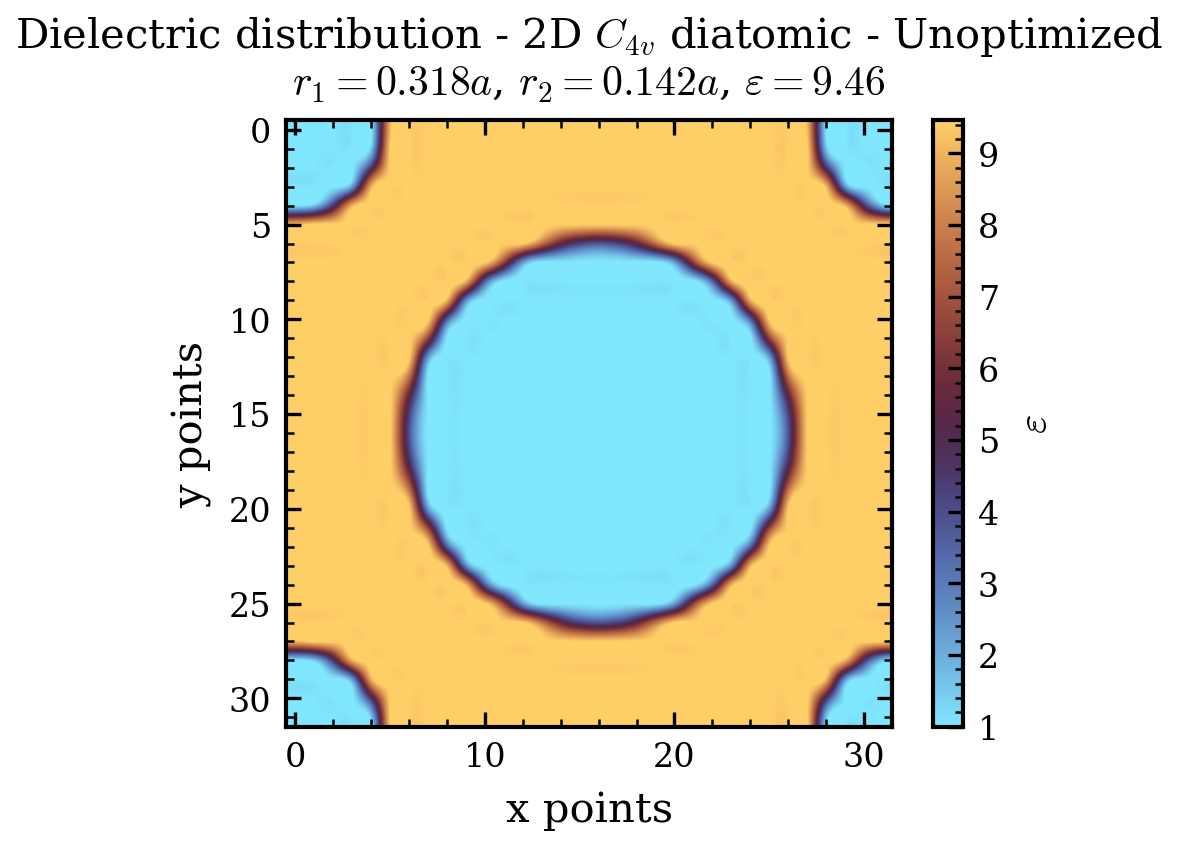

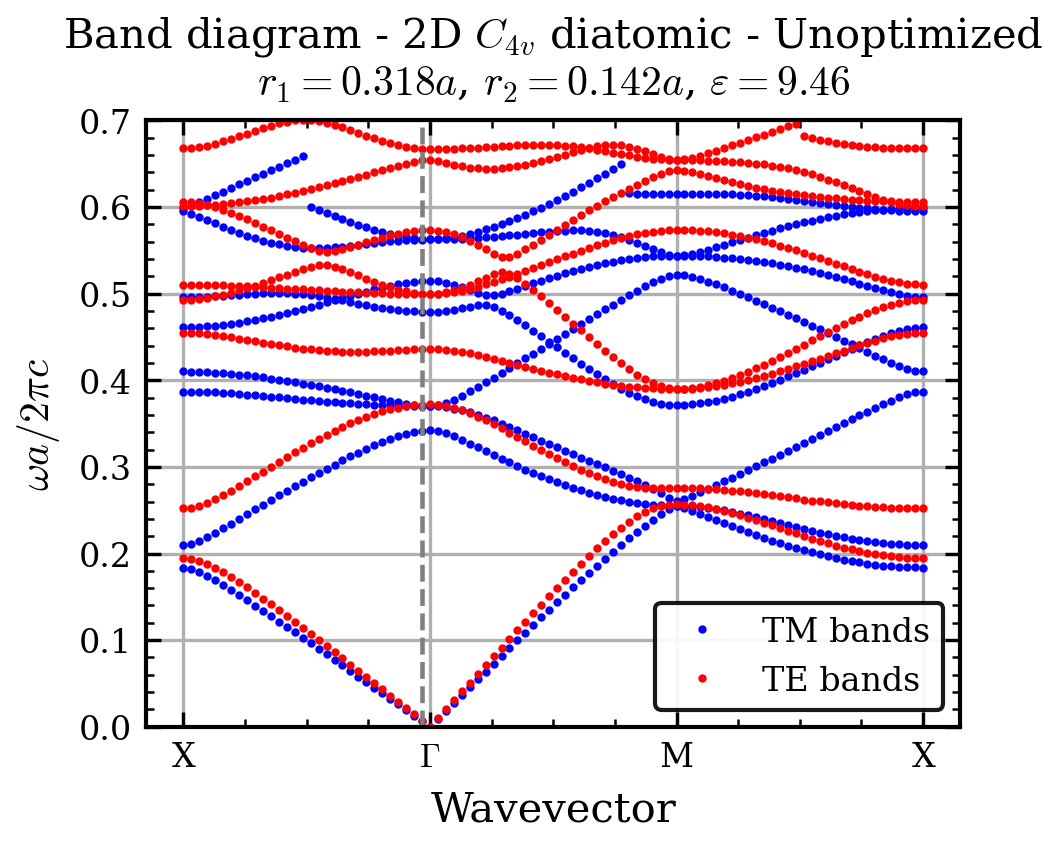

/tmp/ipykernel_1994490/1400022611.py:94: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=max(bottom_margin, 0.12))


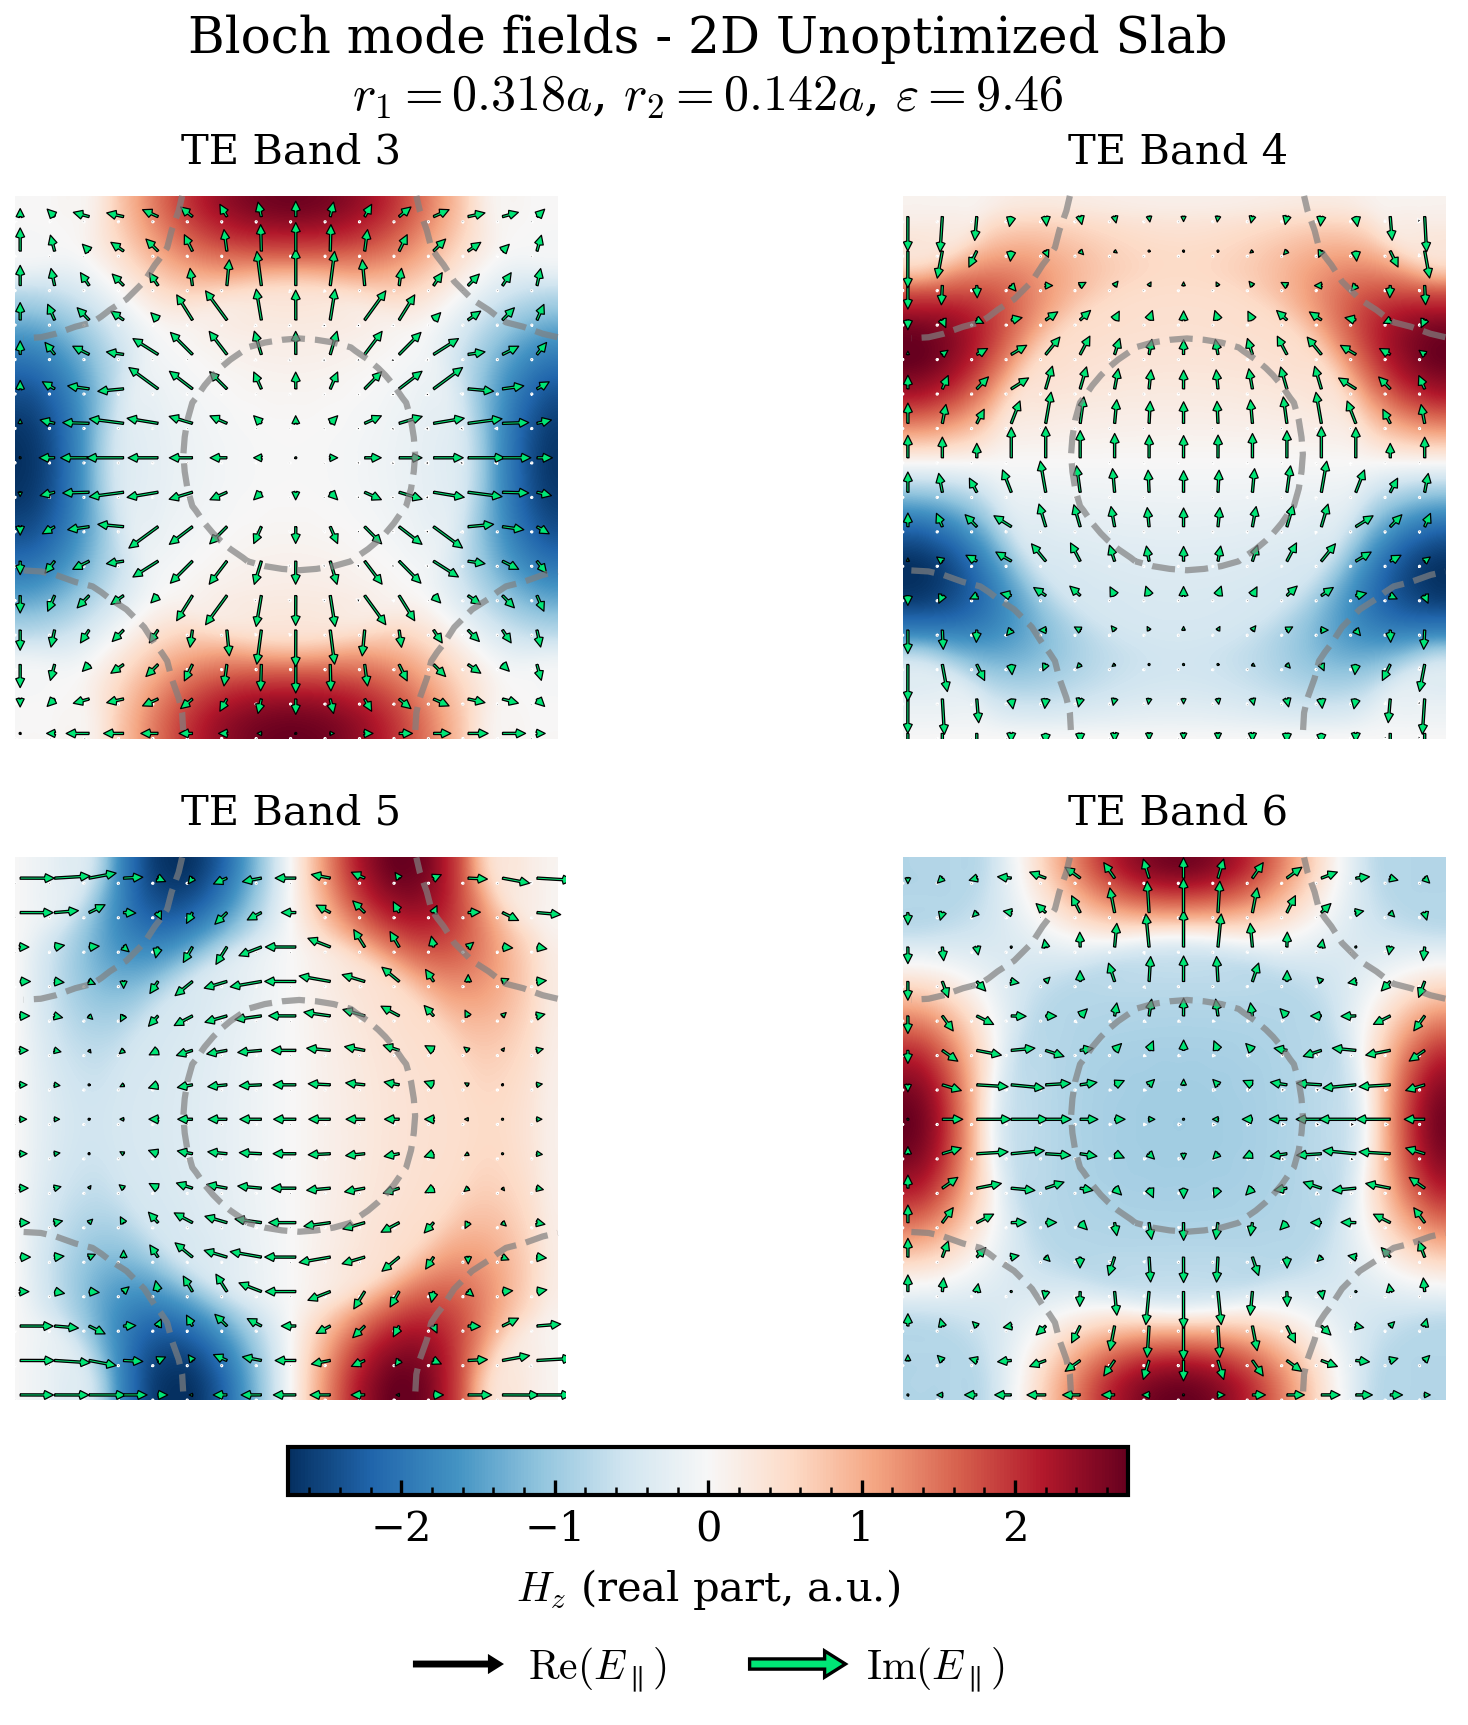

In [70]:
from mpl_toolkits.axes_grid1 import make_axes_locatable


r1 = 0.317578
r2 = 0.142463
SIMULATE_UNOPTIMIZED =  False

fig_folder = os.path.join(figure_path, name_2D + "_unoptimized")
os.makedirs(fig_folder, exist_ok=True)

# make a new simulation just for this purpose, to avoid overwriting the original one with the new parameters


simulation_2D_unoptimized = Simulation(
    simulation_name=name_2D + "_unoptimized",
    script = script_2D,
    directory= os.path.join(data_rooth, name_2D + "_unoptimized")
    )
if SIMULATE_UNOPTIMIZED is True:
    print("2D simulation started")
    simulation_2D_unoptimized.run_hpc(mpb_command_line_params=dict(r1 = r1, r2 = r2), mpi = True)
    print("Done.")
print("Collecting results forom ", simulation_2D_unoptimized.directory)
viewer_2D = SimulationViewer(simulation_2D_unoptimized) 
opt = MPBDataOptions(rectify=True, periods= 1)
viewer_2D.figure()
viewer_2D.plot_epsilon_2d(conversion_options=opt, cmap="managua_r")
eps_loaded = simulation_2D_unoptimized.load_and_convert_epsilon_data(options=opt)
print("Epsilon loaded max value: ", eps_loaded.max()) 
plt.xlabel("x points")
plt.ylabel("y points")
data_line = rf"$r_1={r1:0.3f}a$, $r_2={r2:0.3f}a$, $\varepsilon={eps_inp}$"
plt.title("Dielectric distribution - 2D $C_{4v}$ diatomic - Unoptimized\n" + data_line)
plt.savefig(os.path.join(fig_folder, "dielectric_distribution"))
viewer_2D.show()

plt.figure()
plot_options = dict(linestyle='', marker='o', markersize=1)
viewer_2D.plot_band_diagram("tm", k_points_path=k_points, color = "blue", plot_options=plot_options)
viewer_2D.plot_band_diagram("te", k_points_path=k_points, color = "red", plot_options=plot_options)
plt.ylabel("$\omega a/2\pi c$")
plt.title("Band diagram - 2D $C_{4v}$ diatomic - Unoptimized\n" + data_line)
ymin, ymax = plt.ylim(0,0.7)
df = simulation_2D_unoptimized.load_frequency_data("te")

# find the set with k1 nonzero and k2 zero, which corresponds to the path along Gamma-X, where the degeneracy occurs
df2 = df[df["k2"] == 0]
# find "k index" fot the smallest nonzero k1 in df2, which corresponds to the point closest to Gamma along the Gamma-X path
df_target_idx = df2[df2["k1"] > 0]["k1"].idxmin() 
k_idx_for_field_plot = df2.loc[df_target_idx, "k index"]

plt.vlines(k_idx_for_field_plot, ymin, ymax, colors="gray", linestyles="--", label=None)
plt.savefig(os.path.join(fig_folder, "band_diagram"))
viewer_2D.show()

df_te = simulation_2D_unoptimized.load_frequency_data("te")


# Plot TE bands 3, 4, 5, 6 in a 2x2 grid (band 6 gets its own panel)
fig, axes = plt.subplots(2, 2, figsize=(ROW2_COL2_SIZE), constrained_layout=True)
band_indices = [3, 4, 5, 6]
axes_flat = axes.flatten()

# Plot bands 3, 4, 5, 6
for ax, b_idx in zip(axes_flat[:4], band_indices):
    im = plot_field_quiver_on_ax(
        simulation_2D_unoptimized,
        mode="te",
        k_idx=k_idx_for_field_plot,
        b_idx=b_idx,
        ax=ax
    )
    ax.set_title(f"TE Band {b_idx}")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_aspect('equal')
    ax.axis('off')

# Shared colorbar for all panels, placed at the bottom center, but not spanning the full width

# Get the position of the bottom row of axes for reference
bottom_axes = axes[1, :]


# Disable constrained layout and reserve space for the horizontal colorbar so it doesn't overlap plots
cbar_width = 0.4
cbar_height = 0.03
cbar_left = 0.5 - cbar_width / 2
cbar_bottom = 0.05
fig.set_constrained_layout(False)
bottom_margin = cbar_bottom + cbar_height + 0.02
fig.subplots_adjust(bottom=max(bottom_margin, 0.12))

# Add colorbar axes and create the shared horizontal colorbar
cbar_ax = fig.add_axes([cbar_left, cbar_bottom, cbar_width, cbar_height])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal') 
cbar.set_label(r"$H_{z}$ (real part, a.u.)")
# increase the font size of the colorbar ticks
cbar.ax.tick_params(labelsize=10)
# increase the font size of the colorbar label
cbar.ax.xaxis.label.set_size(10)

# Arrow legend at the lower center, below the colorbar
add_arrow_legend(
    fig,
    is_figure=True,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.1),
    fontsize=10
)

fig.suptitle(
    r"Bloch mode fields - 2D Unoptimized Slab"
    + "\n" + data_line,
    y=0.99
)


plt.savefig(os.path.join(fig_folder, "modes"))
plt.show()

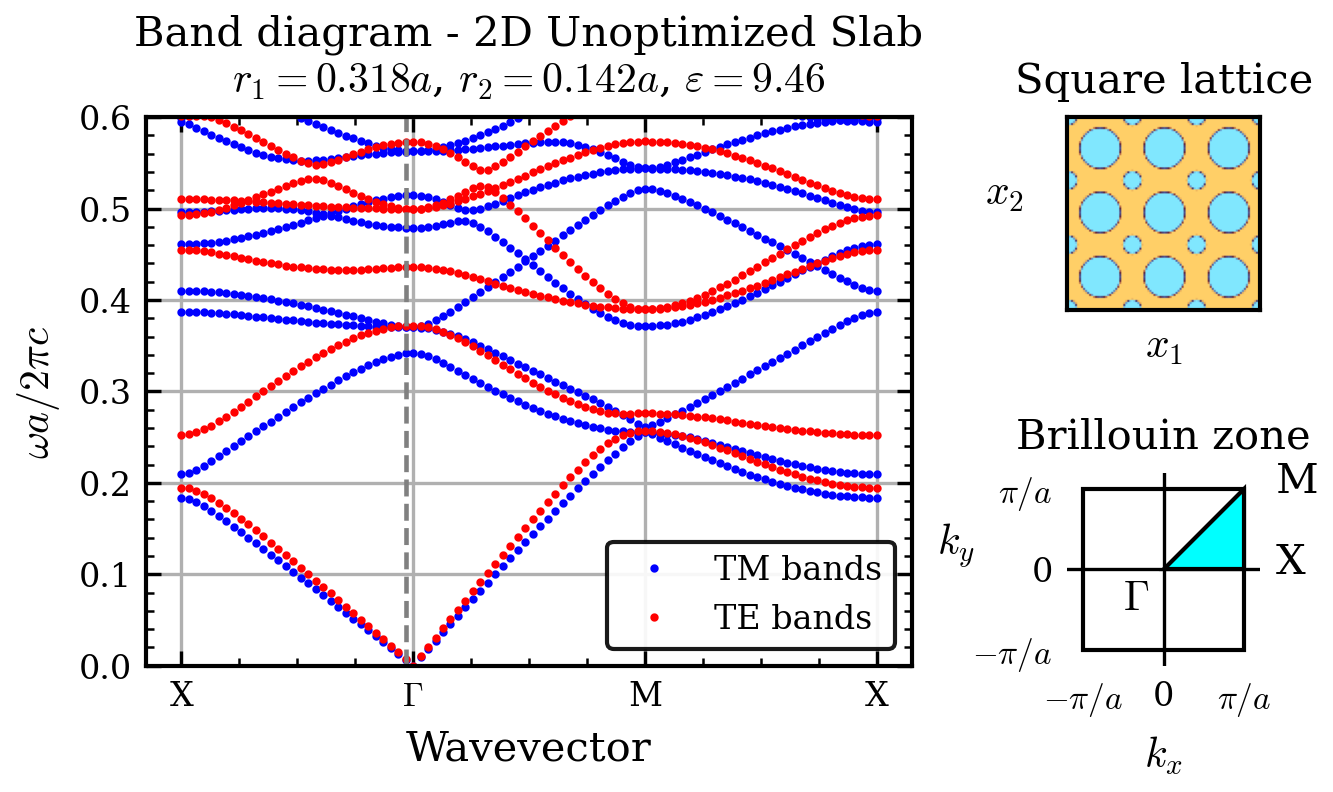

In [47]:
# Create a figure with a custom grid layout
fig = plt.figure(figsize=(WIDTH_1*1.3, HEIGHT_1), constrained_layout=True)
gs = gridspec.GridSpec(2, 3, figure=fig)

# -- 1. LEFT PANEL: Band Diagram --
ax_band = fig.add_subplot(gs[:, 0:2])
plt.sca(ax_band) # Set current axis for the viewer
plot_options = dict(linestyle='', marker='o', markersize=1)

# Assuming viewer_2D uses the currently active axis (plt.gca())
viewer_2D.plot_band_diagram("tm", k_points_path=k_points, color="blue", plot_options=plot_options)
viewer_2D.plot_band_diagram("te", k_points_path=k_points, color="red", plot_options=plot_options)
ax_band.set_ylim(0, 0.6)
ax_band.set_ylabel(r"$\omega a/2\pi c$")
ax_band.set_title("Band diagram - 2D Unoptimized Slab\n" + data_line)
# find the set with k1 nonzero and k2 zero, which corresponds to the path along Gamma-X, where the degeneracy occurs
df2 = df[df["k2"] == 0]
# find "k index" fot the smallest nonzero k1 in df2, which corresponds to the point closest to Gamma along the Gamma-X path
df_target_idx = df2[df2["k1"] > 0]["k1"].idxmin() 
k_idx_for_field_plot = df2.loc[df_target_idx, "k index"]

ax_band.vlines(k_idx_for_field_plot, ymin, ymax, colors="gray", linestyles="--", label=None)


# -- 2. TOP RIGHT PANEL: Square Lattice (3 periods, no ticks, no colorbar) --
ax_lat = fig.add_subplot(gs[0, 2])
opt_3x3 = MPBDataOptions(rectify=True, periods=3)
eps_3x3 = simulation_2D_unoptimized.load_and_convert_epsilon_data(options=opt_3x3)

# Plotting the dielectric distribution directly to avoid automatic colorbars/ticks
ax_lat.imshow(eps_3x3, cmap="managua_r", origin="lower") 
ax_lat.set_xticks([])
ax_lat.set_yticks([])
ax_lat.set_xlabel(r"$x_1$")
ax_lat.set_ylabel(r"$x_2$", rotation=0, labelpad=15)
ax_lat.set_title("Square lattice")

# -- 3. BOTTOM RIGHT PANEL: Brillouin Zone --
ax_bz = fig.add_subplot(gs[1, 2])

# Draw the boundary of the Brillouin zone (square for square lattice)
bz_square = patches.Rectangle((-1, -1), 2, 2, fill=False, edgecolor='black')
ax_bz.add_patch(bz_square)

# Draw the Irreducible Brillouin Zone (IBZ) triangle
ibz_triangle = patches.Polygon([[0, 0], [1, 0], [1, 1]], closed=True, fill=True, facecolor='cyan', edgecolor='black')
ax_bz.add_patch(ibz_triangle)

# Add crosshair lines through the origin
ax_bz.axhline(0, color='black', linewidth=0.8)
ax_bz.axvline(0, color='black', linewidth=0.8)

# Add High-Symmetry point labels
ax_bz.text(-0.5, -0.5, r'$\Gamma$')
ax_bz.text(1.4, -0.05, 'X')
ax_bz.text(1.4, 0.95, 'M')

# Format axes
ax_bz.set_xlim(-1.2, 1.2)
ax_bz.set_ylim(-1.2, 1.2)
ax_bz.set_aspect('equal')

# Set specific ticks corresponding to pi/a
# Format axes
ax_bz.set_xlim(-1.2, 1.2)
ax_bz.set_ylim(-1.2, 1.2)
ax_bz.set_aspect('equal')

# 1. Turn off the default subplot bounding box (spines)
for spine in ax_bz.spines.values():
    spine.set_visible(False)

# 2. Turn off all tick marks (both major and minor) to remove the clutter
ax_bz.tick_params(which='both', bottom=False, top=False, left=False, right=False)

# 3. Set specific tick labels corresponding to pi/a (they will now float nicely without ticks)
ax_bz.set_xticks([-1, 0, 1])
ax_bz.set_xticklabels([r'$-\pi/a$', '0', r'$\pi/a$'])
ax_bz.set_yticks([-1, 0, 1])
ax_bz.set_yticklabels([r'$-\pi/a$', '0', r'$\pi/a$'])

ax_bz.set_xlabel(r"$k_x$")
ax_bz.set_ylabel(r"$k_y$", rotation=0)
ax_bz.set_title("Brillouin zone")

# Save and show
plt.savefig(os.path.join(fig_folder, "combined_band_diagram_bz"+simulation_2D_unoptimized.simulation_name))
plt.show()

### Optimization


#### Bands 4,5,6

Best point with filling_factor<0.3:  r1                0.215622
r2                0.289368
cost              0.000020
freq-dirac        0.553810
filling_factor    0.409120
Name: 236, dtype: float64
Best point with filling_factor>=0.3:  r1                0.372723
r2                0.297844
cost              0.000050
freq-dirac        0.744703
filling_factor    0.715131
Name: 72, dtype: float64


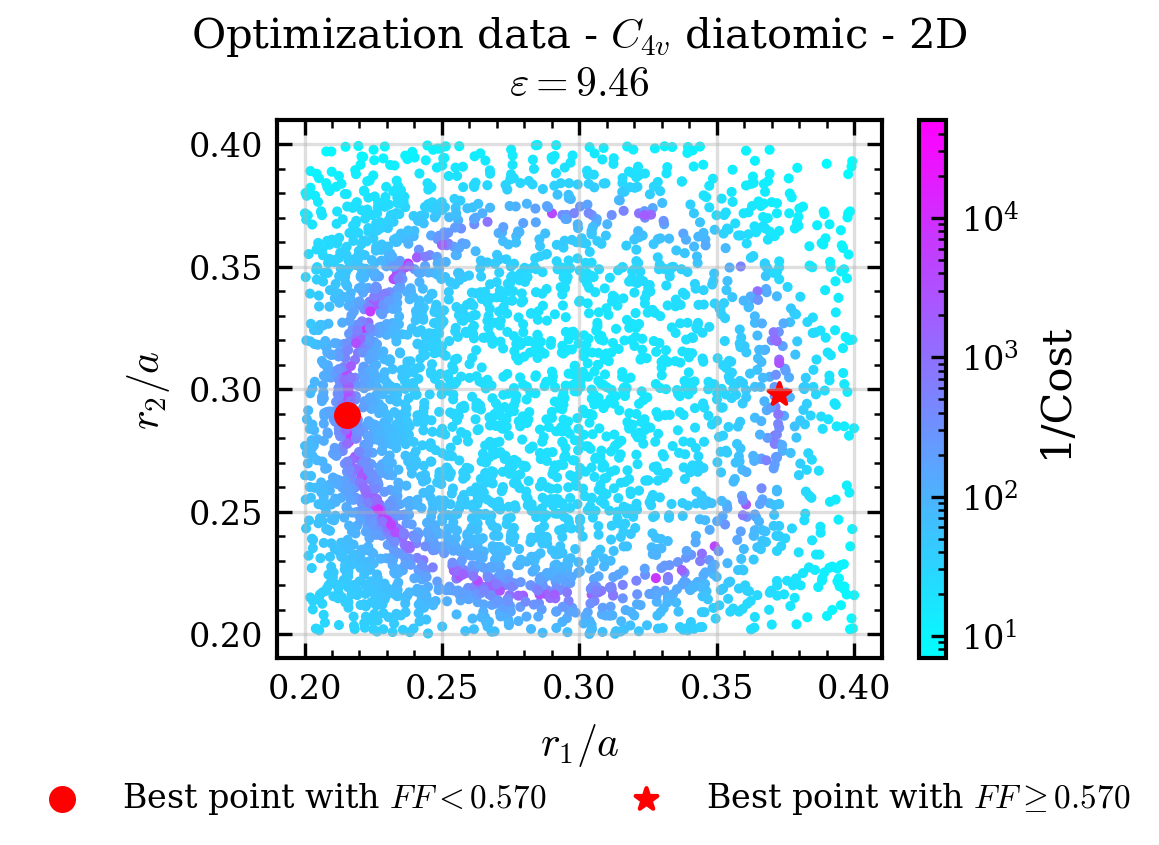

In [71]:
pop = 32
optimizer = MPIdeOptimizator(
        simulation_name=simulation_2D_opt_456.simulation_name,
        scheme_script=simulation_2D_opt_456.script, 
        maxiter=50,
        param_names=["r1", "r2"],
        param_bounds=[(0.2, 0.4), (0.2, 0.4)],
        polarization="te",
        de_options={
            "strategy": "rand1bin",
            "popsize": pop,
            "mutation": (0.8, 1.5),
            "recombination": 0.3,
            "tol": 1e-12,
            "init": "latinhypercube",
        },
        bands=[4,5,6],
        directory=simulation_2D_opt_456.directory,
    )
# optimizer.erease_data_file()
# optimizer.submit_lsf_job(lsf_config, conda_env_name="mpb-nzi-env")
analyzer = OptimizationDataAnalyzer(optimizer.data_file)
plt.figure(figsize=ROW1_COL1_SIZE)
analyzer.plot_raw_data(plot_inverse_cost=True, points_only=True, use_logscale=True, plot_options=dict(marker='o', s=2, cmap="cool"))
plt.grid(alpha=0.4) 
plt.xlabel("$r_1/a$")
plt.ylabel("$r_2/a$") 
plt.title("Optimization data - $C_{4v}$ diatomic - 2D" + "\n" +rf"$\varepsilon={eps_inp}$") 


df = analyzer.get_points_above_treshold(500)

# add a column to the dataframe with the filling factor of the unit cell, calculated as the area of the two circles divided by the area of the unit cell
df["filling_factor"] = (np.pi * df["r1"]**2 + np.pi * df["r2"]**2) / 1**2

# Threshold for filling factor
ff_min, ff_max = df["filling_factor"].min(), df["filling_factor"].max()
threshold_ff = (ff_min + ff_max) / 2

# find the combination of r1 and r2 that gives the minimum cost coming from the points with filling factor below the threshold
best_point_below_threshold = df.loc[df[df["filling_factor"] < threshold_ff]["cost"].idxmin()]
print("Best point with filling_factor<0.3: ", best_point_below_threshold)
r1_below_threshold, r2_below_threshold = best_point_below_threshold["r1"], best_point_below_threshold["r2"]

# find the point with the best cost among the points with filling factor above the threshold
best_point_above_threshold = df.loc[df[df["filling_factor"] >= threshold_ff]["cost"].idxmin()]
print("Best point with filling_factor>=0.3: ", best_point_above_threshold)
r1_above_threshold, r2_above_threshold = best_point_above_threshold["r1"], best_point_above_threshold["r2"]


# plot the point with the best cost
plt.scatter(best_point_below_threshold["r1"], best_point_below_threshold["r2"], color="red", label=rf"Best point with $FF<{threshold_ff:0.3f}$", marker="o", s=30)
plt.scatter(best_point_above_threshold["r1"], best_point_above_threshold["r2"], color="red", label=rf"Best point with $FF\geq{threshold_ff:0.3f}$", marker="*", s=30)
# legend below the plot, centered
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=2, framealpha=0.95, facecolor='white', edgecolor='black')
plt.savefig(os.path.join(figure_path, "optimization_data_2D.png"), dpi=300)
plt.show()


### Optimized

#### Above FF threshold

r2:  0.29784408447837607 r1:  0.37272276943706906 filling factor:  0.7151312962493602


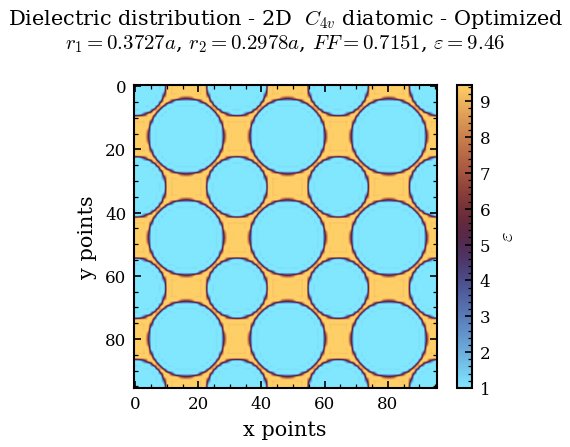

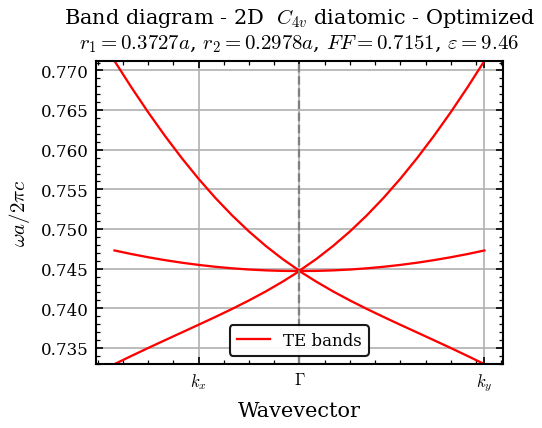

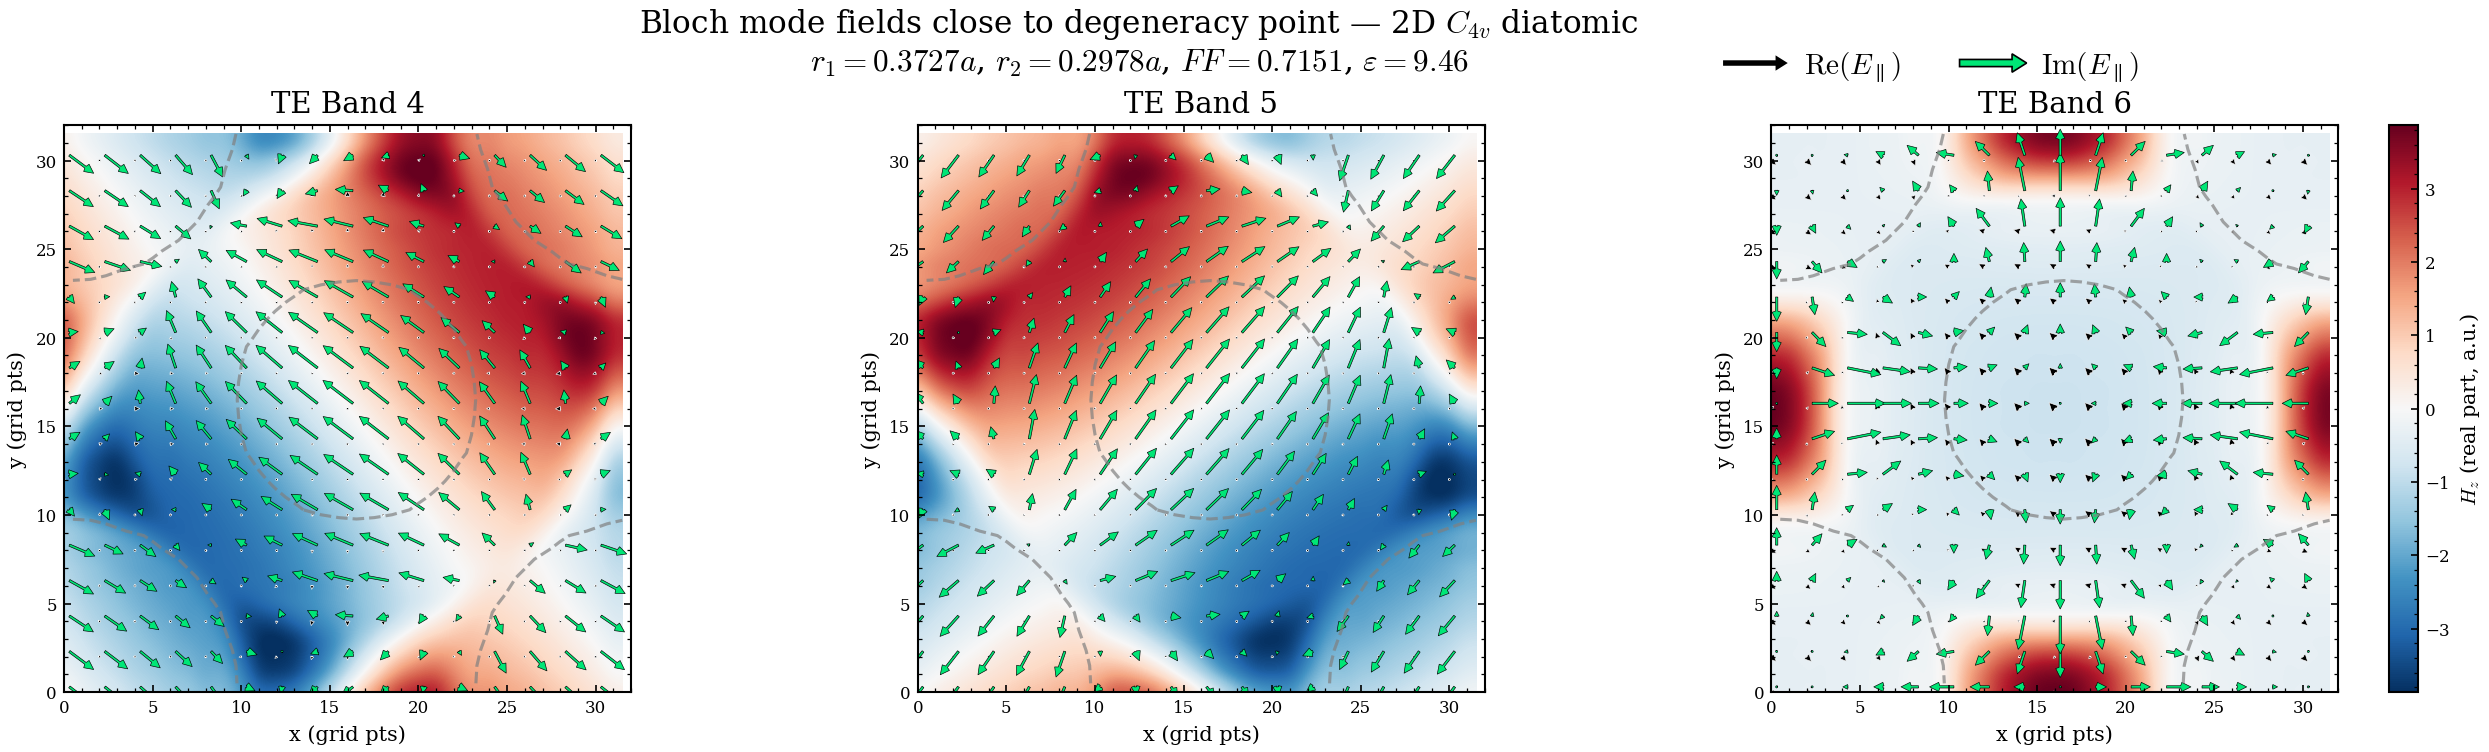

In [29]:
r1 = r1_above_threshold
r2 = r2_above_threshold
fig_folder = os.path.join(figure_path, name_2D_optimized + "_above_threshold")
os.makedirs(fig_folder, exist_ok=True)
print("r2: ", r2, "r1: ", r1, "filling factor: ", (np.pi*r1**2 + np.pi*r2**2))
SIMULATE = False
simulation_2D_optimized_above_threshold = Simulation(
    simulation_name=name_2D_optimized + "_above_threshold",
    script = script_2D_optimized,
    directory= os.path.join(data_rooth, name_2D_optimized + "_above_threshold")  
    )
if SIMULATE is True:
    print("2D simulation started")
    simulation_2D_optimized_above_threshold.run_hpc(mpb_command_line_params=dict(r1 = r1, r2 = r2), mpi = True)
    print("done")
print("Collecting results forom ", simulation_2D_optimized_above_threshold.directory)
viewer_2D = SimulationViewer(simulation_2D_optimized_above_threshold) 
opt = MPBDataOptions(rectify=True, periods= 3, transpose=False)
plt.figure()
viewer_2D.plot_epsilon_2d(conversion_options=opt, cmap = "managua_r")
plt.xlabel("x points")
plt.ylabel("y points")
data_line = rf"$r_1={r1:.4f}a$, $r_2={r2:.4f}a$, $FF = {np.pi*r1**2 + np.pi*r2**2:.4f}$, $\varepsilon={eps_inp}$"
plt.title("Dielectric distribution - 2D  $C_{4v}$ diatomic - Optimized\n" + data_line+"\n")
plt.savefig(os.path.join(fig_folder, "dielectric_distribution"))
viewer_2D.show()
plot_options = dict(linestyle='-', marker=None, markersize=1)
# viewer_2D.plot_band_diagram("tm", k_points_path=k_points_around_gamma, color = "blue", plot_options=plot_options)
viewer_2D.plot_band_diagram("te", k_points_path=k_points_around_gamma, color = "red", plot_options=plot_options)
plt.ylabel("$\omega a/2\pi c$")
plt.title("Band diagram - 2D  $C_{4v}$ diatomic - Optimized\n" + data_line)

df = simulation_2D_optimized_above_threshold.load_frequency_data("te")

max_freq = df["te band 6"].max()
min_freq = df["te band 4"].min()

len_k_points = len(k_points["k_points_values"])

plt.ylim(min_freq, max_freq)


ax = plt.gca()
k_idx_for_field_plot = 12
plt.vlines(k_idx_for_field_plot, min_freq, max_freq, color="gray", linestyle="--", label=None)
plt.savefig(os.path.join(fig_folder, "band_diagram"))   
viewer_2D.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
band_indices = [4,5,6]
for ax, b_idx in zip(axes, band_indices):
    im = plot_field_quiver_on_ax(simulation_2D_optimized_above_threshold, mode = "te", k_idx = k_idx_for_field_plot, b_idx=b_idx, ax=ax)
    ax.set_title(f"TE Band {b_idx}", fontsize=14)

# Shared colorbar
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.04, pad=0.02)
cbar.set_label(r"$H_{z}$ (real part, a.u.)")

# Arrow legend
add_arrow_legend(fig, 
                 is_figure=True, 
                 loc='upper right', 
                 bbox_to_anchor=(0.88, 0.97),
                 fontsize = 14)

fig.suptitle(
    r"Bloch mode fields close to degeneracy point — 2D $C_{4v}$ diatomic"
    + "\n" + data_line,
    fontsize=15
)

plt.savefig(os.path.join(fig_folder, "modes"))
plt.show()

#### Below FF Threshold

r2:  0.2893684110882849 r1:  0.21562231086468173 filling factor:  0.40912036958598136


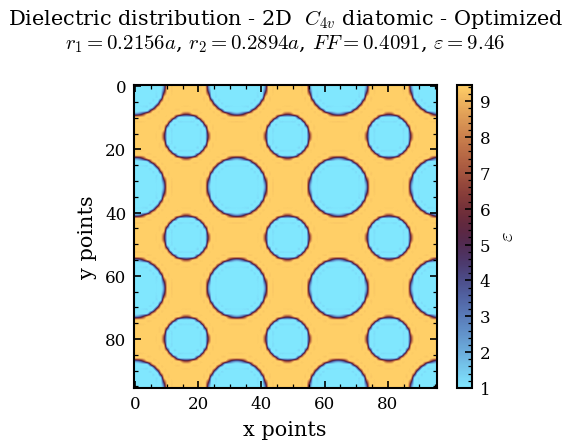

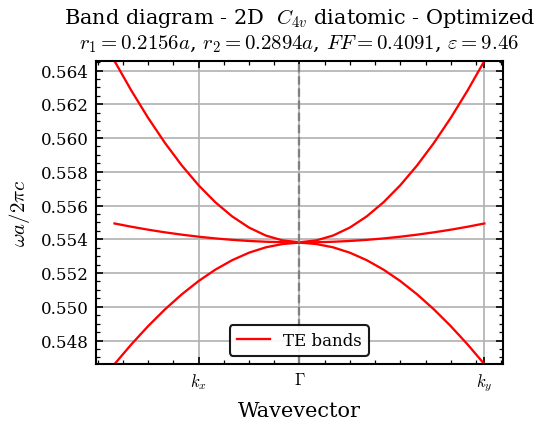

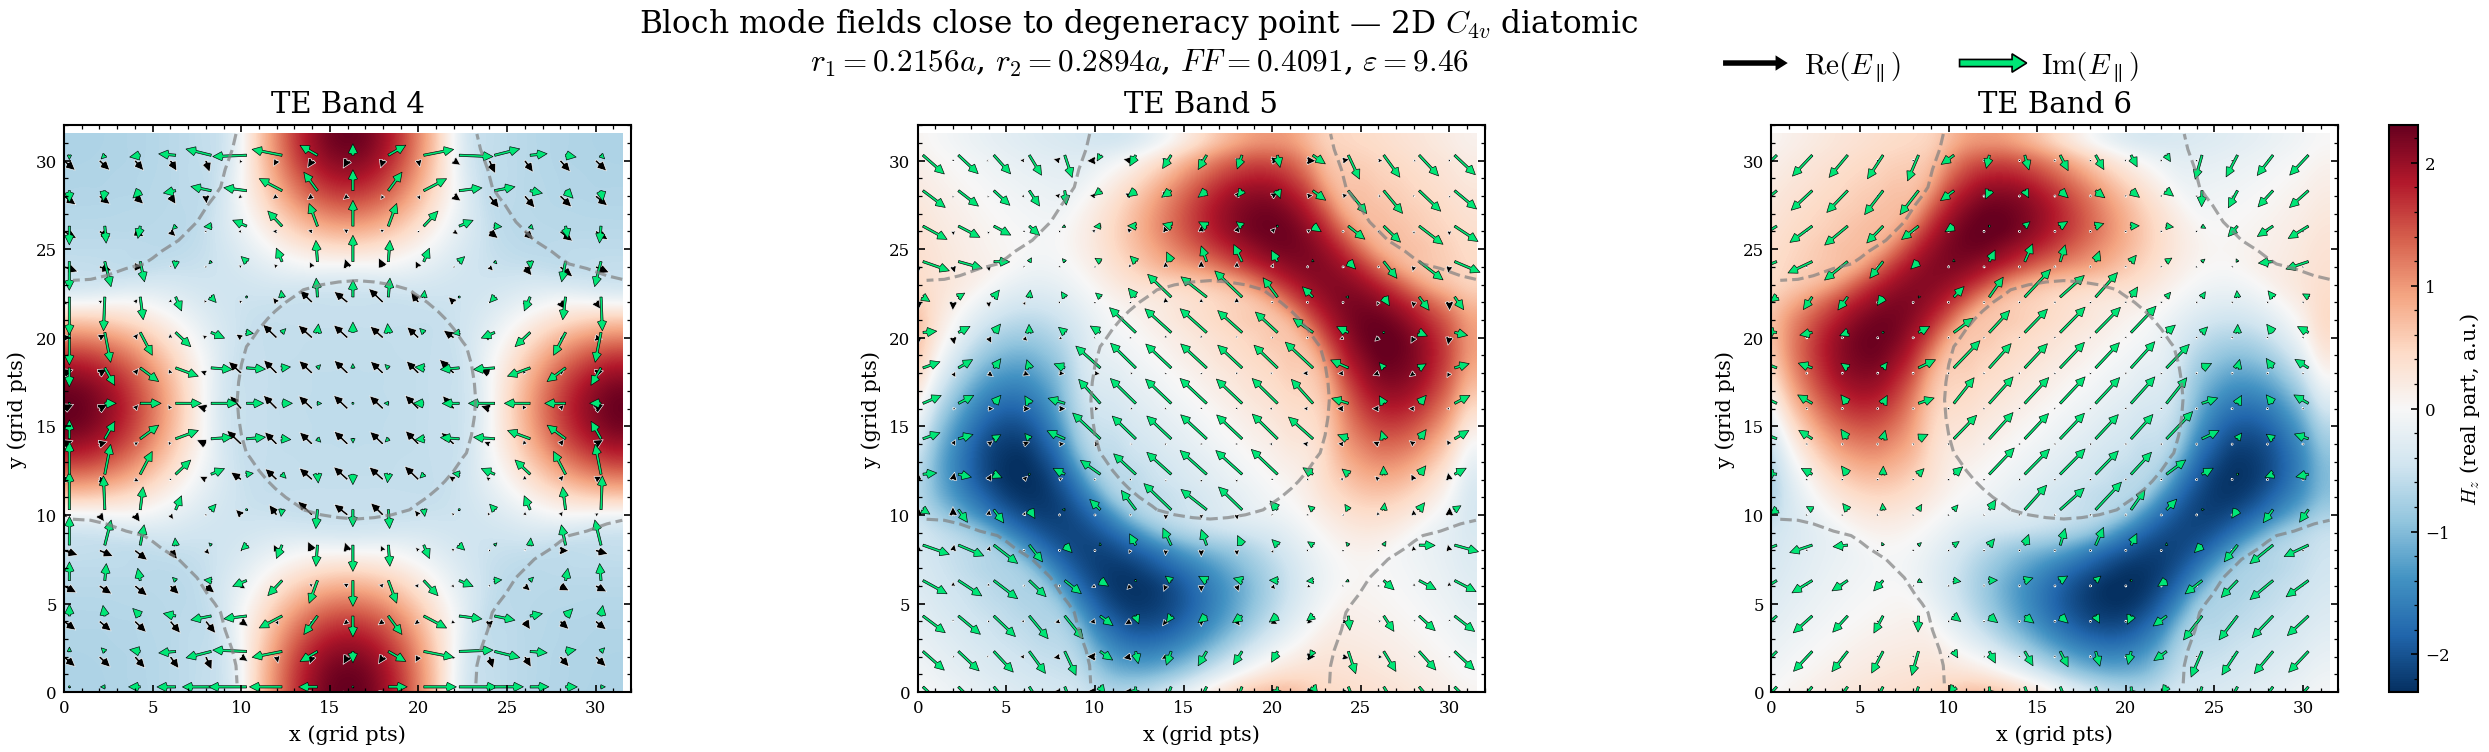

In [30]:
r1 = r1_below_threshold
r2 = r2_below_threshold
fig_folder = os.path.join(figure_path, name_2D_optimized + "_below_threshold")
os.makedirs(fig_folder, exist_ok=True)
print("r2: ", r2, "r1: ", r1, "filling factor: ", (np.pi*r1**2 + np.pi*r2**2))
SIMULATE = False
simulation_2D_optimized_below_threshold = Simulation(
    simulation_name=name_2D_optimized + "_below_threshold",
    script = script_2D_optimized,
    directory= os.path.join(data_rooth, name_2D_optimized + "_below_threshold")  
    )
if SIMULATE is True:
    print("2D simulation started")
    simulation_2D_optimized_below_threshold.run_hpc(mpb_command_line_params=dict(r1 = r1, r2 = r2), mpi = True)
    print("done")
print("Collecting results forom ", simulation_2D_optimized_below_threshold.directory)
viewer_2D = SimulationViewer(simulation_2D_optimized_below_threshold) 
opt = MPBDataOptions(rectify=True, periods= 3, transpose=False)
plt.figure()
viewer_2D.plot_epsilon_2d(conversion_options=opt, cmap = "managua_r")
plt.xlabel("x points")
plt.ylabel("y points")
data_line = rf"$r_1={r1:.4f}a$, $r_2={r2:.4f}a$, $FF = {np.pi*r1**2 + np.pi*r2**2:.4f}$, $\varepsilon={eps_inp}$"
plt.title("Dielectric distribution - 2D  $C_{4v}$ diatomic - Optimized\n" + data_line+"\n")
plt.savefig(os.path.join(fig_folder, "dielectric_distribution"))    
viewer_2D.show()
plot_options = dict(linestyle='-', marker=None, markersize=1)
# viewer_2D.plot_band_diagram("tm", k_points_path=k_points_around_gamma, color = "blue", plot_options=plot_options)
viewer_2D.plot_band_diagram("te", k_points_path=k_points_around_gamma, color = "red", plot_options=plot_options)
plt.ylabel("$\omega a/2\pi c$")
plt.title("Band diagram - 2D  $C_{4v}$ diatomic - Optimized\n" + data_line)

df = simulation_2D_optimized_below_threshold.load_frequency_data("te")

max_freq = df["te band 6"].max()
min_freq = df["te band 4"].min()

len_k_points = len(k_points["k_points_values"])

plt.ylim(min_freq, max_freq)


ax = plt.gca()
k_idx_for_field_plot = 12
plt.vlines(k_idx_for_field_plot, min_freq, max_freq, color="gray", linestyle="--", label=None)
plt.savefig(os.path.join(fig_folder, "band_diagram"))   
viewer_2D.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
band_indices = [4,5,6]
for ax, b_idx in zip(axes, band_indices):
    im = plot_field_quiver_on_ax(simulation_2D_optimized_below_threshold, mode = "te", k_idx = k_idx_for_field_plot, b_idx=b_idx, ax=ax)
    ax.set_title(f"TE Band {b_idx}", fontsize=14)

# Shared colorbar
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.04, pad=0.02)
cbar.set_label(r"$H_{z}$ (real part, a.u.)")

# Arrow legend
add_arrow_legend(fig, 
                 is_figure=True, 
                 loc='upper right', 
                 bbox_to_anchor=(0.88, 0.97),
                 fontsize = 14)

fig.suptitle(
    r"Bloch mode fields close to degeneracy point — 2D $C_{4v}$ diatomic"
    + "\n" + data_line,
    fontsize=15
)

plt.savefig(os.path.join(fig_folder, "modes"))
plt.show()

### Band Linearity Analysis
Evaluate the linearity of the top Dirac-cone band (band 6) for points along the optimization ellipse.

COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
Sampling 50 points along the Dirac ellipse
  r1 range: [0.2153, 0.3733]
  r2 range: [0.2149, 0.3752]


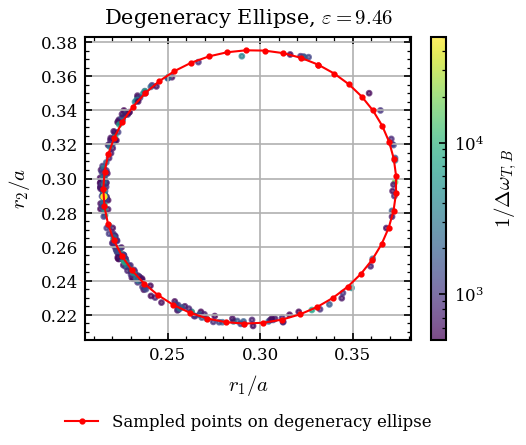

SIMULATE=False → Skipping actual runs. Using existing data if available, otherwise will error out when trying to load frequencies.


In [31]:
import pandas as pd
from scipy.stats import linregress

SIMULATE = False # Set to True to run simulations, False to skip and just analyze data
distance = 0.05
k_points_around_gamma = lattice_2D.get_k_points_around_gamma(distance = distance)
# Create a lean configuration: only frequencies, no field output
config_linearity = dict(
    resolution=RESOLUTION,
    num_bands=8,
    k_points=k_points_around_gamma["k_points_values"],
    k_points_interpolation_factor=60,
)
mpb_config_lin = MPBSchemeConfigurator(photonic_crystal_2D, ["te"], **config_linearity)
script_lin = mpb_config_lin.get_scheme_config(join_newline=True)

# Sample points along the Dirac-like ellipse from optimization data
threshold_lin = 500
n_samples = 50
r1_ell, r2_ell, f_ell, _ = analyzer.compute_freq_dirac_along_ellipse(
    threshold=threshold_lin, n_points=n_samples)
print(f"Sampling {n_samples} points along the Dirac ellipse")
print(f"  r1 range: [{r1_ell.min():.4f}, {r1_ell.max():.4f}]")
print(f"  r2 range: [{r2_ell.min():.4f}, {r2_ell.max():.4f}]")

# Plot the sampled points on top of the cost landscape
p1 = analyzer.param1_name
p2 = analyzer.param2_name
plt.figure(figsize=ROW1_COL1_SIZE)
df = analyzer.get_points_above_treshold(threshold_lin)
sc = plt.scatter(df[p1], df[p2], c=1/df["cost"], cmap="viridis", norm=colors.LogNorm(vmin=(1/df["cost"]).min(), vmax=(1/df["cost"]).max()), s=5, alpha=0.7)
plt.colorbar(sc, label="$1/\Delta \omega_{T,B}$")
plt.plot(r1_ell, r2_ell, "ro-", label="Sampled points on degeneracy ellipse", markersize=2, linewidth=1)
plt.xlabel("$r_1/a$")
plt.ylabel("$r_2/a$")
plt.title("Degeneracy Ellipse, " + rf"$\varepsilon={eps_inp}$")  
# Legend below the plot, centered
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=1, framealpha=0.95, facecolor='white', edgecolor='black')
plt.grid(True)
plt.show()

# Create a unique Simulation object for each ellipse point
sims_lin = []
for i, (r1_i, r2_i) in enumerate(zip(r1_ell, r2_ell)):
    sim_name = f"{name_2D_optimized}_lin_{i:03d}"
    sim = Simulation(
        simulation_name=sim_name,
        script=script_lin,
        directory=os.path.join(data_rooth, sim_name)
    )
    sims_lin.append({'r1': r1_i, 'r2': r2_i, 'sim': sim, 'f_dirac_approx': f_ell[i]})

# Run all simulations concurrently
if SIMULATE is True:
    from concurrent.futures import ThreadPoolExecutor, as_completed
    N_WORKERS = 8

    def run_lin_entry(args):
        j, entry = args
        entry['sim'].run_hpc(
            mpb_command_line_params=dict(r1=entry['r1'], r2=entry['r2']),
            mpi=True, load_epsilon=False)
        return j

    print(f"Running {len(sims_lin)} simulations with {N_WORKERS} workers...")
    with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
        futures = {pool.submit(run_lin_entry, (j, e)): j for j, e in enumerate(sims_lin)}
        for fut in as_completed(futures):
            j = fut.result()
            print(f"  [{j+1}/{len(sims_lin)}] r1={sims_lin[j]['r1']:.4f}, r2={sims_lin[j]['r2']:.4f} done")
    print(f"\nAll {len(sims_lin)} simulations completed.")
else: 
    print(f"SIMULATE=False → Skipping actual runs. Using existing data if available, otherwise will error out when trying to load frequencies.")

COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
Sweeping r2 for 50 points × 200 r2 values = 10000 Γ-only simulations
SIMULATE=False → Loading existing sweeper data with 20 workers...
  [18/50] r1=0.2159: r2=0.2836 → 0.2831 (Δ=-0.00045, gap=1.90e-05)
  [30/50] r1=0.3016: r2=0.2154 → 0.2154 (Δ=+0.00005, gap=1.20e-05)
  [20/50] r1=0.2209: r2=0.2638 → 0.2643 (Δ=+0.00045, gap=1.20e-05)
  [11/50] r1=0.2378: r2=0.3500 → 0.3508 (Δ=+0.00085, gap=4.90e-05)
  [ 2/50] r1=0.3220: r2=0.3708 → 0.3713 (Δ=+0.00045, gap=8.00e-05)
  [15/50] r1=0.2179: r2=0.3142 → 0.3153 (Δ=+0.00106, gap=8.00e-06)
  [28/50] r1=0.2814: r2=0.2157 → 0.2160 (Δ=+0.00035, gap=3.20e-05)
  [12/50] r1=0.2312: r2=0.3421 → 0.3438 (Δ=+0.00176, gap=2.20e-05)
  [13/50] r1=0.2256: r2=0.3334 → 0.3352 (Δ=+0.00186, gap=2.60e-05)
  [ 9/50] r1=0.2537: r2=0.3630 → 0.3616 (Δ=-0.00146, gap=1.50e-05)
  [10/50] r1=0.2453: r2=0.3570 → 0.3565 (Δ=-0.00055, gap=6.00e-05)
  [29/50] r1=0.2914: r2=0.2149 → 0.2155 (Δ

/tmp/ipykernel_1986229/789325453.py:116: UserWarning: Adding colorbar to a different Figure <Figure size 525x393.75 with 2 Axes> than <Figure size 525x393.75 with 2 Axes> which fig.colorbar is called on.
  plt.colorbar(sc, ax=ax, label=r"$1/\Delta \omega_{T,B}$")


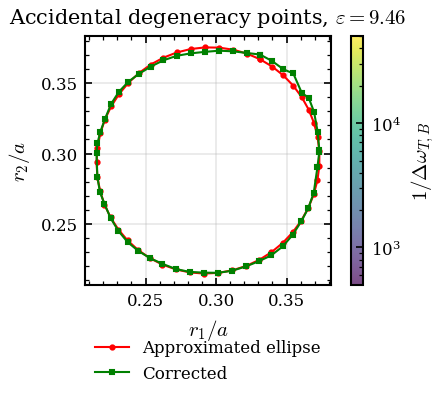


Running 50 linearity simulations with corrected r2...
SIMULATE=False → Skipping actual runs. Using existing data if available, otherwise will error out when trying to load frequencies.


In [37]:
# ================================================================
# For each of the 40 ellipse points, fix r1 and sweep r2 at Γ
# to find the EXACT band 4–6 degeneracy — using parallel ParamSweepers
# ================================================================
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from phc_nzi.sweeper import ParamSweeper

SIMULATE = False # Set to True to run simulations, False to load existing data
n_r2_sweep = 200          # number of r2 values per point
r2_half_width = 0.01    # search range: r2_original ± this
N_WORKERS = 20            # number of sweepers to run in parallel

# Gamma-only configuration → very fast per simulation
config_deg = dict(
    resolution=RESOLUTION,
    num_bands=8,
    k_points=[mp.Vector3(0, 0, 0)],
)
mpb_config_deg = MPBSchemeConfigurator(photonic_crystal_2D, ["te"], **config_deg)
script_deg = mpb_config_deg.get_scheme_config(join_newline=True)

total_sims = len(r1_ell) * n_r2_sweep
print(f"Sweeping r2 for {len(r1_ell)} points × {n_r2_sweep} r2 values = {total_sims} Γ-only simulations")

# Build one ParamSweeper per ellipse point
sweeper_entries = []
for i in range(len(r1_ell)):
    r1_i = r1_ell[i]
    r2_orig = r2_ell[i]
    r2_lo = max(0.05, r2_orig - r2_half_width)
    r2_hi = min(0.49, r2_orig + r2_half_width)
    r2_sweep = np.linspace(r2_lo, r2_hi, n_r2_sweep)

    sim_deg = Simulation(
        simulation_name=f"{name_2D_optimized}_deg_sweep_{i:03d}",
        script=script_deg,
        directory=os.path.join(data_rooth, f"{name_2D_optimized}_deg_sweep_{i:03d}")
    )
    sweeper = ParamSweeper(
        simulation=sim_deg,
        param_name="r2",
        values=r2_sweep.tolist(),
        polarization="te",
        bands=[4, 6],
        other_command_line_params={"r1": r1_i}
    )
    sweeper_entries.append({
        'idx': i, 'r1': r1_i, 'r2_orig': r2_orig,
        'r2_sweep': r2_sweep, 'sweeper': sweeper
    })

t0 = time.time()

def run_and_analyze(entry):
    """Run one sweeper and return the corrected-point dict."""
    sw = entry['sweeper']
    if SIMULATE:
        sw.run()
    data = sw.data if len(sw.data) > 0 else sw.load_df()
    gaps = (data['band_6'] - data['band_4']).abs().values
    best = int(np.argmin(gaps))
    r2_corr = entry['r2_sweep'][best]

    if best == 0 or best == n_r2_sweep - 1:
        print(f"  ⚠ [{entry['idx']+1:2d}/{len(r1_ell)}] r1={entry['r1']:.4f}: "
              f"minimum at EDGE of sweep range — consider widening r2_half_width")

    return {
        'idx': entry['idx'],
        'r1': entry['r1'],
        'r2_original': entry['r2_orig'],
        'r2_corrected': r2_corr,
        'gap_corrected': gaps[best],
        'delta_r2': r2_corr - entry['r2_orig'],
    }

if SIMULATE:
    print(f"Running {N_WORKERS} sweepers in parallel...")
    corrected_points = []
    with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
        futures = {pool.submit(run_and_analyze, e): e for e in sweeper_entries}
        for fut in as_completed(futures):
            result = fut.result()
            corrected_points.append(result)
            idx = futures[fut]['idx']
            elapsed = time.time() - t0
            print(f"  [{idx+1:2d}/{len(r1_ell)}] r1={result['r1']:.4f}: "
                  f"r2={result['r2_original']:.4f} → {result['r2_corrected']:.4f} ")
    corrected_points.sort(key=lambda x: x['idx'])
else:
    print(f"SIMULATE=False → Loading existing sweeper data with {N_WORKERS} workers...")
    corrected_points = []
    with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
        futures = {pool.submit(run_and_analyze, e): e for e in sweeper_entries}
        for fut in as_completed(futures):
            result = fut.result()
            corrected_points.append(result)
            print(f"  [{result['idx']+1:2d}/{len(r1_ell)}] r1={result['r1']:.4f}: "
                  f"r2={result['r2_original']:.4f} → {result['r2_corrected']:.4f} "
                  f"(Δ={result['delta_r2']:+.5f}, gap={result['gap_corrected']:.2e})")
    corrected_points.sort(key=lambda x: x['idx'])

df_corr = pd.DataFrame(corrected_points)
print(f"\nDone in {time.time()-t0:.0f}s")
print(f"Mean |Δr2| = {df_corr['delta_r2'].abs().mean():.5f}")
print(f"Max  |Δr2| = {df_corr['delta_r2'].abs().max():.5f}")
print(f"Mean gap_corrected = {df_corr['gap_corrected'].mean():.2e}")

# ================================================================
# Plot: Original vs Corrected ellipse
# ================================================================
fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize = ROW1_COL1_SIZE)

# both ellipses
plt.colorbar(sc, ax=ax, label=r"$1/\Delta \omega_{T,B}$")
ax.plot(r1_ell, r2_ell, "ro-", ms=2, lw=1, label="Approximated ellipse")
ax.plot(df_corr['r1'], df_corr['r2_corrected'], "gs-", ms=2, lw=1,
        label="Corrected")
ax.set_xlabel("$r_1/a$")
ax.set_ylabel("$r_2/a$")
ax.set_title(f"Accidental degeneracy points, $\\varepsilon={eps_inp}$")
# Legend lower center, outside of axis
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.45), ncol=1, framealpha=0.95, facecolor='white', edgecolor='black')
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")  
plt.savefig(os.path.join(figure_path, f"corrected_degeneracy_points.png"))  
plt.show()

# ================================================================
# Create corrected sims_lin and run with k_points_around_gamma
# ================================================================
print(f"\nRunning {len(df_corr)} linearity simulations with corrected r2...")
sims_lin = []
for i, row in df_corr.iterrows():
    sim_name = f"{name_2D_optimized}_lin_corr_{i:03d}"
    sim = Simulation(
        simulation_name=sim_name,
        script=script_lin,
        directory=os.path.join(data_rooth, sim_name)
    )
    sims_lin.append({'r1': row['r1'], 'r2': row['r2_corrected'], 'sim': sim})

if SIMULATE is False:
    print(f"SIMULATE=False → Skipping actual runs. Using existing data if available, otherwise will error out when trying to load frequencies.")
else:
    def run_lin_sim(args):
        j, entry = args
        entry['sim'].run_hpc(
            mpb_command_line_params=dict(r1=entry['r1'], r2=entry['r2']),
            mpi=True, load_epsilon=False)
        return j

    print(f"Running {len(sims_lin)} linearity sims with {N_WORKERS} workers...")
    with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
        futures = {pool.submit(run_lin_sim, (j, e)): j for j, e in enumerate(sims_lin)}
        for fut in as_completed(futures):
            j = fut.result()
            print(f"  [{j+1}/{len(sims_lin)}] r1={sims_lin[j]['r1']:.4f}, r2={sims_lin[j]['r2']:.4f} done")
    print(f"\nAll {len(sims_lin)} corrected simulations completed.")

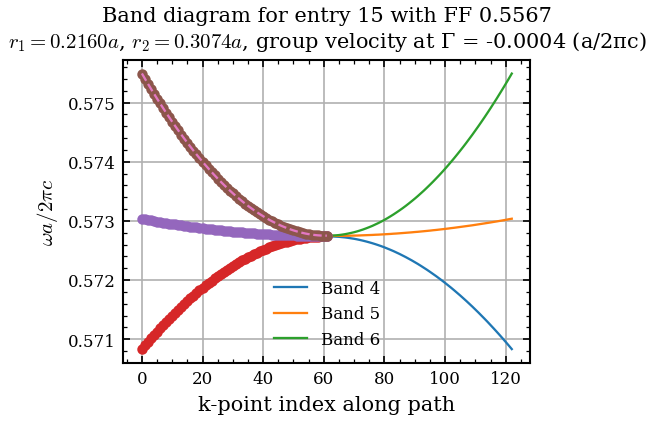

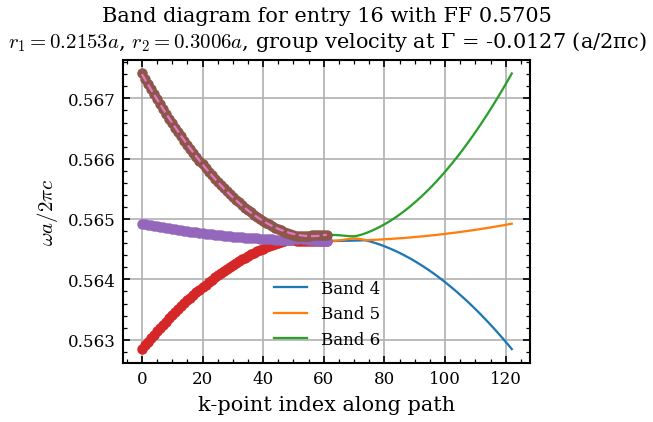

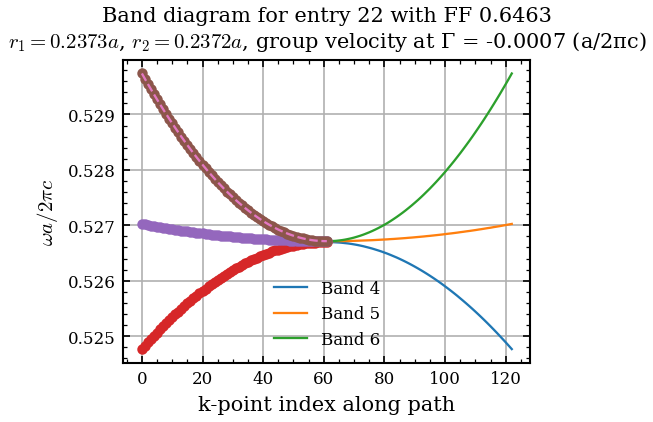

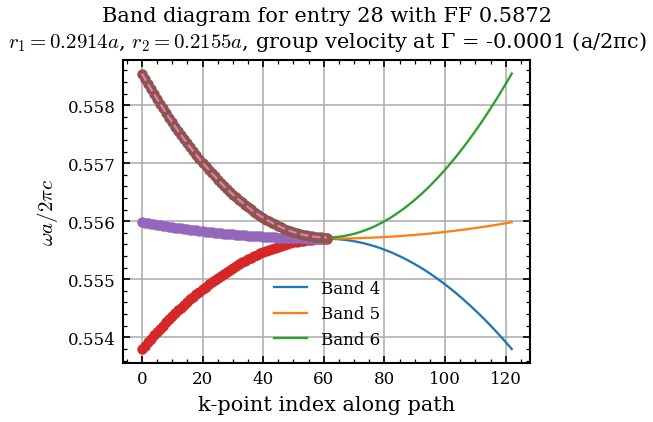

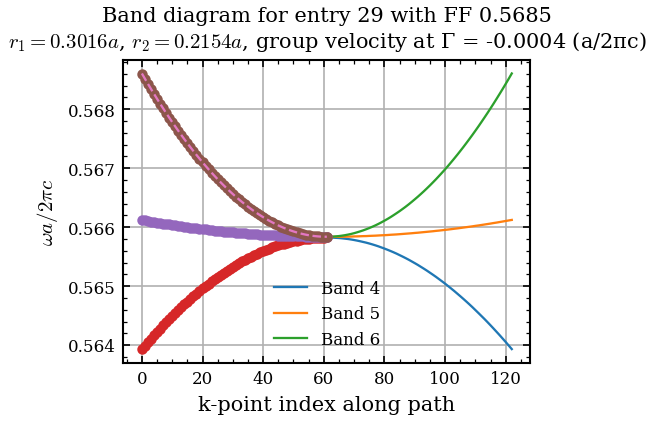

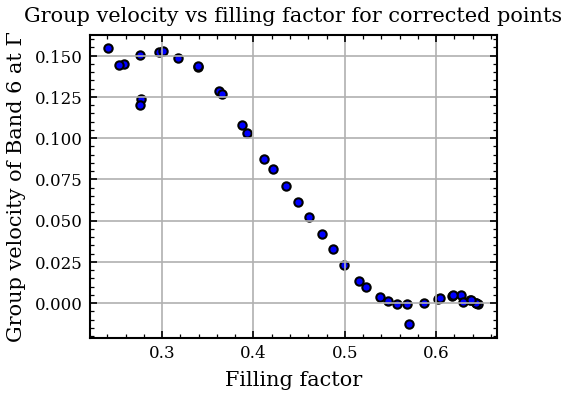

In [38]:

b_idxs = [4, 5, 6]
target = len(sims_lin)//2
for i,entry in enumerate(sims_lin):
    df_freq = entry['sim'].load_frequency_data("te")
    entry['df_freq'] = df_freq
    entry['f_dirac'] = df_freq["te band 5"].values[0]  # Γ point only
    entry['k_vecs'] = [(df_freq['k1'].values[j], df_freq['k2'].values[j]) for j in range(len(df_freq))]
    entry['k_idxs'] = list(range(len(df_freq)))
    entry['bands'] = {f"band_{b}": df_freq[f"te band {b}"].values for b in b_idxs}
    entry['ff'] = 1- (np.pi*entry['r1']**2 + np.pi*entry['r2']**2)
    entry['is_valid'] = (entry['r1'] + entry['r2']) < (np.sqrt(2) / 2) and not np.isclose(entry['r1'] + entry['r2'], np.sqrt(2) / 2, atol=0.01)

    # find the points where ky == 0
    ky_zero_idxs = [j for j, (k1, k2) in enumerate(entry['k_vecs']) if abs(k2) == 0]
    kx_vals = np.array([entry['k_vecs'][j][0] for j in ky_zero_idxs])
    freqs_band4 = np.array([entry['bands']['band_4'][j] for j in ky_zero_idxs])
    freqs_band5 = np.array([entry['bands']['band_5'][j] for j in ky_zero_idxs])
    freqs_band6 = np.array([entry['bands']['band_6'][j] for j in ky_zero_idxs])

    # polynomial fit of band 6 along ky=0
    coeffs = np.polyfit(kx_vals, freqs_band6, deg=3)
    poly = np.poly1d(coeffs)
    slope_6 = poly.deriv()(0)  # slope at Γ point
    
    # The slope is the group velocity, which should be nonzero for a linear Dirac cone. We can print it out or store it for later analysis.
    entry["group_velocity_band_6"] = slope_6
    plot_condition  = entry['is_valid'] and entry['group_velocity_band_6'] < 0

    if plot_condition:
        # plot band diagram
        plt.figure(figsize=ROW1_COL1_SIZE)  
        for b in b_idxs:
            plt.plot(entry['k_idxs'], entry['bands'][f"band_{b}"], label=f"Band {b}")
        plt.xlabel("k-point index along path")
        plt.ylabel("$\omega a/2\pi c$")
        plt.title(f"Band diagram for entry {i} with FF {entry['ff']:.4f}\n" + f"$r_1={entry['r1']:.4f}a$, $r_2={entry['r2']:.4f}a$"
                  + f", group velocity at Γ = {slope_6:.4f} (a/2πc)")
        plt.legend()
        plt.grid(True)

        # plot the bands along ky=0 with the polynomial fit
      
        plt.plot(range(len(kx_vals)), freqs_band4, "o-", label="Band 4")
        plt.plot(range(len(kx_vals)), freqs_band5, "o-", label="Band 5")
        plt.plot(range(len(kx_vals)), freqs_band6, "o-", label="Band 6")
        # plot the polynomial fit for band 6
        plt.plot(range(len(kx_vals)), poly(kx_vals), "--", label=f"Polynomial fit for Band 6 (slope={slope_6:.4f})")
        

    plt.show()

# Now we make a figure with the group velocities for all points, plotted against the filling factor
ff_values = [entry['ff'] for entry in sims_lin if entry['is_valid']]
group_velocities = [entry['group_velocity_band_6'] for entry in sims_lin if entry['is_valid']]
plt.figure(figsize=ROW1_COL1_SIZE)
plt.scatter(ff_values, group_velocities, c='blue', edgecolors='k')
plt.xlabel("Filling factor")
plt.ylabel("Group velocity of Band 6 at Γ")
plt.title("Group velocity vs filling factor for corrected points")
plt.grid(True)
plt.show()

Metric 1 Fit: A=1.09, mu=0.4934, sigma=0.1156, alpha=-2.09
Δk=0.050 Fit: A=3.90, mu=0.4079, sigma=0.0831, alpha=-0.88
Δk=0.001 Fit: A=211.46, mu=0.4408, sigma=0.1009, alpha=-1.78


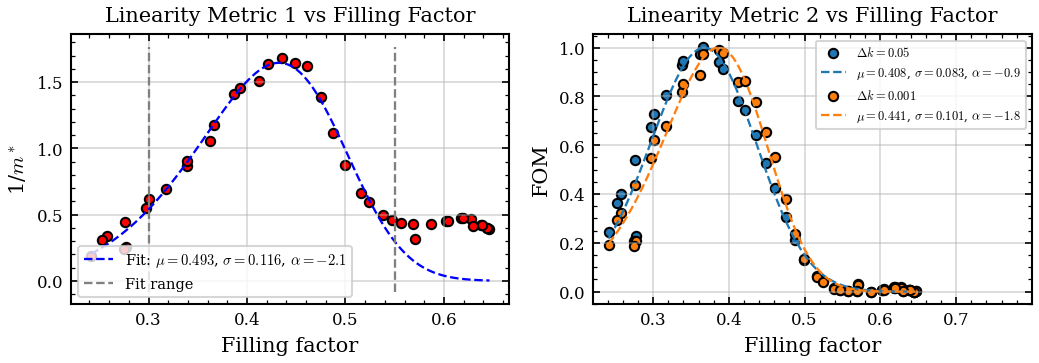

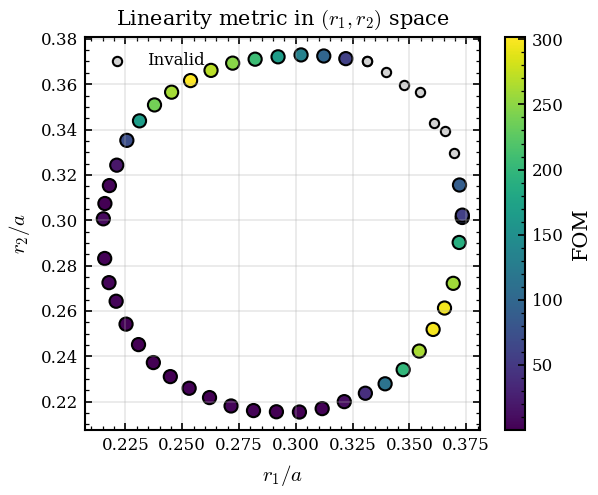

<IPython.core.display.Math object>

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erf

# --- 1. Define the Skew-Gaussian ---
def skew_gaussian(x, A, mu, sigma, alpha):
    """
    A Skew-Normal distribution.
    alpha < 0 creates a fatter left tail to match the physical boundary drop-off.
    """
    norm = (x - mu) / sigma
    gauss = np.exp(-(norm ** 2) / 2.0)
    skew = 0.5 * (1 + erf(alpha * norm / np.sqrt(2)))
    return A * gauss * skew * 2

# --- 2. Metric Computation Functions ---
def compute_band6_polyfit(entry):
    """Fit band 6 along ky=0 once and store coefficients."""
    ky_zero_idxs = [j for j, (_, k2) in enumerate(entry["k_vecs"]) if abs(k2) == 0]
    kx_vals = np.array([entry["k_vecs"][j][0] for j in ky_zero_idxs])
    freqs_band6 = np.array([entry["bands"]["band_6"][j] for j in ky_zero_idxs])
    entry["band6_poly_coeffs"] = np.polyfit(kx_vals, freqs_band6, deg=3)

def linearity_metric_v1(entry):
    """ Calculate the photon effective mass at Gamma."""
    poly = np.poly1d(entry["band6_poly_coeffs"])
    curvature_at_gamma = poly.deriv(2)(0)
    return 1 / abs(curvature_at_gamma)

def linearity_metric_v2(entry, delta_k=0.001):
    """ Calculate the contribution of the linear term with respect to the higher order terms at distance delta_k."""
    a3, a2, a1, _ = entry["band6_poly_coeffs"]
    return abs(a1 * delta_k) / (abs(a2 * delta_k**2) + abs(a3 * delta_k**3) + 1e-20)

# --- 3. Process the Data ---
for entry in sims_lin:
    if entry["is_valid"]:
        compute_band6_polyfit(entry)
        entry["linearity_metric_v1"] = linearity_metric_v1(entry)
        entry["linearity_metric_v2"] = linearity_metric_v2(entry)

ff_values = [entry["ff"] for entry in sims_lin if entry["is_valid"]]
linearity_metrics = [entry["linearity_metric_v1"] for entry in sims_lin if entry["is_valid"]]

ff_arr = np.asarray(ff_values, dtype=float)
lm_arr = np.asarray(linearity_metrics, dtype=float)
ff_cut_left = 0.3
ff_cut_right = 0.55
mask = (ff_arr > ff_cut_left) & (ff_arr < ff_cut_right)
x_fit = np.linspace(min(ff_values), max(ff_values), 100)

# --- 4. First Skew-Gaussian Fit (Metric 1) ---
p0_guesses = [lm_arr.max(), ff_arr.mean(), 0.05, -2.0]
popt, _ = curve_fit(skew_gaussian, ff_arr[mask], lm_arr[mask], p0=p0_guesses)
A_fit, mu_fit, sigma_fit, alpha_fit = popt
print(f"Metric 1 Fit: A={A_fit:.2f}, mu={mu_fit:.4f}, sigma={sigma_fit:.4f}, alpha={alpha_fit:.2f}")


# --- 5. Plotting Subplots ---
plt.figure(figsize=(7.2, 2.625))

# --- Left Subplot: Absolute Curvature Metric ---
plt.subplot(1, 2, 1)
plt.scatter(ff_values, linearity_metrics, c="red", edgecolors="k", s=20)
y_fit = skew_gaussian(x_fit, *popt)

# Added \sigma to the legend
plt.plot(x_fit, y_fit, "b--", label=f"Fit: $\\mu={mu_fit:.3f}$, $\\sigma={sigma_fit:.3f}$, $\\alpha={alpha_fit:.1f}$")

ymin, ymax = plt.ylim()
plt.vlines(ff_cut_left, ymin, ymax, colors="gray", linestyles="--", label="Fit range")
plt.vlines(ff_cut_right, ymin, ymax, colors="gray", linestyles="--")

plt.xlabel("Filling factor")
plt.ylabel("1/$m^*$")
plt.title("Linearity Metric 1 vs Filling Factor")
plt.grid(True, alpha=0.5)
plt.legend(loc="best", fontsize=7, frameon=True) # Kept at 7 to fit the slightly longer string

# --- Right Subplot: Normalized Metric v2 ---
plt.subplot(1, 2, 2)
dks = [0.05, 0.001]
valid_entries = [e for e in sims_lin if e["is_valid"]]
ff_vals_valid = [e["ff"] for e in valid_entries]

for delta_k in dks:
    lm_v2 = np.array([linearity_metric_v2(entry, delta_k=delta_k) for entry in valid_entries])

    # Fit Metric 2 with the Skew-Gaussian
    p0_v2 = [lm_v2.max(), ff_arr.mean(), 0.05, -2.0]
    popt_v2, _ = curve_fit(skew_gaussian, ff_arr, lm_v2, p0=p0_v2)
    A_v2, mu_v2, sigma_v2, alpha_v2 = popt_v2
    print(f"Δk={delta_k:.3f} Fit: A={A_v2:.2f}, mu={mu_v2:.4f}, sigma={sigma_v2:.4f}, alpha={alpha_v2:.2f}")

    # Generate the continuous fit curve
    y_fit_v2_full = skew_gaussian(x_fit, *popt_v2)
    
    # Calculate true mathematical maximum to normalize peak precisely to 1.0
    true_max = np.max(y_fit_v2_full)

    # Plot normalized data and fit (Added \sigma to the legend)
    plt.scatter(ff_vals_valid, lm_v2 / true_max, edgecolors="k", s=20, label=f"$\\Delta k={delta_k}$")
    plt.plot(x_fit, y_fit_v2_full / true_max, "--", label=f"$\\mu={mu_v2:.3f}$, $\\sigma={sigma_v2:.3f}$, $\\alpha={alpha_v2:.1f}$")

xlims = plt.xlim()
plt.xlim(xlims[0], xlims[1]*1.2)  
plt.xlabel("Filling factor")
plt.ylabel(r"FOM")
plt.title("Linearity Metric 2 vs Filling Factor")
plt.grid(True, alpha=0.5)
plt.legend(loc="upper right", fontsize=6, frameon=True)
plt.tight_layout()


plt.savefig(os.path.join(figure_path, "linearity_metrics_vs_ff.png"))   
plt.show()

# --- 6. Vectorized (r1, r2) Space Plot ---
plt.figure(figsize=(4.2, 3.5)) 

valid_sims = [e for e in sims_lin if e["is_valid"]]
invalid_sims = [e for e in sims_lin if not e["is_valid"]]

# Plot invalid points underneath
if invalid_sims:
    r1_inv = [e["r1"] for e in invalid_sims]
    r2_inv = [e["r2"] for e in invalid_sims]
    plt.scatter(r1_inv, r2_inv, c="lightgray", edgecolors="k", s=20, label="Invalid")

# Plot valid points
r1_v = [e["r1"] for e in valid_sims]
r2_v = [e["r2"] for e in valid_sims]
lm_v = [e["linearity_metric_v2"] for e in valid_sims]

# Plot all valid points at once and attach the colorbar to this specific scatter object
sc = plt.scatter(r1_v, r2_v, c=lm_v, cmap="viridis", edgecolors="k", s=40)
plt.colorbar(sc, label=r"FOM")

plt.xlabel("$r_1/a$")
plt.ylabel("$r_2/a$")
plt.title("Linearity metric in $(r_1, r_2)$ space")
if invalid_sims:
    plt.legend(loc="upper left", fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(figure_path, "linearity_metrics_vs_r1_r2.png"))   
plt.show()


# Display in latex the formula used for the linearity FOM 
from IPython.display import display, Math
formula = r"""\text{Linearity Metric} = \frac{|a_1 \Delta k|}{|a_2 \Delta k^2| + |a_3 \Delta k^3| + \epsilon}"""
display(Math(formula))

COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
SIMULATE_CF_LIN=False → loading existing CF data
Loaded cached CF data from /work3/enrva/phc_nzi_data/MPB_data/C4v_diatomic_holes_1_2D_optimized_cf_lin_cache.json (42 entries)

Concentration-factor statistics (N = 42, Δk = 0.001):
  Band 4: CF = 0.7322 ± 0.2061  [0.2775, 0.9713]
  Band 5: CF = 0.5601 ± 0.1907  [0.2269, 0.8372]
  Band 6: CF = 0.6707 ± 0.1938  [0.2778, 0.9472]


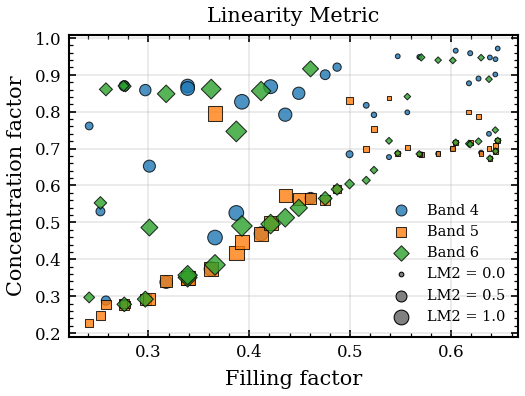

<IPython.core.display.Math object>

In [47]:
# ===========================================================================
# Filling Factor vs Concentration Factor, dot size ∝ Linearity Metric 2
# ===========================================================================
# CF(band) = ∫_diel ε|E|² / ∫_all ε|E|²   at Γ
# ===========================================================================
import json

SIMULATE_CF_LIN = False # Set to True to run CF simulations, False to load existing data
cf_cache_path = os.path.join(data_rooth, f"{name_2D_optimized}_cf_lin_cache.json")

# --- Gamma-only config WITH E-field output ---
config_cf_lin = dict(
    resolution=RESOLUTION,
    num_bands=8,
    k_points=[mp.Vector3(0, 0, 0)],
    extra_runner_command="output-efield",
)
mpb_config_cf_lin = MPBSchemeConfigurator(photonic_crystal_2D, ["te"], **config_cf_lin)
script_cf_lin = mpb_config_cf_lin.get_scheme_config(join_newline=True)

# --- One Simulation per valid sims_lin entry ---
valid_entries_cf = [e for e in sims_lin if e["is_valid"]]
sims_cf_lin = []
for j, entry in enumerate(valid_entries_cf):
    sim_name = f"{name_2D_optimized}_cf_lin_{j:03d}"
    sim_cf = Simulation(
        simulation_name=sim_name,
        script=script_cf_lin,
        directory=os.path.join(data_rooth, sim_name),
    )
    sims_cf_lin.append({
        'r1': entry['r1'], 'r2': entry['r2'], 'sim': sim_cf,
        'entry': entry,
    })

# --- Run (fast – single k-point) ---
if SIMULATE_CF_LIN:
    print(f"Running {len(sims_cf_lin)} Γ-only simulations with E-field output …")
    def run_cf_sim(args):
        j, s = args
        s['sim'].run_hpc(
            mpb_command_line_params=dict(r1=s['r1'], r2=s['r2']),
            mpi=True, load_epsilon=False)
        return j

    with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
        futures = {pool.submit(run_cf_sim, (j, s)): j for j, s in enumerate(sims_cf_lin)}
        for fut in as_completed(futures):
            j = fut.result()
            print(f"  [{j+1}/{len(sims_cf_lin)}] r1={sims_cf_lin[j]['r1']:.4f}, "
                  f"r2={sims_cf_lin[j]['r2']:.4f} done")
    print("All CF-linearity simulations completed.")
else:
    print("SIMULATE_CF_LIN=False → loading existing CF data")

# --- Compute or load concentration factors for bands 4, 5, 6 ---
bands_cf_lin = [4, 5, 6]
opt_cf_lin = MPBDataOptions(rectify=True, periods=1)

if os.path.exists(cf_cache_path) and not SIMULATE_CF_LIN:
    # Load cached CF data
    with open(cf_cache_path, 'r') as f:
        cf_cache = json.load(f)
    cf_lin_data = {int(k): v for k, v in cf_cache.items()}
    print(f"Loaded cached CF data from {cf_cache_path} ({len(cf_lin_data[bands_cf_lin[0]])} entries)")
else:
    # Compute CF from simulation field data
    cf_lin_data = {b: [] for b in bands_cf_lin}

    for j, s in enumerate(sims_cf_lin):
        sim = s['sim']
        try:
            eps = sim.load_and_convert_epsilon_data(options=opt_cf_lin)
            if eps.ndim == 3:
                eps = eps[:, :, eps.shape[2] // 2]

            eps_mid = (1.0 + eps.max()) / 2.0
            diel_mask = eps > eps_mid

            for band in bands_cf_lin:
                Ex = sim.load_and_convert_field_data(
                    1, band, "x", "te", "e", conversion_options=opt_cf_lin)
                Ey = sim.load_and_convert_field_data(
                    1, band, "y", "te", "e", conversion_options=opt_cf_lin)
                if Ex.ndim == 3:
                    Ex = Ex[:, :, Ex.shape[2] // 2]
                if Ey.ndim == 3:
                    Ey = Ey[:, :, Ey.shape[2] // 2]

                eps_Esq = eps * (np.abs(Ex)**2 + np.abs(Ey)**2)
                total = eps_Esq.sum()
                cf = float(eps_Esq[diel_mask].sum() / total) if total > 0 else None
                cf_lin_data[band].append(cf)

        except Exception as e:
            print(f"  Error j={j}, r1={s['r1']:.4f}, r2={s['r2']:.4f}: {e}")
            for band in bands_cf_lin:
                cf_lin_data[band].append(None)

    # Save to cache
    cf_cache_save = {str(k): v for k, v in cf_lin_data.items()}
    with open(cf_cache_path, 'w') as f:
        json.dump(cf_cache_save, f)
    print(f"Saved CF data to {cf_cache_path}")

    # Convert None → NaN for numpy compatibility
    cf_lin_data = {b: [x if x is not None else float('nan') for x in vals]
                   for b, vals in cf_lin_data.items()}

# Store CF back into valid entries
for j, s in enumerate(sims_cf_lin):
    for band in bands_cf_lin:
        s['entry'][f'cf_band_{band}'] = cf_lin_data[band][j]

# --- Compute linearity metric v2 for chosen delta_k ---
delta_k_plot = 0.001
lm_v2_vals = np.array([linearity_metric_v2(s['entry'], delta_k=delta_k_plot) for s in sims_cf_lin])
# Normalize by max for better plotting
lm_v2_vals /= lm_v2_vals.max()
ff_cf = np.array([s['entry']['ff'] for s in sims_cf_lin])

print(f"\nConcentration-factor statistics (N = {len(sims_cf_lin)}, Δk = {delta_k_plot}):")
for band in bands_cf_lin:
    v = np.array(cf_lin_data[band], dtype=float)
    v = v[~np.isnan(v)]
    if len(v) > 0:
        print(f"  Band {band}: CF = {v.mean():.4f} ± {v.std():.4f}  [{v.min():.4f}, {v.max():.4f}]")

# ===========================================================================
# 2D Plot: x = Filling Factor, y = Concentration Factor
#          dot size ∝ Linearity Metric 2,  dot color = band
# ===========================================================================
band_colors = {4: 'tab:blue', 5: 'tab:orange', 6: 'tab:green'}
band_markers = {4: 'o', 5: 's', 6: 'D'}

# Normalize LM2 to dot sizes
size_min_lm, size_max_lm = 5, 50
lm_min, lm_max = lm_v2_vals.min(), lm_v2_vals.max()
if lm_max > lm_min:
    lm_norm = (lm_v2_vals - lm_min) / (lm_max - lm_min)
else:
    lm_norm = np.ones_like(lm_v2_vals) * 0.5
dot_sizes_lm = size_min_lm + (size_max_lm - size_min_lm) * lm_norm

fig, ax = plt.subplots( constrained_layout=True)

for band in [4,5,6]:
    cf_vals = np.array(cf_lin_data[band], dtype=float)
    valid_mask = ~np.isnan(cf_vals)
    ax.scatter(ff_cf[valid_mask], cf_vals[valid_mask],
               s=dot_sizes_lm[valid_mask],
               color=band_colors[band], marker=band_markers[band],
               edgecolors='k', linewidth=0.5, alpha=0.8, zorder=3,
               label=f'Band {band}')

ax.set_xlabel('Filling factor')
ax.set_ylabel(r'Concentration factor')
ax.set_title(f'Linearity Metric')
ax.grid(True, alpha=0.3)

# Size legend for LM2 values
for lm_leg in [lm_min, 0.5 * (lm_min + lm_max), lm_max]:
    s_leg = size_min_lm + (size_max_lm - size_min_lm) * (
        (lm_leg - lm_min) / (lm_max - lm_min) if lm_max > lm_min else 0.5)
    ax.scatter([], [], s=s_leg, c='gray', edgecolors='k', linewidth=0.5,
               label=f'LM2 = {lm_leg:.1f}')

ax.legend(loc='best', fontsize=7)
plt.savefig(os.path.join(figure_path, "linearity_metric_v2_vs_CF.png"))
plt.show()


# Latex display of the confinement factor formula
from IPython.display import display, Math
formula = r"""
\text{CF} = \frac{\int_{\text{dielectric}} \varepsilon |\mathbf{E}|^2 \, dV}{\int_{\text{all}} \varepsilon |\mathbf{E}|^2 \, dV}
"""
display(Math(formula))

We need a moderate but not excessive confinement of the doubly degenerate modes in the dielectric

### Effective parameters

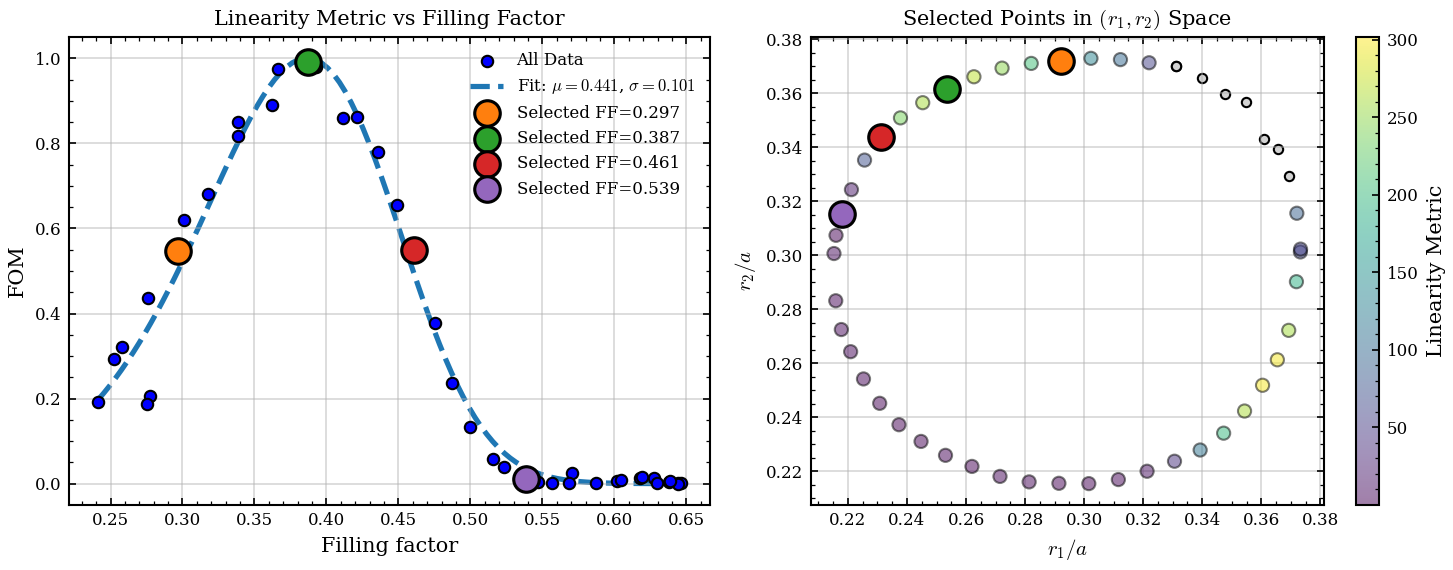

--- Selected Point Geometries ---
Left 50%        | r1: 0.2922, r2: 0.3721, FF: 0.2969
Peak Linearity  | r1: 0.2537, r2: 0.3616, FF: 0.3871
Right 50%       | r1: 0.2312, r2: 0.3438, FF: 0.4607
Baseline Tail   | r1: 0.2179, r2: 0.3153, FF: 0.5385


In [51]:
import numpy as np
import matplotlib.pyplot as plt

# Create a wider figure to hold both subplots comfortably
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

valid_entries = [e for e in sims_lin if e["is_valid"]]
invalid_entries = [e for e in sims_lin if not e["is_valid"]]

ffs = np.array([entry["ff"] for entry in valid_entries])
metrics = np.array([entry["linearity_metric_v2"] for entry in valid_entries])

# --- 1. Curve Matching Logic ---
y_fit_full = skew_gaussian(x_fit, *popt_v2)
true_max_v2 = np.max(y_fit_full)

# Find the exact features of the curve numerically
peak_idx = np.argmax(y_fit_full)
peak_x = x_fit[peak_idx]

left_half_idx = np.argmin(np.abs(y_fit_full[:peak_idx] - 0.5 * true_max_v2))
left_x = x_fit[left_half_idx]

right_half_idx = peak_idx + np.argmin(np.abs(y_fit_full[peak_idx:] - 0.5 * true_max_v2))
right_x = x_fit[right_half_idx]

tail_idx = peak_idx + np.argmin(np.abs(y_fit_full[peak_idx:] - 0.05 * true_max_v2))
tail_x = x_fit[tail_idx]

target_ffs = [left_x, peak_x, right_x, tail_x]

# Find closest simulated points to our visual targets
selected_points = []
for target in target_ffs:
    closest_entry = min(valid_entries, key=lambda e: abs(e["ff"] - target))
    if closest_entry not in selected_points:
        selected_points.append(closest_entry)

highlight_colors = ['#ff7f0e', '#2ca02c', '#d62728', '#9467bd'] # Orange, Green, Red, Purple

# ==========================================
# SUBPLOT 1: Metric vs Filling Factor
# ==========================================
ax1.scatter(ffs, metrics / true_max_v2, c='blue', edgecolors='k', s=30, label='All Data', zorder=2)
ax1.plot(x_fit, y_fit_full / true_max_v2, "--", linewidth=2.5, 
         label=f"Fit: $\\mu={mu_v2:.3f}$, $\\sigma={sigma_v2:.3f}$", zorder=1)

# Highlight selected points
for i, point in enumerate(selected_points):
    ax1.scatter(point["ff"], point["linearity_metric_v2"] / true_max_v2,
                s=150, facecolor=highlight_colors[i], edgecolors='k', linewidth=1.5, 
                label=f'Selected FF={point["ff"]:.3f}', zorder=3)

ax1.set_xlabel("Filling factor")
ax1.set_ylabel(r"FOM")
ax1.set_title("Linearity Metric vs Filling Factor")
ax1.grid(True, alpha=0.5)
ax1.legend(fontsize=8, loc='best')

# ==========================================
# SUBPLOT 2: (r1, r2) Parameter Space
# ==========================================
# Plot invalid points underneath if any exist
if invalid_entries:
    r1_inv = [e["r1"] for e in invalid_entries]
    r2_inv = [e["r2"] for e in invalid_entries]
    ax2.scatter(r1_inv, r2_inv, c="lightgray", edgecolors="k", s=20, label="Invalid", zorder=1)

r1_v = [e["r1"] for e in valid_entries]
r2_v = [e["r2"] for e in valid_entries]

# Plot all valid points colored by their unnormalized linearity metric
sc = ax2.scatter(r1_v, r2_v, c=metrics, cmap="viridis", edgecolors="k", s=40, alpha=0.5, zorder=2)
fig.colorbar(sc, ax=ax2, label="Linearity Metric")

# Overlay the exact same 4 selected points with their matching colors
for i, point in enumerate(selected_points):
    ax2.scatter(point["r1"], point["r2"],
                s=150, facecolor=highlight_colors[i], edgecolors='k', linewidth=1.5, 
                zorder=3)

ax2.set_xlabel("$r_1/a$")
ax2.set_ylabel("$r_2/a$")
ax2.set_title("Selected Points in $(r_1, r_2)$ Space")
ax2.grid(True, alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(figure_path, "target_points.png"))  
plt.show()

# Print out the exact parameters for your records
print("--- Selected Point Geometries ---")
labels = ["Left 50%", "Peak Linearity", "Right 50%", "Baseline Tail"]
for i, point in enumerate(selected_points):
    print(f"{labels[i]:<15} | r1: {point['r1']:.4f}, r2: {point['r2']:.4f}, FF: {point['ff']:.4f}")

In [18]:
import phc_nzi.field_analyzer as fa

# ===========================================================================
# Effective Parameter Extraction  (ε_eff, μ_eff, n_eff, Z_eff)
# Uses the selected_points from the previous cell (Left 50%, Peak, Right 50%, Baseline Tail)
# ===========================================================================

# --- Build df_selected from selected_points (determined in previous cell) ---
df_selected = pd.DataFrame([
    {'r1': p['r1'], 'r2': p['r2'], 'filling_factor': p['ff']}
    for p in selected_points
])

print(f"Using {len(selected_points)} points from previous cell:")
for i, p in enumerate(selected_points):
    print(f"  [{i}] {labels[i]:<15} | r1={p['r1']:.4f}, r2={p['r2']:.4f}, ff={p['ff']:.4f}")

# --- Configuration for nonbloch fields ---
k_points_eff = {
    "k_points_values": [
        mp.Vector3(0.15, 0, 0),
        mp.Vector3(0.015, 0, 0),
    ],
    "k_points_label": [
        r"$\Gamma$",
        r"$k_x$",
    ],
}

config_eff = dict(
    resolution=RESOLUTION,
    num_bands=6,
    k_points=k_points_eff["k_points_values"],
    k_points_interpolation_factor=20,
    extra_runner_command=(
        "fix-hfield-phase fix-efield-phase "
        "output-hfield output-nonbloch-efield-y output-nonbloch-hfield-z"
    ),
)
mpb_config_eff = MPBSchemeConfigurator(photonic_crystal_2D, ["te"], **config_eff)
script_eff = mpb_config_eff.get_scheme_config(join_newline=True)

SIMULATE_EFF = False   # ← Set True to run simulations on HPC

# --- Cache file for effective parameters ---
eff_cache_file = os.path.join(data_rooth, f"{name_2D_optimized}_effective_params_selected.csv")

if os.path.exists(eff_cache_file) and not SIMULATE_EFF:
    # ---- Load cached results ----
    df_eff = pd.read_csv(eff_cache_file)
    for col_name in ['eps', 'mu', 'impedance', 'n_eff']:
        df_eff[col_name] = df_eff[f'{col_name}_re'] + 1j * df_eff[f'{col_name}_im']
    print(f"Loaded cached effective parameters from:\n  {eff_cache_file}")
    print(f"  {len(df_eff)} rows, {df_eff['r1'].nunique()} unique (r1, r2) points")
else:
    # ---- Compute from field data ----
    eff_results_all = []

    for i, row in df_selected.iterrows():
        r1_pt = row['r1']
        r2_pt = row['r2']
        tag = f"r1_{r1_pt:.4f}_r2_{r2_pt:.4f}".replace(".", "p")
        sim_name = f"{name_2D_optimized}_eff_{tag}"
        sim_eff = Simulation(
            simulation_name=sim_name,
            script=script_eff,
            directory=os.path.join(data_rooth, sim_name),
        )

        if SIMULATE_EFF:
            print(f"[{i+1}/{len(df_selected)}] Running: r1={r1_pt:.4f}, r2={r2_pt:.4f}")
            sim_eff.run_hpc(
                mpb_command_line_params=dict(r1=r1_pt, r2=r2_pt), mpi=True
            )
        else:
            print(f"[{i+1}/{len(df_selected)}] Using existing data "
                  f"(r1={r1_pt:.4f}, r2={r2_pt:.4f})")

        # --- Extract effective parameters ---
        try:
            analyzer_eff = fa.FieldAnalyzer(sim_eff, [4, 6], "te", "x")
            data_eff = analyzer_eff.get_eps_mu_impedance_neff("y", "z", plot=False)
            data_eff['r1'] = r1_pt
            data_eff['r2'] = r2_pt
            data_eff['filling_factor'] = row['filling_factor']
            eff_results_all.append(data_eff)
        except Exception as e:
            print(f"  ⚠ Error at r1={r1_pt:.4f}, r2={r2_pt:.4f}: {e}")

    df_eff = pd.concat(eff_results_all, ignore_index=True)
    print(f"\nExtracted effective parameters for {len(eff_results_all)}/{len(df_selected)} points")

    # ---- Save to CSV (split complex cols into re/im) ----
    df_save = df_eff.copy()
    for col_name in ['eps', 'mu', 'impedance', 'n_eff']:
        df_save[f'{col_name}_re'] = np.real(df_save[col_name])
        df_save[f'{col_name}_im'] = np.imag(df_save[col_name])
    df_save = df_save.drop(columns=['eps', 'mu', 'impedance', 'n_eff'])
    df_save.to_csv(eff_cache_file, index=False)
    print(f"Saved effective parameters to:\n  {eff_cache_file}")

# --- Compute shifted frequency (Dirac freq per design point) ---
for (r1_val, r2_val), grp in df_eff.groupby(['r1', 'r2']):
    k1_b4 = grp.loc[(grp['band'] == 4) & (grp['k_index'] == grp['k_index'].min()), 'frequency'].values[0]
    k1_b6 = grp.loc[(grp['band'] == 6) & (grp['k_index'] == grp['k_index'].min()), 'frequency'].values[0]
    omega_D = 0.5 * (k1_b4 + k1_b6)
    df_eff.loc[grp.index, 'omega_dirac'] = omega_D
    df_eff.loc[grp.index, 'freq_shifted'] = grp['frequency'] - omega_D

Using 4 points from previous cell:
  [0] Left 50%        | r1=0.2922, r2=0.3721, ff=0.2969
  [1] Peak Linearity  | r1=0.2537, r2=0.3616, ff=0.3871
  [2] Right 50%       | r1=0.2312, r2=0.3438, ff=0.4607
  [3] Baseline Tail   | r1=0.2179, r2=0.3153, ff=0.5385
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
Loaded cached effective parameters from:
  /work3/enrva/phc_nzi_data/MPB_data/C4v_diatomic_holes_1_2D_optimized_effective_params_selected.csv
  176 rows, 4 unique (r1, r2) points


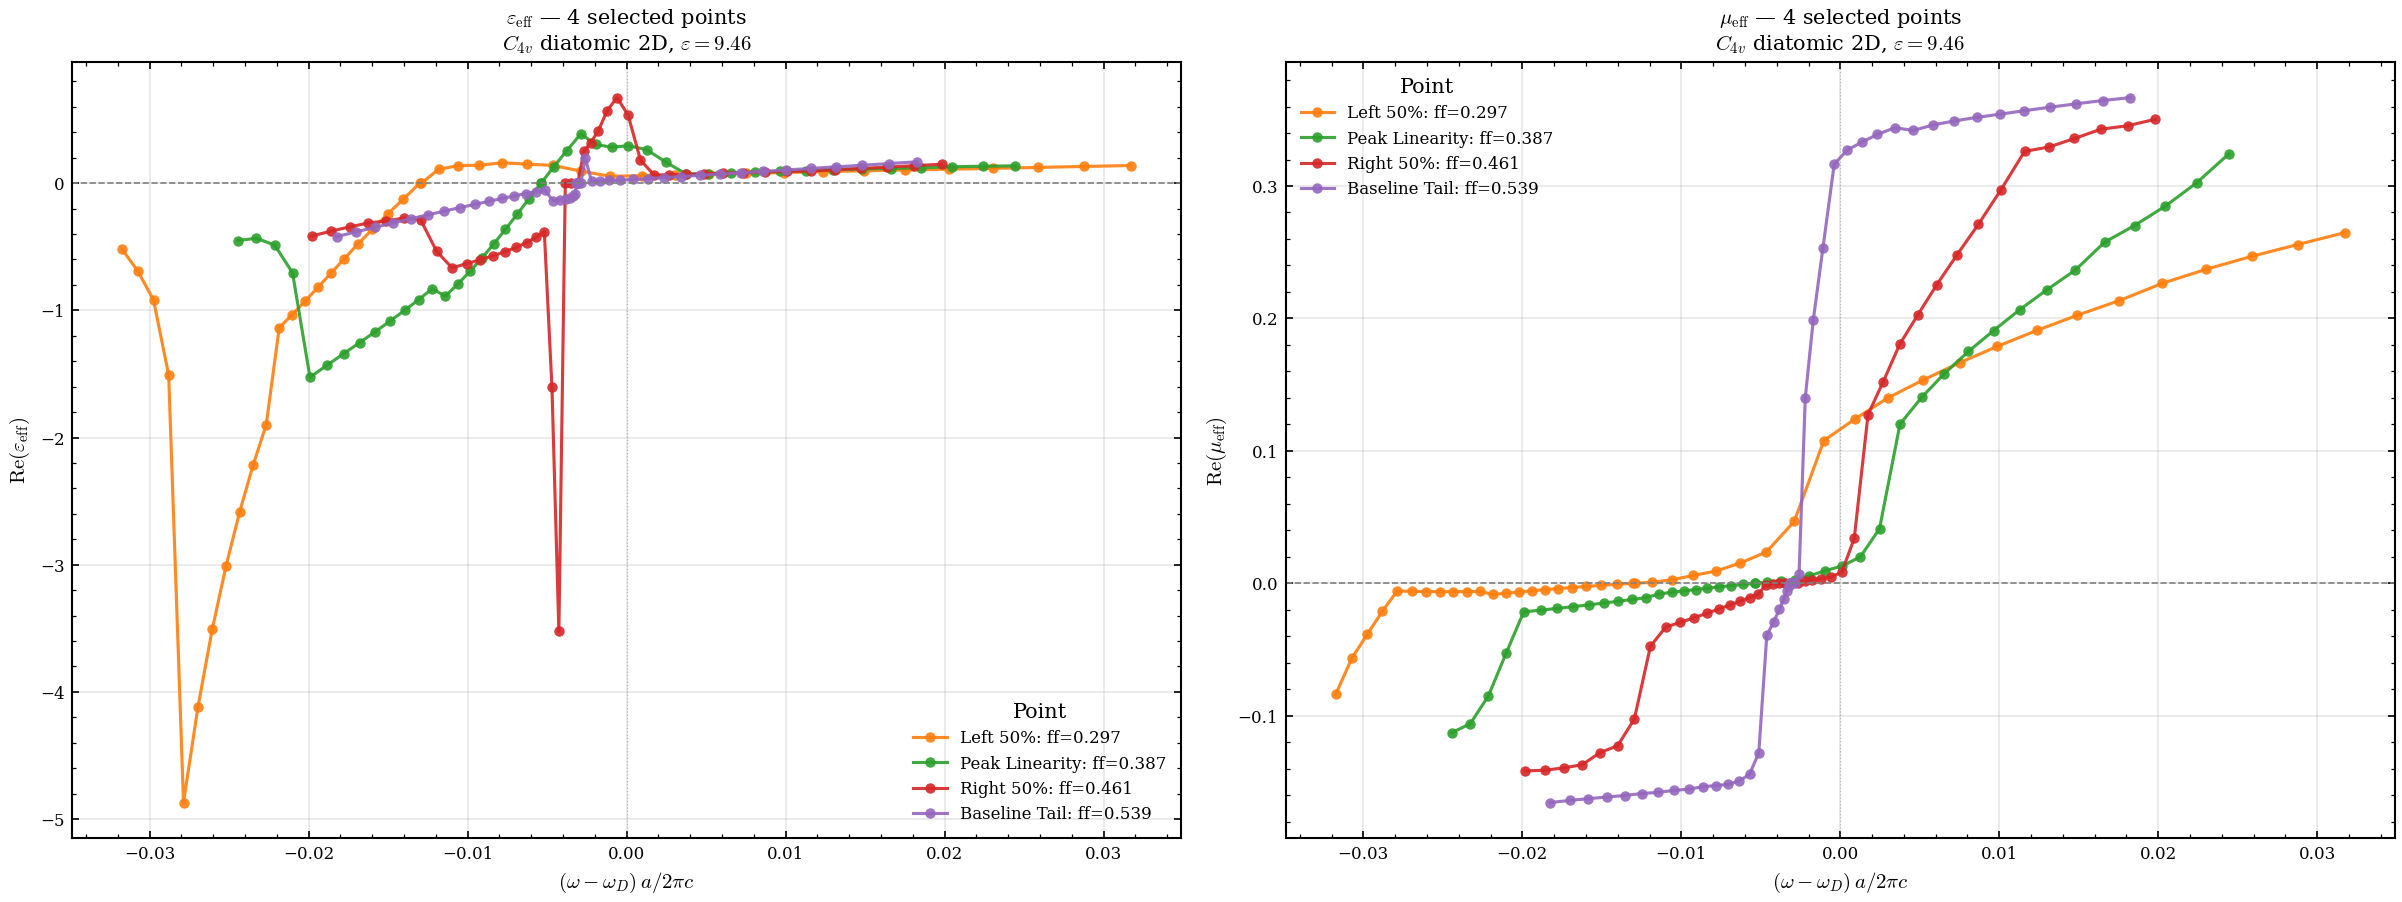

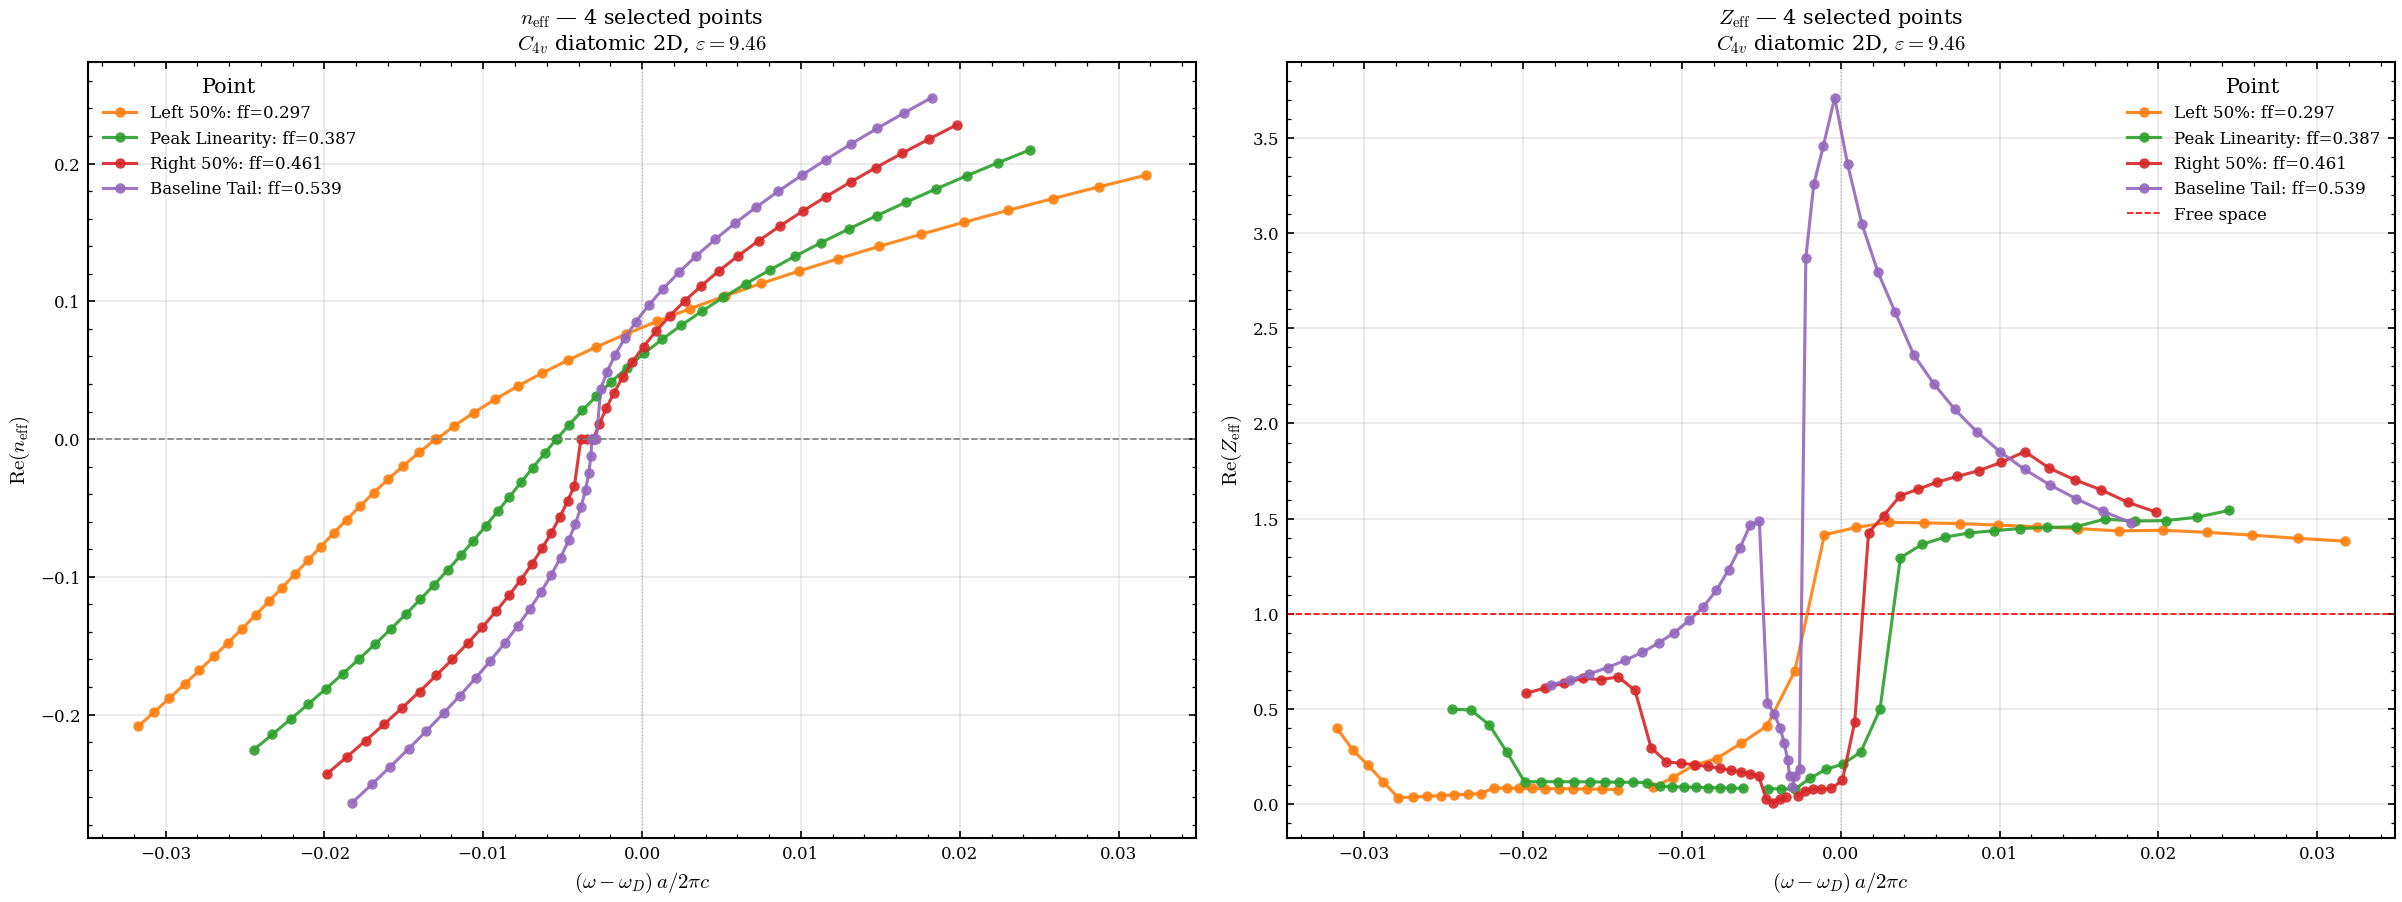


Effective parameter extraction complete (4 points).


In [19]:
# ===========================================================================
# Plot ε_eff and μ_eff vs shifted frequency for the selected points
# Colors match highlight_colors from cell 27
# ===========================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# Build per-point labels using selected_points and labels from cell 27
unique_pts = df_eff[['r1', 'r2']].drop_duplicates().reset_index(drop=True)
point_labels = []
point_colors = []
for idx, pt_row in unique_pts.iterrows():
    # Match to selected_points by r1, r2
    match_idx = None
    for si, sp in enumerate(selected_points):
        if np.isclose(sp['r1'], pt_row['r1'], atol=1e-6) and np.isclose(sp['r2'], pt_row['r2'], atol=1e-6):
            match_idx = si
            break
    if match_idx is not None:
        lbl = labels[match_idx]
        ff_pt = selected_points[match_idx]['ff']
        col = highlight_colors[match_idx]
    else:
        lbl = f"Point {idx}"
        ff_pt = 1 - np.pi * (pt_row['r1']**2 + pt_row['r2']**2)
        col = plt.cm.tab10(idx / max(len(unique_pts) - 1, 1))
    point_labels.append(f"{lbl}: ff={ff_pt:.3f}")
    point_colors.append(col)

# Set marker size (5 in plot is roughly equivalent to s=20 in scatter)
msize = 5 

for idx, (pt_row, label, color) in enumerate(zip(unique_pts.itertuples(), point_labels, point_colors)):
    mask_pt = (df_eff['r1'] == pt_row.r1) & (df_eff['r2'] == pt_row.r2)
    sub = df_eff[mask_pt].sort_values('freq_shifted')

    # Changed from scatter to plot with lines and markers
    axes[0].plot(sub['freq_shifted'], np.real(sub['eps']),
                 color=color, marker='o', markersize=msize, alpha=0.9, 
                 ls='-', lw=1.5, markeredgewidth=0, label=label)
                 
    axes[1].plot(sub['freq_shifted'], np.real(sub['mu']),
                 color=color, marker='o', markersize=msize, alpha=0.9, 
                 ls='-', lw=1.5, markeredgewidth=0, label=label)

n_sel = len(selected_points)
for ax, ylabel, title_var in zip(
    axes,
    [r'$\mathrm{Re}(\varepsilon_{\mathrm{eff}})$',
     r'$\mathrm{Re}(\mu_{\mathrm{eff}})$'],
    [r'\varepsilon', r'\mu'],
):
    ax.set_xlabel(r'$(\omega - \omega_D)\, a/2\pi c$')
    ax.set_ylabel(ylabel)
    ax.set_title(rf'${title_var}_{{\mathrm{{eff}}}}$ — {n_sel} selected points'
                 f'\n$C_{{4v}}$ diatomic 2D, $\\varepsilon={eps_inp}$')
    ax.axhline(0, color='gray', ls='--', lw=0.8)
    ax.axvline(0, color='gray', ls=':', lw=0.6, alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, title='Point', loc='best')

plt.show()

# ===========================================================================
# Plot n_eff and Z_eff vs shifted frequency for the selected points
# ===========================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

for idx, (pt_row, label, color) in enumerate(zip(unique_pts.itertuples(), point_labels, point_colors)):
    mask_pt = (df_eff['r1'] == pt_row.r1) & (df_eff['r2'] == pt_row.r2)
    sub = df_eff[mask_pt].sort_values('freq_shifted')

    # Changed from scatter to plot with lines and markers
    axes[0].plot(sub['freq_shifted'], np.real(sub['n_eff']),
                 color=color, marker='o', markersize=msize, alpha=0.9, 
                 ls='-', lw=1.5, markeredgewidth=0, label=label)
                 
    axes[1].plot(sub['freq_shifted'], np.real(sub['impedance']),
                 color=color, marker='o', markersize=msize, alpha=0.9, 
                 ls='-', lw=1.5, markeredgewidth=0, label=label)

for ax, ylabel, title_var in zip(
    axes,
    [r'$\mathrm{Re}(n_{\mathrm{eff}})$',
     r'$\mathrm{Re}(Z_{\mathrm{eff}})$'],
    ['n', 'Z'],
):
    ax.set_xlabel(r'$(\omega - \omega_D)\, a/2\pi c$')
    ax.set_ylabel(ylabel)
    ax.set_title(rf'${title_var}_{{\mathrm{{eff}}}}$ — {n_sel} selected points'
                 f'\n$C_{{4v}}$ diatomic 2D, $\\varepsilon={eps_inp}$')
    ax.axhline(0 if title_var == 'n' else 1, color='gray' if title_var == 'n' else 'red',
               ls='--', lw=0.8, label='Free space' if title_var == 'Z' else '')
    ax.axvline(0, color='gray', ls=':', lw=0.6, alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, title='Point', loc='best')

plt.show()

print(f"\nEffective parameter extraction complete ({n_sel} points).")

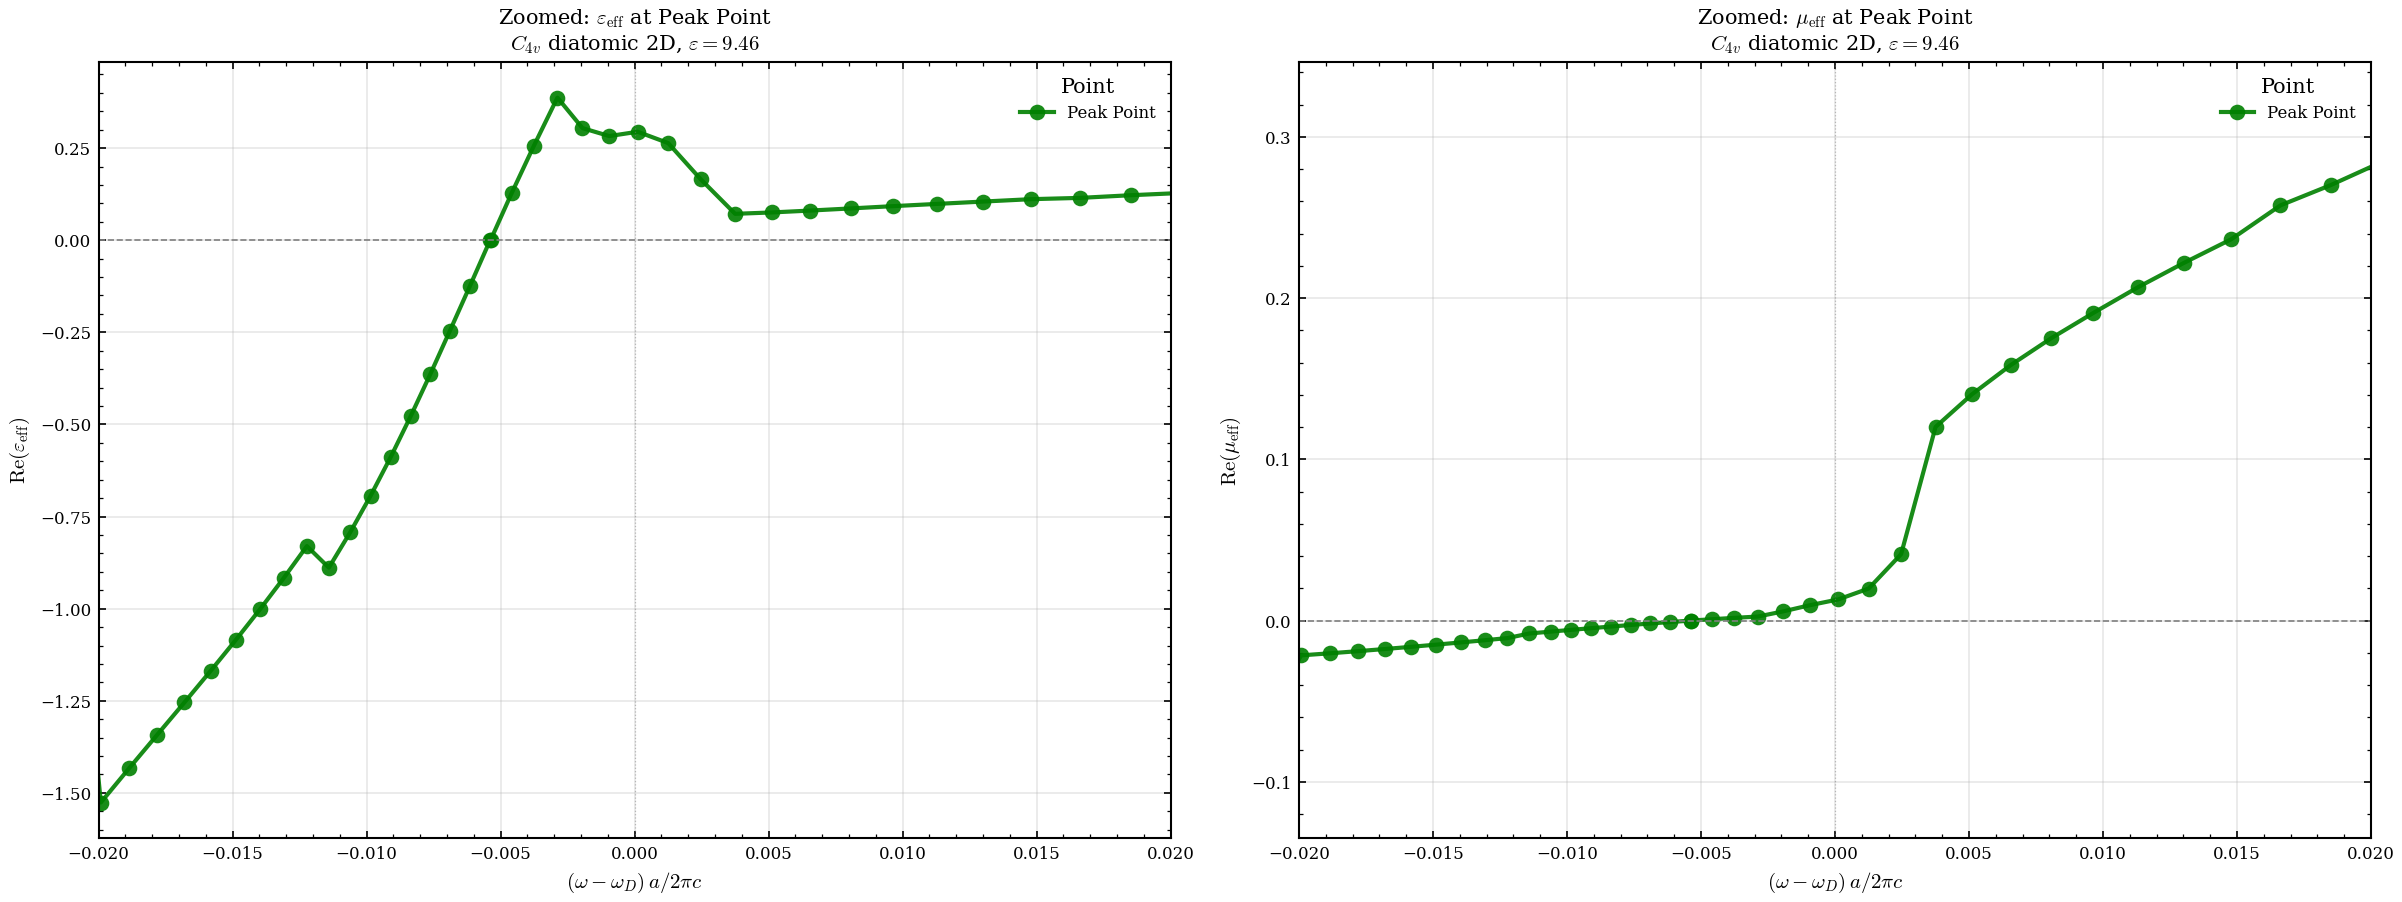

(0.6, 0.75)

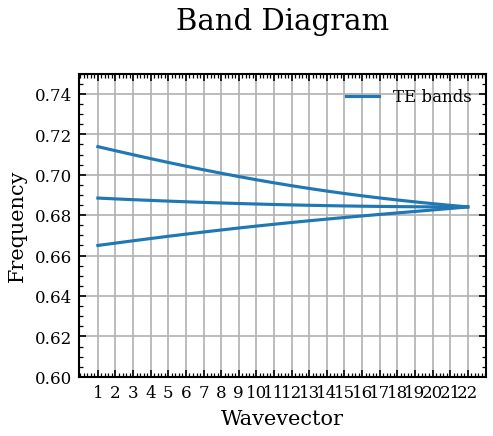

In [20]:
# plot the effective parameters for the peak point only, with a zoomed-in view around the Dirac frequency
peak_point = selected_points[1]  # Assuming the second point is the peak based on previous logic
mask_peak = (df_eff['r1'] == peak_point['r1'])
sub_peak = df_eff[mask_peak].sort_values('freq_shifted')
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
# Plot ε_eff and μ_eff for the peak point
axes[0].plot(sub_peak['freq_shifted'], np.real(sub_peak['eps']),
             color='green', marker='o', markersize=msize*1.5, alpha=0.9, ls='-', lw=2, markeredgewidth=0, label='Peak Point')
axes[1].plot(sub_peak['freq_shifted'], np.real(sub_peak['mu']),
             color='green', marker='o', markersize=msize*1.5, alpha=0.9, ls='-', lw=2, markeredgewidth=0, label='Peak Point')
# Set zoomed-in limits around the Dirac frequency   
axes[0].set_xlim(-0.02, 0.02)
axes[1].set_xlim(-0.02, 0.02)
for ax, ylabel, title_var in zip(
    axes,
    [r'$\mathrm{Re}(\varepsilon_{\mathrm{eff}})$',
     r'$\mathrm{Re}(\mu_{\mathrm{eff}})$'],
    [r'\varepsilon', r'\mu'],
):
    ax.set_xlabel(r'$(\omega - \omega_D)\, a/2\pi c$')
    ax.set_ylabel(ylabel)
    ax.set_title(rf'Zoomed: ${title_var}_{{\mathrm{{eff}}}}$ at Peak Point'
                 f'\n$C_{{4v}}$ diatomic 2D, $\\varepsilon={eps_inp}$')
    ax.axhline(0, color='gray', ls='--', lw=0.8)
    ax.axvline(0, color='gray', ls=':', lw=0.6, alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, title='Point', loc='best')
plt.show()

# plot its band diagram with the Dirac point highlighted
sim_name_peak = f"{name_2D_optimized}_eff_r1_{peak_point['r1']:.4f}_r2_{peak_point['r2']:.4f}".replace(".", "p")
sim_peak = Simulation(
    simulation_name=sim_name_peak,
    script=script_eff,
    directory=os.path.join(data_rooth, sim_name_peak),
)
viewer_2D = SimulationViewer(sim_peak)
viewer_2D.plot_band_diagram("te")

plt.ylim(0.6,0.75)


Band 4: 0 phase jump(s) > 90° out of 21 steps


Font 'default' does not have a glyph for '\u2713' [U+2713], substituting with a dummy symbol.


Band 6: 1 phase jump(s) > 90° out of 21 steps
  → jump at k_index=22 (Δφ = -90.0°)


Font 'default' does not have a glyph for '\u26a0' [U+26a0], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2713' [U+2713], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u26a0' [U+26a0], substituting with a dummy symbol.


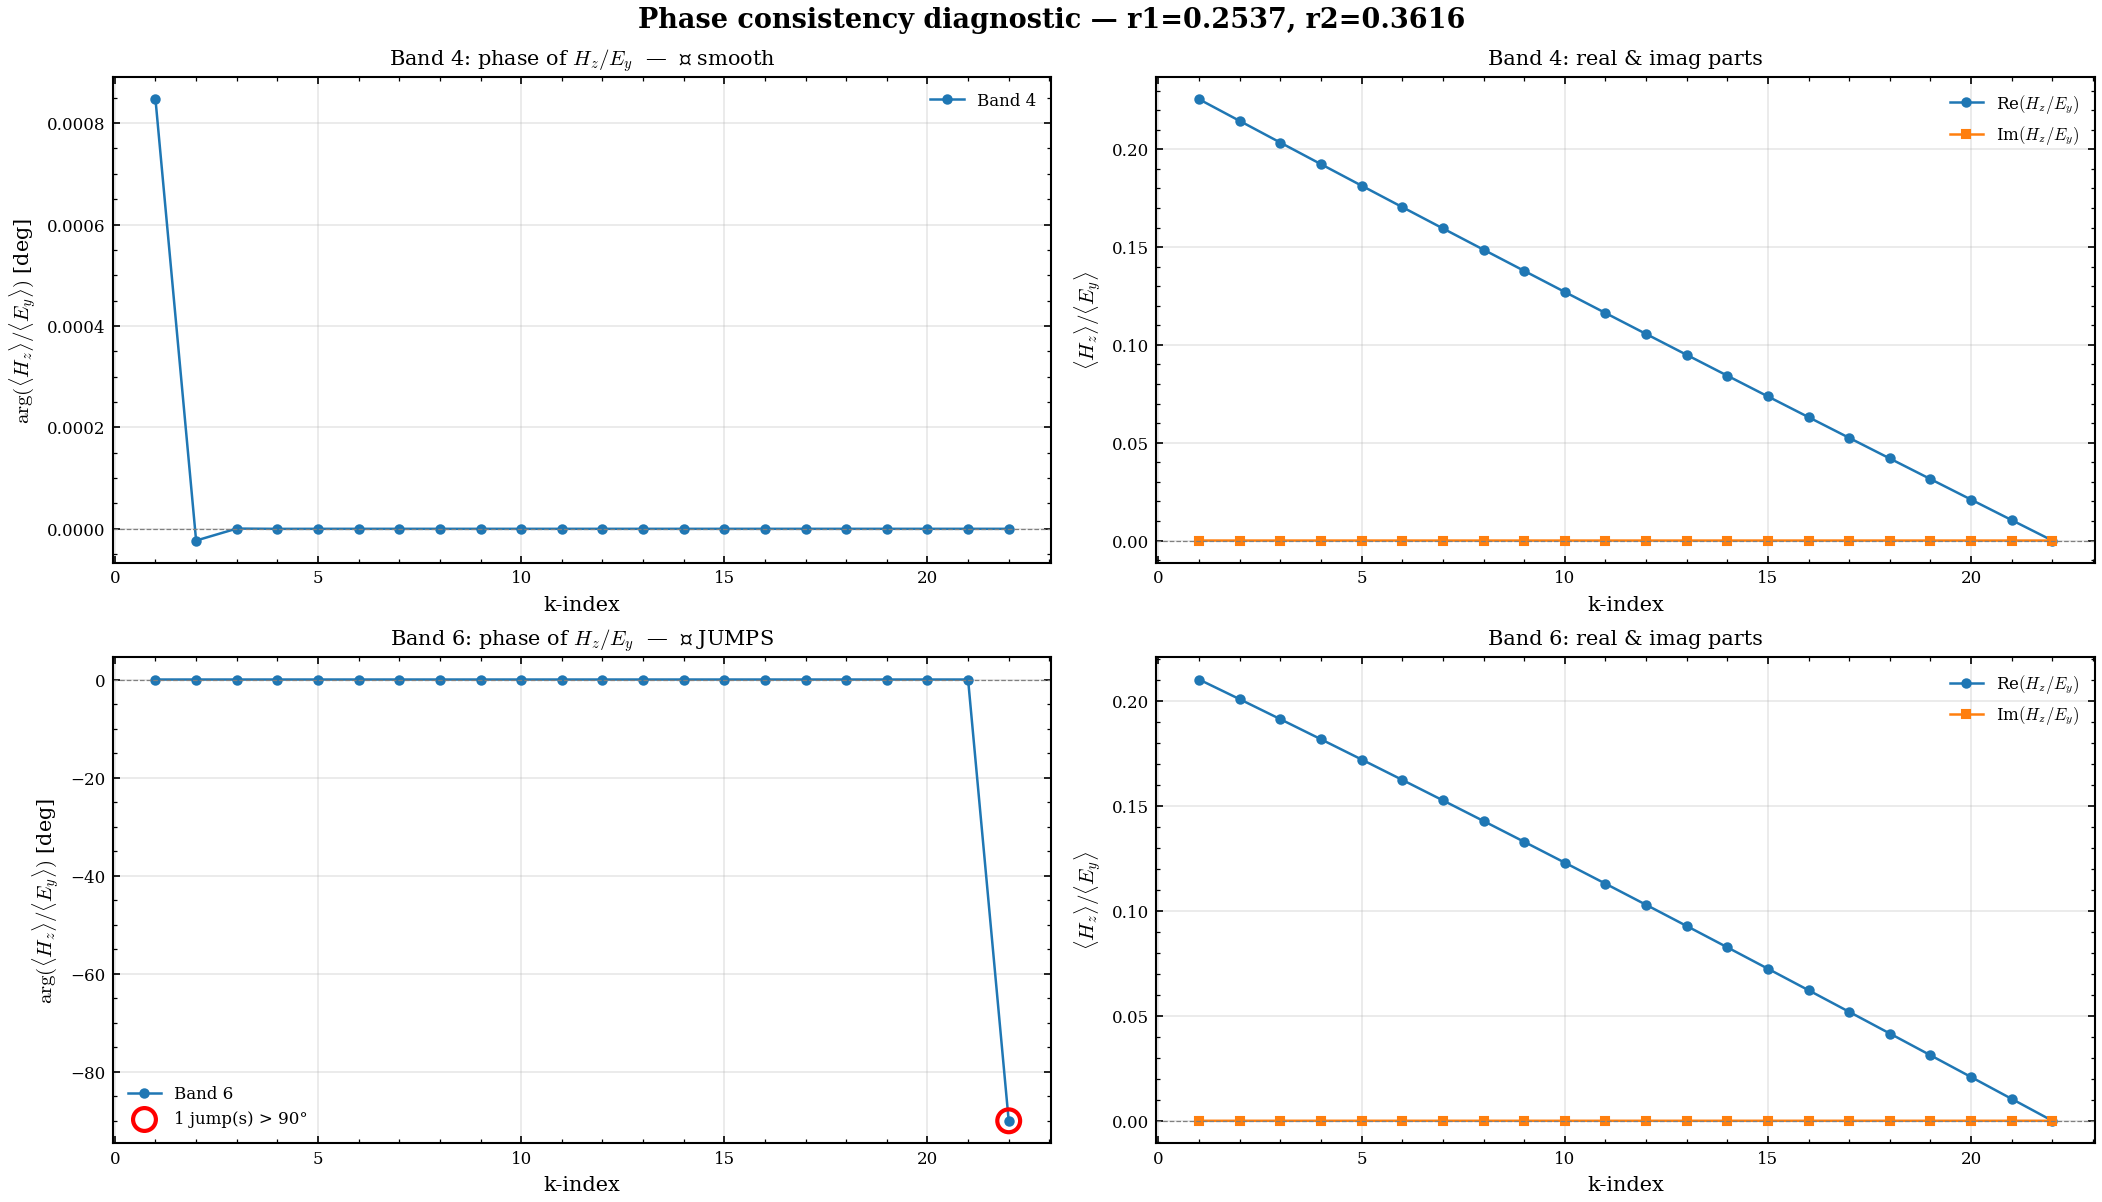

In [21]:
# ===========================================================================
# Phase diagnostic: check angle(H_z / E_y) across k-points
# A ~π jump between consecutive k-points means the phase fixing is
# inconsistent (fix-hfield-phase + fix-efield-phase pick signs independently)
# ===========================================================================
import phc_nzi.field_analyzer as fa
import numpy as np
import matplotlib.pyplot as plt

# Use the peak-point simulation (already created in the previous cell)
analyzer_diag = fa.FieldAnalyzer(sim_peak, [4, 6], "te", "x")
k_indices = analyzer_diag.get_k_indices()

fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

for b_i, band in enumerate([4, 6]):
    phases = []
    ratios_re = []
    ratios_im = []

    for k_idx in k_indices:
        ey = analyzer_diag.load_efield_data(k_idx, band, "y", nonbloch=True)
        hz = analyzer_diag.load_hfield_data(k_idx, band, "z", nonbloch=True)

        # Spatial average (unit cell average)
        ey_avg = ey.mean()
        hz_avg = hz.mean()

        ratio = hz_avg / ey_avg
        phases.append(np.angle(ratio))
        ratios_re.append(ratio.real)
        ratios_im.append(ratio.imag)

    phases = np.array(phases)
    ratios_re = np.array(ratios_re)
    ratios_im = np.array(ratios_im)

    # Detect jumps
    dphase = np.diff(phases)
    dphase_wrapped = (dphase + np.pi) % (2 * np.pi) - np.pi
    jumps = np.abs(dphase_wrapped) > np.pi / 2
    n_jumps = jumps.sum()

    # --- Left column: phase vs k-index ---
    ax = axes[b_i, 0]
    ax.plot(k_indices, np.degrees(phases), 'o-', ms=4, lw=1.2, label=f'Band {band}')
    if n_jumps > 0:
        jump_k = np.array(k_indices)[1:][jumps]
        jump_ph = np.degrees(phases[1:][jumps])
        ax.scatter(jump_k, jump_ph, s=120, facecolors='none', edgecolors='red',
                   linewidths=2, zorder=5, label=f'{n_jumps} jump(s) > 90°')
    ax.set_xlabel('k-index')
    ax.set_ylabel(r'$\arg(\langle H_z \rangle / \langle E_y \rangle)$ [deg]')
    ax.set_title(f'Band {band}: phase of $H_z/E_y$  —  {"⚠ JUMPS" if n_jumps else "✓ smooth"}')
    ax.axhline(0, color='gray', ls='--', lw=0.6)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    # --- Right column: Re and Im of ratio ---
    ax2 = axes[b_i, 1]
    ax2.plot(k_indices, ratios_re, 'o-', ms=4, lw=1.2, label=r'Re$(H_z/E_y)$')
    ax2.plot(k_indices, ratios_im, 's-', ms=4, lw=1.2, label=r'Im$(H_z/E_y)$')
    ax2.set_xlabel('k-index')
    ax2.set_ylabel(r'$\langle H_z \rangle / \langle E_y \rangle$')
    ax2.set_title(f'Band {band}: real & imag parts')
    ax2.axhline(0, color='gray', ls='--', lw=0.6)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=8)

    print(f"Band {band}: {n_jumps} phase jump(s) > 90° out of {len(k_indices)-1} steps")
    if n_jumps:
        for jk in np.array(k_indices)[1:][jumps]:
            print(f"  → jump at k_index={jk} (Δφ = {np.degrees(dphase_wrapped[jk - k_indices[0] - 1]):.1f}°)")

fig.suptitle(f'Phase consistency diagnostic — r1={peak_point["r1"]:.4f}, r2={peak_point["r2"]:.4f}',
             fontsize=13, fontweight='bold')
plt.show()

/tmp/ipykernel_463335/3572564853.py:32: RuntimeWarning: divide by zero encountered in scalar divide
  Z = ey_avg / hz_avg
/tmp/ipykernel_463335/3572564853.py:41: RuntimeWarning: invalid value encountered in scalar divide
  eps_eff = n / Z if Z != 0 else np.nan
/tmp/ipykernel_463335/3572564853.py:42: RuntimeWarning: invalid value encountered in scalar multiply
  mu_eff  = n * Z


ω_D = 0.689464
Total data points: 44


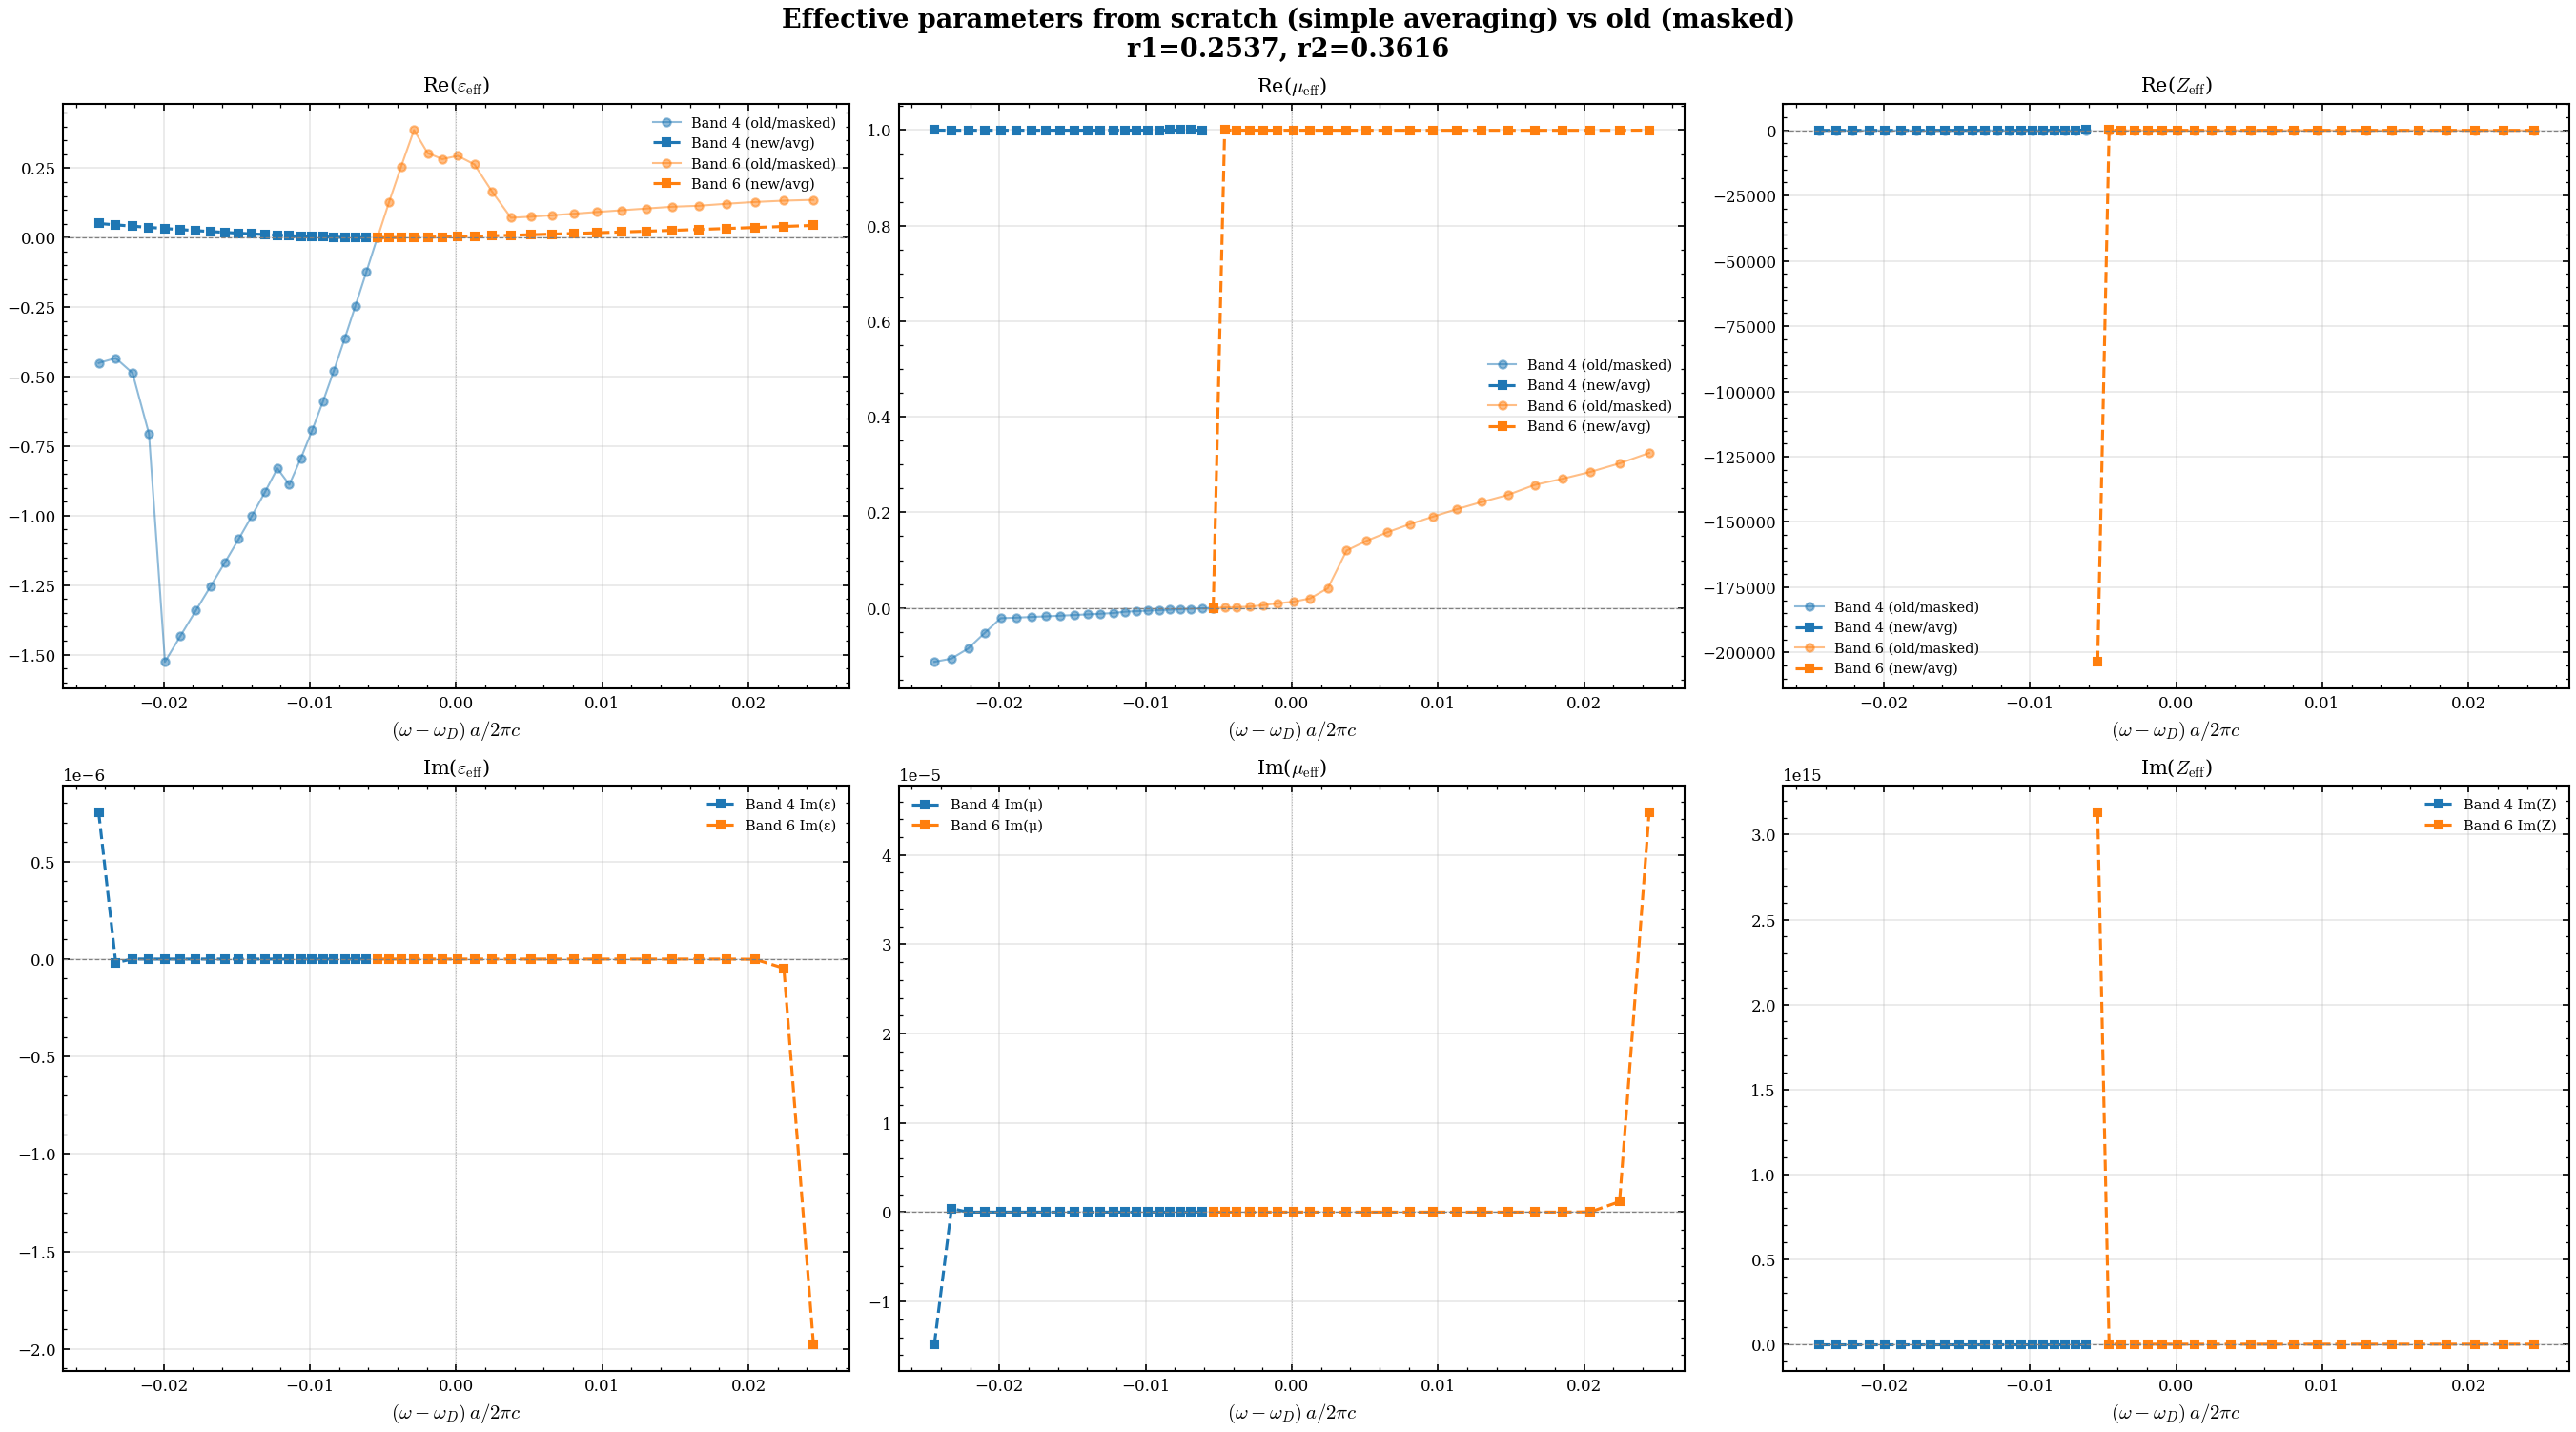


--- Simple-average results (band 4, first 5 k-points) ---
   k_index      kmag      freq  freq_shifted                   Z         n                 eps                  mu
0        1  0.150000  0.665016     -0.024447  4.433492-0.000066j  0.225558  0.050876+0.000001j  1.000012-0.000015j
1        2  0.142857  0.666184     -0.023280  4.662420+0.000002j  0.214441  0.045993-0.000000j  0.999813+0.000000j
2        3  0.135714  0.667331     -0.022132  4.916255-0.000000j  0.203368  0.041367+0.000000j  0.999811-0.000000j
3        4  0.128571  0.668453     -0.021011  5.198141+0.000000j  0.192341  0.037002-0.000000j  0.999816+0.000000j
4        5  0.121429  0.669550     -0.019914  5.512985+0.000000j  0.181359  0.032897-0.000000j  0.999830+0.000000j


In [22]:
# ===========================================================================
# Compute ε_eff and μ_eff FROM SCRATCH via simple field averaging
# (no masking, no sign splitting — just spatial averages)
#
#   Z_eff = <E_y> / <H_z>     (impedance from field ratio)
#   n_eff = k / ω              (refractive index from dispersion)
#   ε_eff = n_eff / Z_eff
#   μ_eff = n_eff * Z_eff
# ===========================================================================
import numpy as np
import matplotlib.pyplot as plt
import phc_nzi.field_analyzer as fa

bands = [4, 6]
analyzer_scratch = fa.FieldAnalyzer(sim_peak, bands, "te", "x")
k_indices = list(analyzer_scratch.get_k_indices())
df_freq = analyzer_scratch.df  # frequency DataFrame

results_scratch = []

for band in bands:
    for k_idx in k_indices:
        # Load nonbloch fields
        ey = analyzer_scratch.load_efield_data(k_idx, band, "y", nonbloch=True)
        hz = analyzer_scratch.load_hfield_data(k_idx, band, "z", nonbloch=True)

        # Simple spatial average over the unit cell
        ey_avg = ey.mean()
        hz_avg = hz.mean()

        # Impedance
        Z = ey_avg / hz_avg

        # k and ω from the band structure
        kmag, freq = analyzer_scratch.get_kmag_and_freq(k_idx, band)

        # Refractive index from dispersion
        n = kmag / freq if freq != 0 else np.nan

        # Effective parameters
        eps_eff = n / Z if Z != 0 else np.nan
        mu_eff  = n * Z

        results_scratch.append({
            'k_index': k_idx, 'band': band,
            'kmag': kmag, 'freq': freq,
            'ey_avg': ey_avg, 'hz_avg': hz_avg,
            'Z': Z, 'n': n,
            'eps': eps_eff, 'mu': mu_eff,
        })

import pandas as pd
df_scratch = pd.DataFrame(results_scratch)

# Compute Dirac frequency (average of bands 4 & 6 at smallest k)
k_min = df_scratch['k_index'].min()
f4_0 = df_scratch.loc[(df_scratch['band'] == 4) & (df_scratch['k_index'] == k_min), 'freq'].values[0]
f6_0 = df_scratch.loc[(df_scratch['band'] == 6) & (df_scratch['k_index'] == k_min), 'freq'].values[0]
omega_D_scratch = 0.5 * (f4_0 + f6_0)
df_scratch['freq_shifted'] = df_scratch['freq'] - omega_D_scratch

print(f"ω_D = {omega_D_scratch:.6f}")
print(f"Total data points: {len(df_scratch)}")

# ===========================================================================
# Plot: compare old (FieldAnalyzer masking) vs new (simple average)
# ===========================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

band_colors = {4: 'C0', 6: 'C1'}

for band in bands:
    c = band_colors[band]

    # --- old data from df_eff (masking method) ---
    old = sub_peak[sub_peak['band'] == band].sort_values('freq_shifted')
    # --- new data from simple averaging ---
    new = df_scratch[df_scratch['band'] == band].sort_values('freq_shifted')

    # Row 0: ε_eff
    axes[0, 0].plot(old['freq_shifted'], np.real(old['eps']),
                    'o-', color=c, ms=4, lw=1, alpha=0.5, label=f'Band {band} (old/masked)')
    axes[0, 0].plot(new['freq_shifted'], np.real(new['eps']),
                    's--', color=c, ms=4, lw=1.5, label=f'Band {band} (new/avg)')

    # Row 0: μ_eff
    axes[0, 1].plot(old['freq_shifted'], np.real(old['mu']),
                    'o-', color=c, ms=4, lw=1, alpha=0.5, label=f'Band {band} (old/masked)')
    axes[0, 1].plot(new['freq_shifted'], np.real(new['mu']),
                    's--', color=c, ms=4, lw=1.5, label=f'Band {band} (new/avg)')

    # Row 0: Z_eff
    axes[0, 2].plot(old['freq_shifted'], np.real(old['impedance']),
                    'o-', color=c, ms=4, lw=1, alpha=0.5, label=f'Band {band} (old/masked)')
    axes[0, 2].plot(new['freq_shifted'], np.real(new['Z']),
                    's--', color=c, ms=4, lw=1.5, label=f'Band {band} (new/avg)')

    # Row 1: imaginary parts
    axes[1, 0].plot(new['freq_shifted'], np.imag(new['eps']),
                    's--', color=c, ms=4, lw=1.5, label=f'Band {band} Im(ε)')
    axes[1, 1].plot(new['freq_shifted'], np.imag(new['mu']),
                    's--', color=c, ms=4, lw=1.5, label=f'Band {band} Im(μ)')
    axes[1, 2].plot(new['freq_shifted'], np.imag(new['Z']),
                    's--', color=c, ms=4, lw=1.5, label=f'Band {band} Im(Z)')

titles = [r'Re($\varepsilon_{\mathrm{eff}}$)', r'Re($\mu_{\mathrm{eff}}$)', r'Re($Z_{\mathrm{eff}}$)',
          r'Im($\varepsilon_{\mathrm{eff}}$)', r'Im($\mu_{\mathrm{eff}}$)', r'Im($Z_{\mathrm{eff}}$)']
for i, ax in enumerate(axes.flat):
    ax.set_xlabel(r'$(\omega - \omega_D)\, a/2\pi c$')
    ax.set_title(titles[i])
    ax.axhline(0, color='gray', ls='--', lw=0.6)
    ax.axvline(0, color='gray', ls=':', lw=0.5, alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='best')

fig.suptitle(f'Effective parameters from scratch (simple averaging) vs old (masked)\n'
             f'r1={peak_point["r1"]:.4f}, r2={peak_point["r2"]:.4f}',
             fontsize=13, fontweight='bold')
plt.show()

# Print a summary table
print("\n--- Simple-average results (band 4, first 5 k-points) ---")
print(df_scratch[df_scratch['band'] == 4][['k_index', 'kmag', 'freq', 'freq_shifted', 'Z', 'n', 'eps', 'mu']].head().to_string())

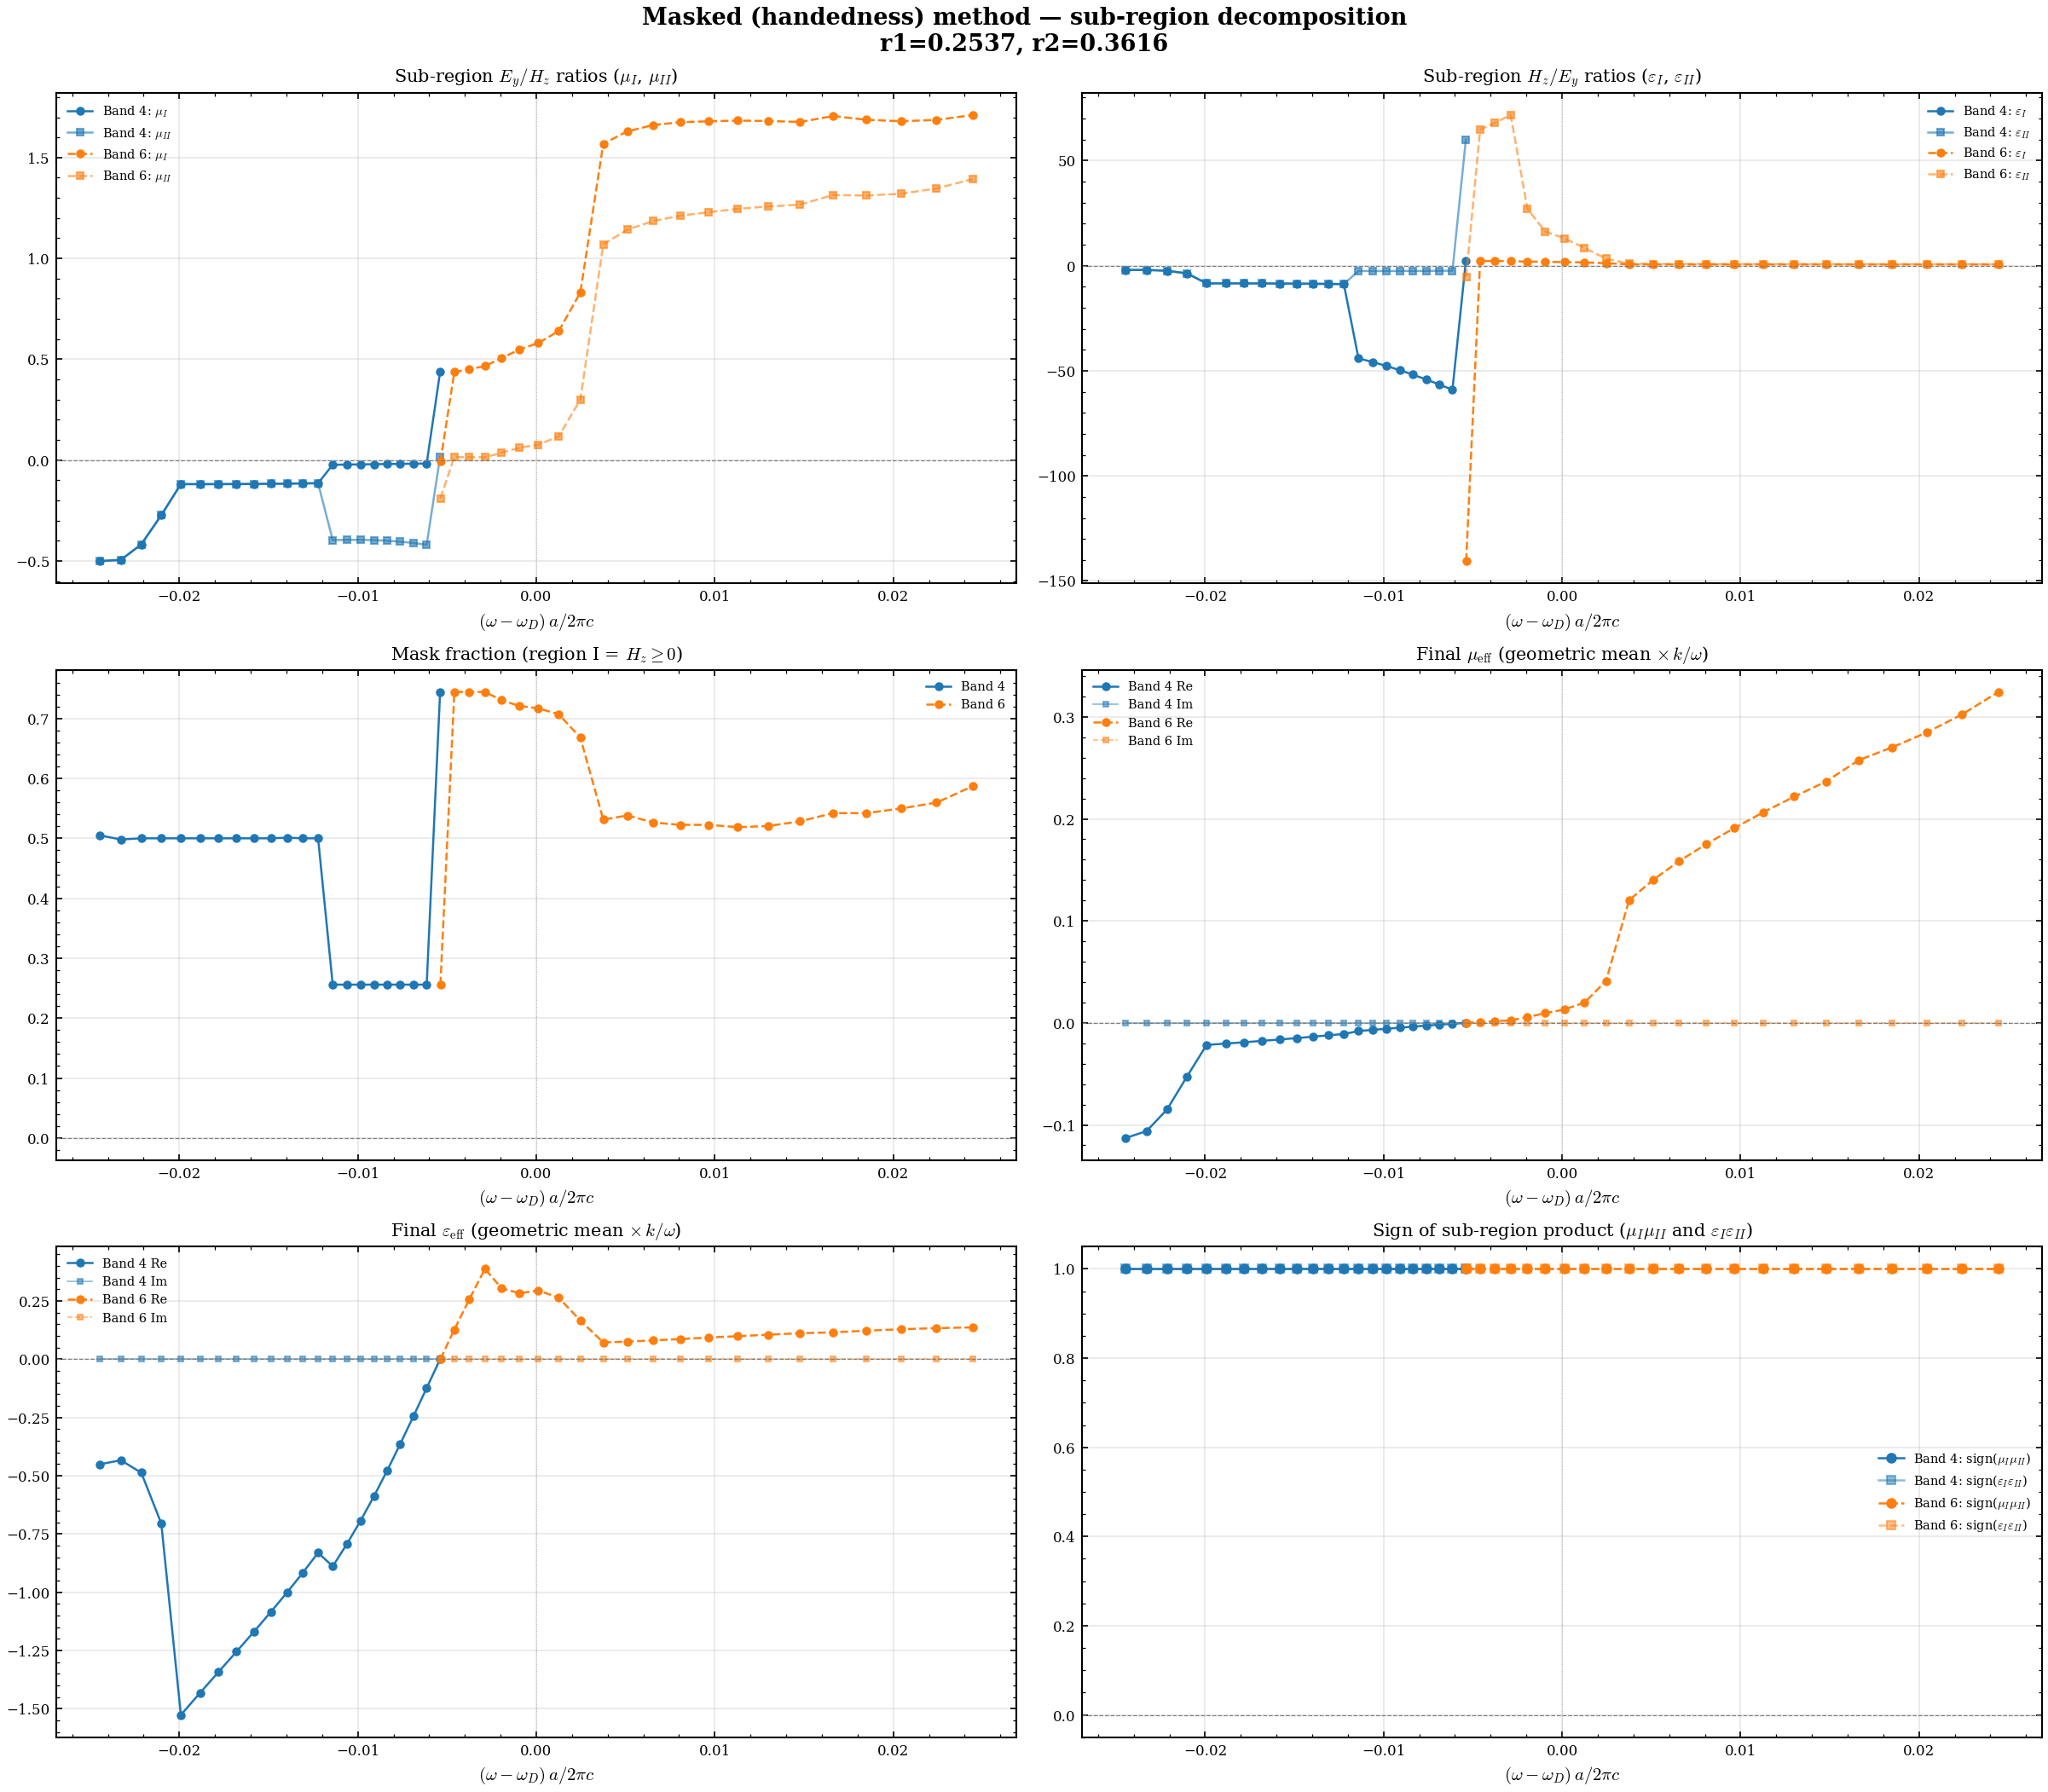

Band 4: μ_I·μ_II ≥ 0 everywhere — geometric mean stays real
Band 6: μ_I·μ_II ≥ 0 everywhere — geometric mean stays real


In [24]:
# ===========================================================================
# Diagnose the masked (handedness) method step by step
# Reproduce the FieldAnalyzer.get_eps_mu logic manually and track:
#   - μ_I, μ_II  (E/H ratio in each handedness region)
#   - mask area fraction  (how many pixels are in region I vs II)
#   - the geometric mean sqrt(μ_I)*sqrt(μ_II) and where it jumps
# ===========================================================================
import numpy as np
import matplotlib.pyplot as plt
import phc_nzi.field_analyzer as fa

bands = [4, 6]
a = fa.FieldAnalyzer(sim_peak, bands, "te", "x")
k_indices = list(a.get_k_indices())

diag = []  # collect per-k, per-band diagnostics

for band in bands:
    for k_idx in k_indices:
        ey = a.load_efield_data(k_idx, band, "y", nonbloch=True)
        hz = a.load_hfield_data(k_idx, band, "z", nonbloch=True)

        # Same masks as FieldAnalyzer.get_eps_mu
        mask_I  = hz.real >= 0
        mask_II = hz.real < 0
        n_pix = hz.size
        frac_I = mask_I.sum() / n_pix

        # Masked averages (set out-of-region pixels to 0, then average over full grid)
        ey_I  = np.where(mask_I,  ey, 0).sum() / n_pix
        ey_II = np.where(mask_II, ey, 0).sum() / n_pix
        hz_I  = np.where(mask_I,  hz, 0).sum() / n_pix
        hz_II = np.where(mask_II, hz, 0).sum() / n_pix

        # E/H ratio per sub-region (real parts only, as in FieldAnalyzer)
        eoh_I  = ey_I.real  / hz_I.real  if hz_I.real  != 0 else np.nan
        eoh_II = ey_II.real / hz_II.real if hz_II.real != 0 else np.nan

        mu_I  = eoh_I
        mu_II = eoh_II
        eps_I  = 1.0 / eoh_I  if eoh_I  != 0 else np.nan
        eps_II = 1.0 / eoh_II if eoh_II != 0 else np.nan

        # Geometric mean (using emath for negative arguments)
        mu_geo  = np.emath.sqrt(mu_I) * np.emath.sqrt(mu_II)
        eps_geo = np.emath.sqrt(eps_I) * np.emath.sqrt(eps_II)

        kmag, freq = a.get_kmag_and_freq(k_idx, band)
        kof = kmag / freq if freq != 0 else np.nan

        diag.append(dict(
            band=band, k_index=k_idx, kmag=kmag, freq=freq,
            frac_I=frac_I,
            ey_I=ey_I, ey_II=ey_II, hz_I=hz_I, hz_II=hz_II,
            eoh_I=eoh_I, eoh_II=eoh_II,
            mu_I=mu_I, mu_II=mu_II, eps_I=eps_I, eps_II=eps_II,
            mu_geo=mu_geo, eps_geo=eps_geo,
            mu_final=mu_geo * kof, eps_final=eps_geo * kof,
        ))

import pandas as pd
dfd = pd.DataFrame(diag)
dfd['freq_shifted'] = dfd['freq'] - omega_D_scratch

# ===========================================================================
# Plot
# ===========================================================================
fig, axes = plt.subplots(3, 2, figsize=(16, 14), constrained_layout=True)

for band in bands:
    sub = dfd[dfd['band'] == band].sort_values('freq_shifted')
    c = {4: 'C0', 6: 'C1'}[band]
    ls = {4: '-', 6: '--'}[band]

    # Row 0: sub-region ratios μ_I, μ_II
    axes[0, 0].plot(sub['freq_shifted'], sub['mu_I'],
                    'o'+ls, color=c, ms=4, lw=1.2, label=f'Band {band}: $\\mu_I$')
    axes[0, 0].plot(sub['freq_shifted'], sub['mu_II'],
                    's'+ls, color=c, ms=4, lw=1.2, alpha=0.6, label=f'Band {band}: $\\mu_{{II}}$')

    # Row 0, right: sub-region ratios ε_I, ε_II
    axes[0, 1].plot(sub['freq_shifted'], sub['eps_I'],
                    'o'+ls, color=c, ms=4, lw=1.2, label=f'Band {band}: $\\varepsilon_I$')
    axes[0, 1].plot(sub['freq_shifted'], sub['eps_II'],
                    's'+ls, color=c, ms=4, lw=1.2, alpha=0.6, label=f'Band {band}: $\\varepsilon_{{II}}$')

    # Row 1: mask fraction
    axes[1, 0].plot(sub['freq_shifted'], sub['frac_I'],
                    'o'+ls, color=c, ms=4, lw=1.2, label=f'Band {band}')

    # Row 1, right: geometric mean μ (final, *= k/ω)
    axes[1, 1].plot(sub['freq_shifted'], np.real(sub['mu_final']),
                    'o'+ls, color=c, ms=4, lw=1.2, label=f'Band {band} Re')
    axes[1, 1].plot(sub['freq_shifted'], np.imag(sub['mu_final']),
                    's'+ls, color=c, ms=3, lw=0.8, alpha=0.5, label=f'Band {band} Im')

    # Row 2: geometric mean ε (final)
    axes[2, 0].plot(sub['freq_shifted'], np.real(sub['eps_final']),
                    'o'+ls, color=c, ms=4, lw=1.2, label=f'Band {band} Re')
    axes[2, 0].plot(sub['freq_shifted'], np.imag(sub['eps_final']),
                    's'+ls, color=c, ms=3, lw=0.8, alpha=0.5, label=f'Band {band} Im')

    # Row 2, right: sign of sub-region products
    sign_mu = np.sign(np.array(sub['mu_I']) * np.array(sub['mu_II']))
    sign_eps = np.sign(np.array(sub['eps_I']) * np.array(sub['eps_II']))
    axes[2, 1].plot(sub['freq_shifted'], sign_mu,
                    'o'+ls, color=c, ms=5, lw=1.2, label=f'Band {band}: sign($\\mu_I \\mu_{{II}}$)')
    axes[2, 1].plot(sub['freq_shifted'], sign_eps,
                    's'+ls, color=c, ms=5, lw=1.2, alpha=0.5, label=f'Band {band}: sign($\\varepsilon_I \\varepsilon_{{II}}$)')

titles = [
    r'Sub-region $E_y/H_z$ ratios ($\mu_I$, $\mu_{II}$)',
    r'Sub-region $H_z/E_y$ ratios ($\varepsilon_I$, $\varepsilon_{II}$)',
    r'Mask fraction (region I = $H_z \geq 0$)',
    r'Final $\mu_{\mathrm{eff}}$ (geometric mean $\times\, k/\omega$)',
    r'Final $\varepsilon_{\mathrm{eff}}$ (geometric mean $\times\, k/\omega$)',
    r'Sign of sub-region product ($\mu_I\mu_{II}$ and $\varepsilon_I \varepsilon_{II}$)',
]
for i, ax in enumerate(axes.flat):
    ax.set_xlabel(r'$(\omega - \omega_D)\, a/2\pi c$')
    ax.set_title(titles[i])
    ax.axhline(0, color='gray', ls='--', lw=0.6)
    ax.axvline(0, color='gray', ls=':', lw=0.5, alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='best')

fig.suptitle('Masked (handedness) method — sub-region decomposition\n'
             f'r1={peak_point["r1"]:.4f}, r2={peak_point["r2"]:.4f}',
             fontsize=13, fontweight='bold')
plt.show()

# Flag any k-points where the product μ_I*μ_II is negative (→ imaginary geometric mean)
for band in bands:
    sub = dfd[dfd['band'] == band]
    neg = sub[sub['mu_I'] * sub['mu_II'] < 0]
    if len(neg):
        print(f"Band {band}: μ_I·μ_II < 0 at k_indices = {list(neg['k_index'])} "
              f"→ geometric mean is IMAGINARY here (discontinuity source)")
    else:
        print(f"Band {band}: μ_I·μ_II ≥ 0 everywhere — geometric mean stays real")

Band 4: reference mask from k_index=22, region I fraction=0.744
Band 6: reference mask from k_index=22, region I fraction=0.256
K-Index: 1, Band: 4, Eps: (-0.9213485872318555+0j), Mu: (-0.055219739705074614+0j), Impedance: (0.244813402798066-0j), N_eff: (-0.22555848280342128+0j)
K-Index: 1, Band: 6, Eps: 1.1506780860802315j, Mu: 0.038365470490109424j, Impedance: (0.18259687602043007+0j), N_eff: 0.2101102238234178j
K-Index: 2, Band: 4, Eps: (-0.7296979583725827+0j), Mu: (-0.06301900248328599+0j), Impedance: (0.29387605192832966-0j), N_eff: (-0.21444075510669722+0j)
K-Index: 2, Band: 6, Eps: 1.2540033892909581j, Mu: 0.03211300866835411j, Impedance: (0.16002621863049948+0j), N_eff: 0.2006734205380622j
K-Index: 3, Band: 4, Eps: (-0.4174852829743875+0j), Mu: (-0.09906620616949607+0j), Impedance: (0.4871269760621306-0j), N_eff: (-0.20336834344575627+0j)
K-Index: 3, Band: 6, Eps: 1.3793491202361767j, Mu: 0.02649565314025712j, Impedance: (0.13859584598887537+0j), N_eff: 0.19117205823314387j
K-

/zhome/2f/7/202918/phc_nzi/src/phc_nzi/field_analyzer.py:175: RuntimeWarning: invalid value encountered in scalar divide
  return np.emath.sqrt(mu/eps)


K-Index: 22, Band: 4, Eps: 0.0, Mu: 0.0, Impedance: nan, N_eff: 0.0
K-Index: 22, Band: 6, Eps: (-0+0j), Mu: (-0+0j), Impedance: (nan+nanj), N_eff: 0j
K-Index: 1, Band: 4, Eps: (-0.4509769062189753+0j), Mu: (-0.11281426712319886+0j), Impedance: (0.5001552844346748-0j), N_eff: (-0.22555848280342128+0j)
K-Index: 1, Band: 6, Eps: 0.1361006033072901, Mu: 0.32436524954597357, Impedance: 1.5437861311241037, N_eff: 0.21011022382341774
K-Index: 2, Band: 4, Eps: (-0.4335163361624533+0j), Mu: (-0.1060740590719018+0j), Impedance: (0.49465438143567225-0j), N_eff: (-0.21444075510669727+0j)
K-Index: 2, Band: 6, Eps: 0.1331168167236892, Mu: 0.3025149090969783, Impedance: 1.5074986427492505, N_eff: 0.20067342053806217
K-Index: 3, Band: 4, Eps: (-0.48702126137963414+0j), Mu: (-0.08492171984177896+0j), Impedance: (0.4175759039136286-0j), N_eff: (-0.2033683434457563+0j)
K-Index: 3, Band: 6, Eps: 0.12833621549015053, Mu: 0.2847735201596421, Impedance: 1.4896189474109578, N_eff: 0.19117205823314387
K-Index:

/zhome/2f/7/202918/phc_nzi/src/phc_nzi/field_analyzer.py:175: RuntimeWarning: invalid value encountered in scalar divide
  return np.emath.sqrt(mu/eps)


K-Index: 22, Band: 4, Eps: 0.0, Mu: 0.0, Impedance: nan, N_eff: 0.0
K-Index: 22, Band: 6, Eps: (-0+0j), Mu: (-0+0j), Impedance: (nan+nanj), N_eff: 0j


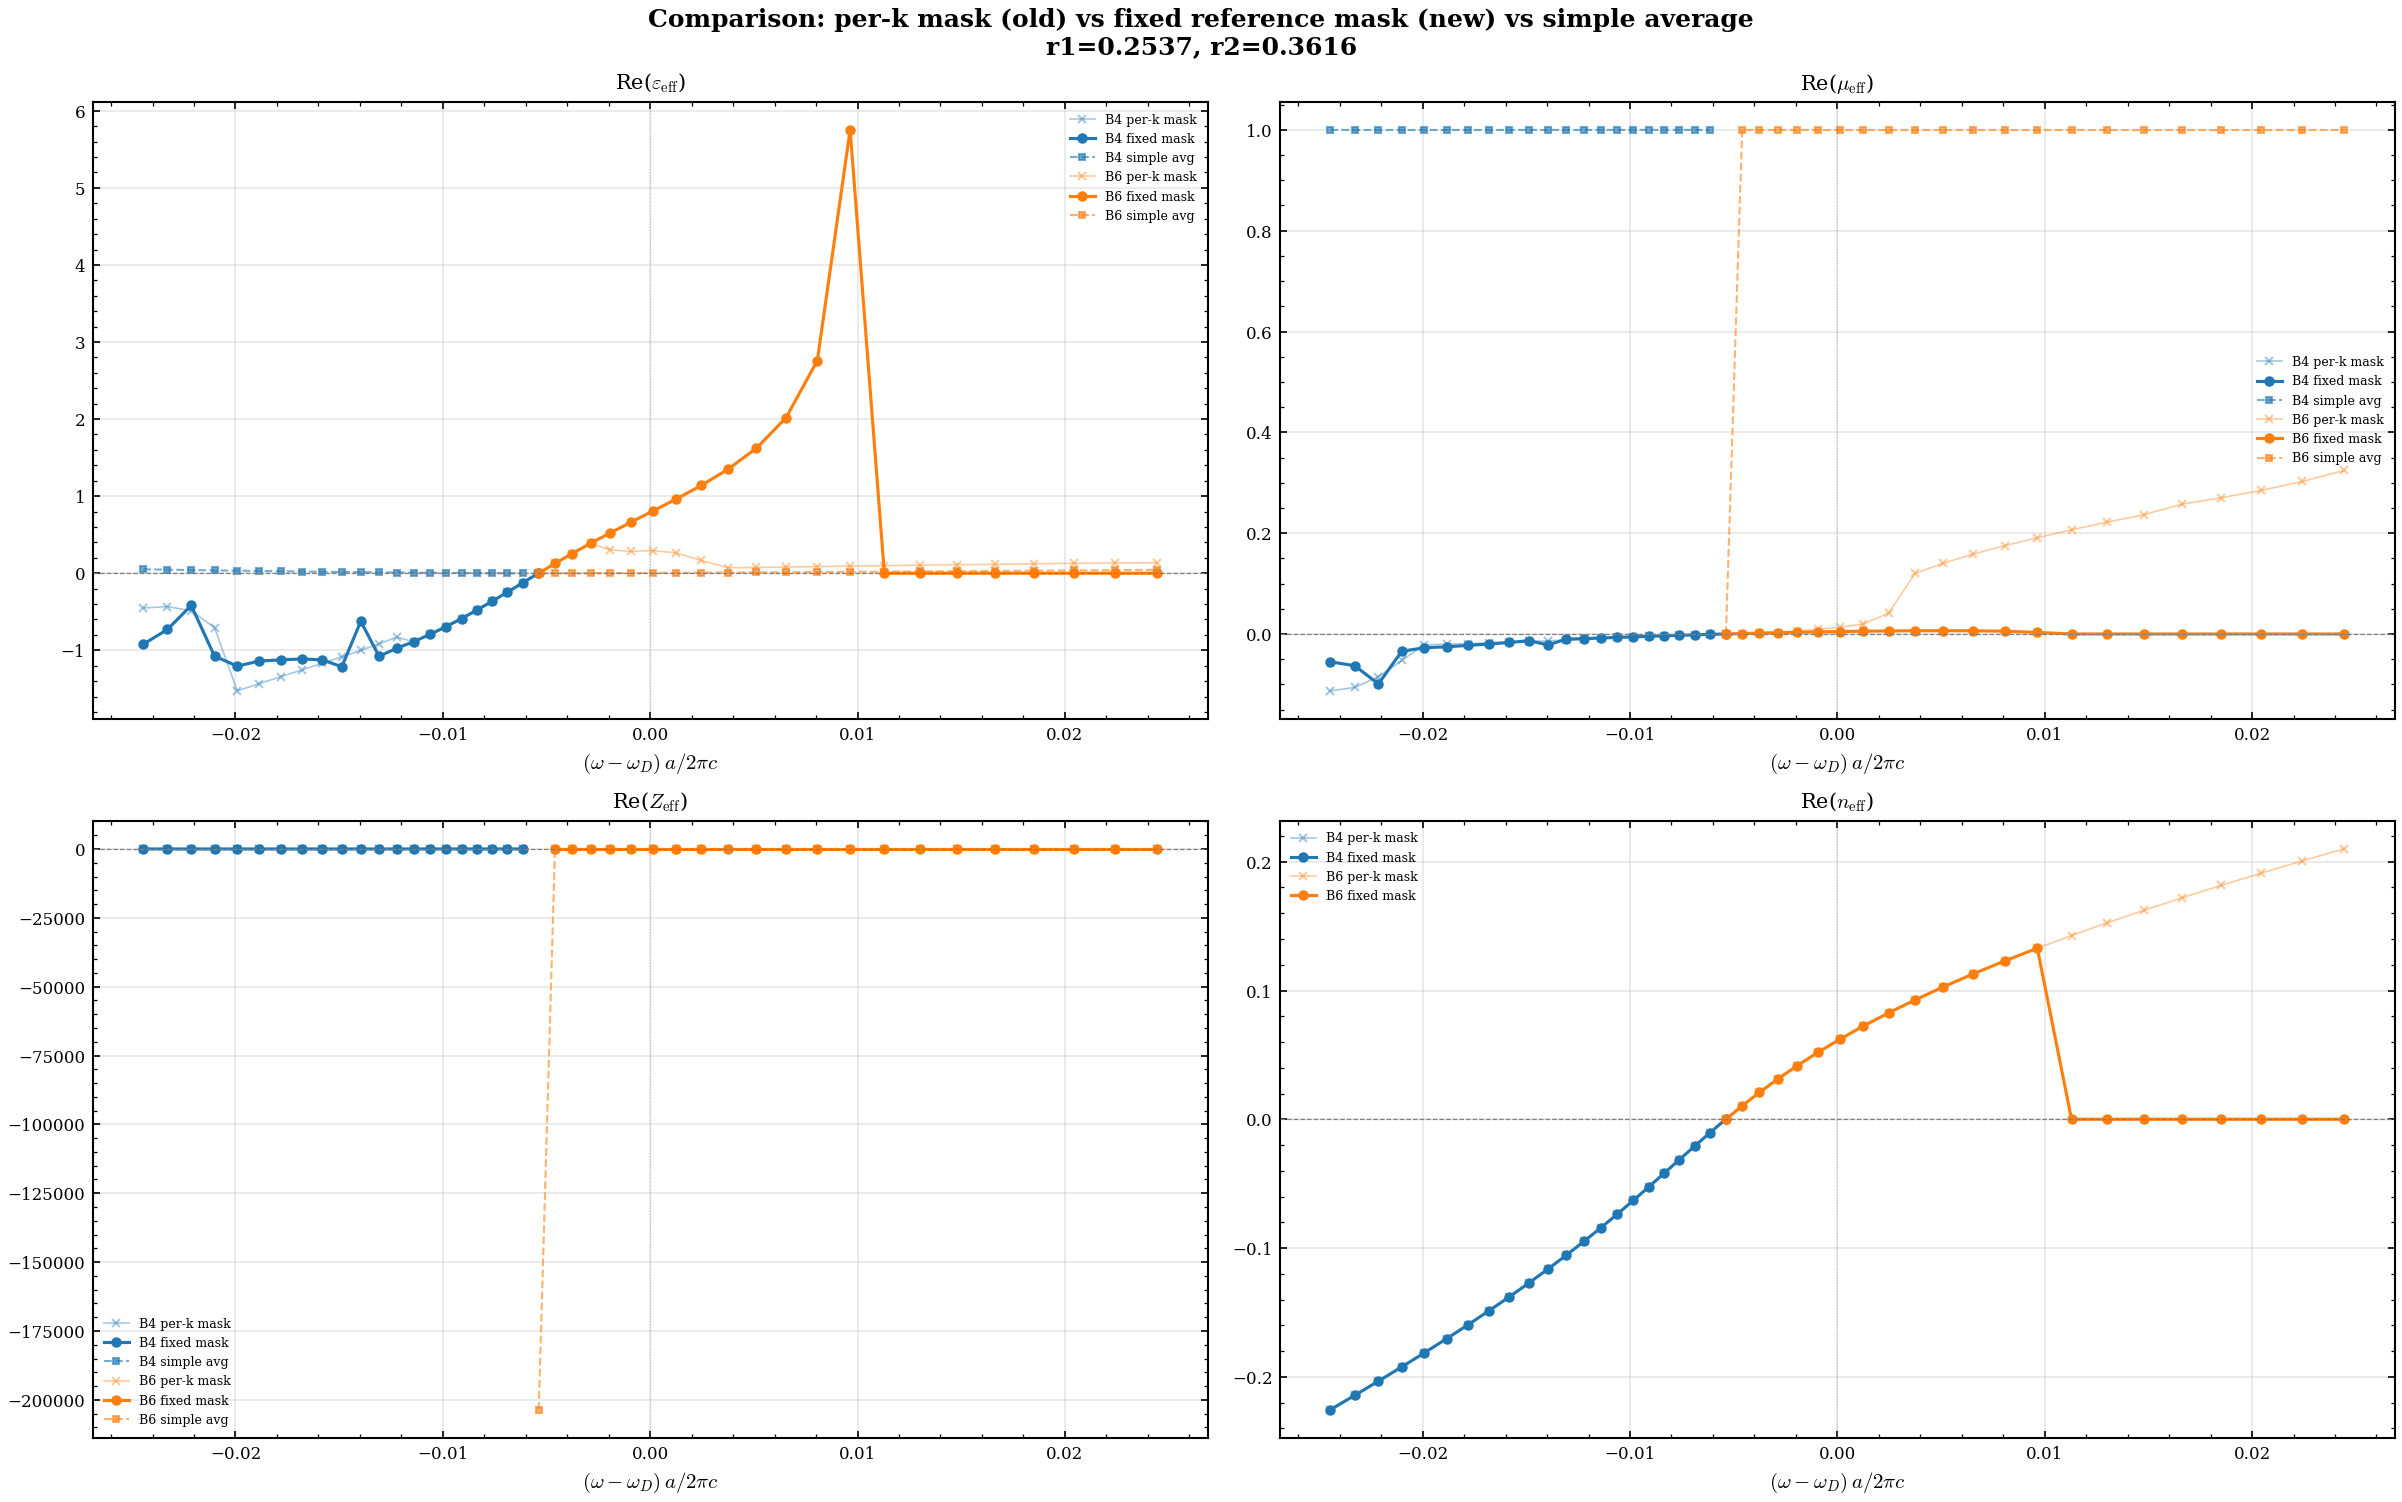

In [23]:
# ===========================================================================
# Test the FIXED reference-mask approach
# Reloads the updated FieldAnalyzer module and compares:
#   old method (per-k mask)  vs  new method (fixed mask from largest k)
#   vs  simple-average method (no mask at all)
# ===========================================================================
import importlib
import phc_nzi.field_analyzer as fa
importlib.reload(fa)

import numpy as np
import matplotlib.pyplot as plt

# --- Recompute with the updated FieldAnalyzer (reference mask) ---
analyzer_fixed = fa.FieldAnalyzer(sim_peak, [4, 6], "te", "x")
df_fixed = analyzer_fixed.get_eps_mu_impedance_neff("y", "z", plot=False, use_reference_mask=True)

# Compute shifted frequency
k_min_f = df_fixed['k_index'].min()
f4 = df_fixed.loc[(df_fixed['band'] == 4) & (df_fixed['k_index'] == k_min_f), 'frequency'].values[0]
f6 = df_fixed.loc[(df_fixed['band'] == 6) & (df_fixed['k_index'] == k_min_f), 'frequency'].values[0]
oD = 0.5 * (f4 + f6)
df_fixed['freq_shifted'] = df_fixed['frequency'] - oD

# --- Also recompute WITHOUT reference mask for comparison ---
analyzer_old = fa.FieldAnalyzer(sim_peak, [4, 6], "te", "x")
df_old_new = analyzer_old.get_eps_mu_impedance_neff("y", "z", plot=False, use_reference_mask=False)
df_old_new['freq_shifted'] = df_old_new['frequency'] - oD

# ===========================================================================
# Compare all three methods
# ===========================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
band_colors = {4: 'C0', 6: 'C1'}

for band in [4, 6]:
    c = band_colors[band]

    old = df_old_new[df_old_new['band'] == band].sort_values('freq_shifted')
    fix = df_fixed[df_fixed['band'] == band].sort_values('freq_shifted')
    avg = df_scratch[df_scratch['band'] == band].sort_values('freq_shifted')

    # ε_eff
    axes[0, 0].plot(old['freq_shifted'], np.real(old['eps']),
                    'x-', color=c, ms=4, lw=0.8, alpha=0.4, label=f'B{band} per-k mask')
    axes[0, 0].plot(fix['freq_shifted'], np.real(fix['eps']),
                    'o-', color=c, ms=4, lw=1.5, label=f'B{band} fixed mask')
    axes[0, 0].plot(avg['freq_shifted'], np.real(avg['eps']),
                    's--', color=c, ms=3, lw=1, alpha=0.6, label=f'B{band} simple avg')

    # μ_eff
    axes[0, 1].plot(old['freq_shifted'], np.real(old['mu']),
                    'x-', color=c, ms=4, lw=0.8, alpha=0.4, label=f'B{band} per-k mask')
    axes[0, 1].plot(fix['freq_shifted'], np.real(fix['mu']),
                    'o-', color=c, ms=4, lw=1.5, label=f'B{band} fixed mask')
    axes[0, 1].plot(avg['freq_shifted'], np.real(avg['mu']),
                    's--', color=c, ms=3, lw=1, alpha=0.6, label=f'B{band} simple avg')

    # Z_eff
    axes[1, 0].plot(old['freq_shifted'], np.real(old['impedance']),
                    'x-', color=c, ms=4, lw=0.8, alpha=0.4, label=f'B{band} per-k mask')
    axes[1, 0].plot(fix['freq_shifted'], np.real(fix['impedance']),
                    'o-', color=c, ms=4, lw=1.5, label=f'B{band} fixed mask')
    axes[1, 0].plot(avg['freq_shifted'], np.real(avg['Z']),
                    's--', color=c, ms=3, lw=1, alpha=0.6, label=f'B{band} simple avg')

    # n_eff
    axes[1, 1].plot(old['freq_shifted'], np.real(old['n_eff']),
                    'x-', color=c, ms=4, lw=0.8, alpha=0.4, label=f'B{band} per-k mask')
    axes[1, 1].plot(fix['freq_shifted'], np.real(fix['n_eff']),
                    'o-', color=c, ms=4, lw=1.5, label=f'B{band} fixed mask')

titles = [r'Re($\varepsilon_{\mathrm{eff}}$)', r'Re($\mu_{\mathrm{eff}}$)',
          r'Re($Z_{\mathrm{eff}}$)', r'Re($n_{\mathrm{eff}}$)']
for i, ax in enumerate(axes.flat):
    ax.set_xlabel(r'$(\omega - \omega_D)\, a/2\pi c$')
    ax.set_title(titles[i])
    ax.axhline(0, color='gray', ls='--', lw=0.6)
    ax.axvline(0, color='gray', ls=':', lw=0.5, alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=6, loc='best')

fig.suptitle('Comparison: per-k mask (old) vs fixed reference mask (new) vs simple average\n'
             f'r1={peak_point["r1"]:.4f}, r2={peak_point["r2"]:.4f}',
             fontsize=12, fontweight='bold')
plt.show()

# Slab

## Optimization

In [ ]:
import concurrent.futures
import time

# Assume 'name' and 'script_slab' are defined elsewhere
pop = numproc // 2
h_array = [0.25, 0.3, 0.35, 0.4,0.45, 0.5, 0.55]


df_array= []
def run_optimization(h):
    opt_name = simulation_slab_opt.simulation_name + f"_p64_h_{h:0.3f}"
    optimizer = MPIdeOptimizator(
        simulation_name=opt_name,
        scheme_script=simulation_slab_opt.script,
        maxiter=15,
        param_names=["r1", "r2"],
        param_bounds=[(0.15, 0.35), (0.1, 0.35)],
        polarization="zeven",
        de_options={"strategy": "rand1bin", "popsize": pop},
        bands=[8, 9, 10],
        height_slab=h,
        directory=os.path.join(data_rooth, opt_name)
    )
    # Submit the LSF job.
    try:
        #optimizer.erease_data_file()
        pass
    except:
        pass
    #optimizer.submit_lsf_job(lsf_config)
    try:
        data_file = optimizer.data_file
        analyzer = OptimizationDataAnalyzer(data_file)
        # plt.figure()
        # analyzer.plot_raw_data(plot_inverse_cost=True, points_only=True, use_logscale=True)        
        # plt.close()
        # plt.figure()
        # analyzer.plot_optimization_points_freq_dirac(points_only=True)
        
        # plt.close()

        df = analyzer.get_points_above_treshold(1200)
        df["h"] = h
        df_array.append(df)

    except Exception as e:
        print(f"An error occurred while analyzing the data: {e}")

#Use ThreadPoolExecutor to run jobs concurrently with a small delay between job submissions.
with concurrent.futures.ThreadPoolExecutor() as executor:
    futures = []
    for h in h_array:
        futures.append(executor.submit(run_optimization, h))
        time.sleep(1)  # Add a small delay between submissions
    concurrent.futures.wait(futures)

In [ ]:
figure_ellipses = plt.figure(figsize=(12, 8))
figure_ellipses_no_point = plt.figure(figsize=(12, 8))
threshold = 1000
h_array = [0.25, 0.3, 0.35, 0.4, 0.5]
plt.figure(figure_ellipses)

plt.figure(figure_ellipses_no_point)
for h in h_array:
    try: 
        h_norm = (h - min(h_array)) / (max(h_array) - min(h_array))
    except:
        h_norm = 1
    path_data_file  = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_{h:0.3f}/{name_slab_opt}_p64_h_{h:0.3f}.de.data")
    analyzer = OptimizationDataAnalyzer(path_data_file)
    df = analyzer.get_points_above_treshold(threshold)
    a = analyzer.fit_ellipse(df["r1"], df["r2"], 1/df["cost"]) 
    plt.figure(figure_ellipses_no_point)
    analyzer.plot_ellipse_from_conic(*a, plot_kwds={"color": [h_norm , 0, 0], "label": f"$h/a = {h}$"})

plt.title(f"Dirac-like Points Ellipses, PHC Slab")
# equal axes
plt.axis("equal")
plt.legend()
plt.grid()
plt.xlabel("$r_1/a$")
plt.ylabel("$r_2/a$")
plt.show()




In [ ]:
lambda0 = 1550
threshold = 1000
plt.rcParams["font.size"] = 18

## 0.25
fig1 = plt.figure(figsize=(10, 6))
fig2 = plt.figure(figsize=(10, 6))


colors = ["viridis", "plasma", "inferno", "magma", "cividis", "Greens"]
for i, h in enumerate([ 0.25 ]):
    param2_delim = 0.25 if i >= 1 else 0.24
    param1_delim = 1    if i >= 1 else 0.24
    

    path_data_opt = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_{h:0.3f}/{name_slab_opt}_p64_h_{h:0.3f}.de.data")
    analyzer = OptimizationDataAnalyzer(path_data_opt)
    x, y, f, aa = analyzer.compute_freq_dirac_along_ellipse(threshold=threshold, n_points = 1000)
    plt.figure(fig1)
    plt.scatter(x, f, c = y, cmap=colors[i], label=f"$h/a = {h}$", s=30)

    
    
plt.figure(fig1)
plt.title(f"Dirac-Like Points Frequencies at $h/a = {h}, T={T}K$\n vs $r_1/a$ and $r_2/a$")
plt.grid()
plt.xlabel("$r_1/a$")
plt.ylabel("$\omega_{{D}}a/2\pi c$")
plt.colorbar(label="$r_2/a$")
plt.show()

for i, h in enumerate([ 0.25, 0.30, 0.35, 0.40, 0.50]):
    param2_delim = 0.25 if i >= 1 else 0.24
    param1_delim = 1    if i >= 1 else 0.24
    

    path_data_opt = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_{h:0.3f}/{name_slab_opt}_p64_h_{h:0.3f}.de.data")
    analyzer = OptimizationDataAnalyzer(path_data_opt)
    x, y, f, aa = analyzer.compute_freq_dirac_along_ellipse(threshold=threshold, n_points = 1000)
    plt.figure(fig2)
    filling_factor =1- (x**2*np.pi + y**2*np.pi)
    plt.plot(filling_factor, f, "-", linewidth = 3, label=f"$h/a = {h}$")


plt.figure(fig2)
plt.xlabel("Filling factor")
plt.ylabel("$\omega_{{D}}a/2\pi c$")
plt.title(f"Dirac-Like Points Frequencies, $T={T}K$\n vs Filling Factor")
plt.grid()
plt.legend()
plt.show()
            

In [ ]:
path_data_file = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_0.350/{name_slab_opt}_p64_h_0.350.de.data")
analyzer = OptimizationDataAnalyzer(path_data_file)
points = analyzer.get_points_above_treshold(1000)
#display(points)
print(analyzer.compute_param2_from_param1_on_ellipse(0.23,branch="lower", threshold=1000))

In [ ]:
lam0 = 1550
threshold = 1000


## 0.35
ms = 8

f_mins = []
f_maxs = []
hs = []
for i, h in enumerate([0.25, 0.3, 0.35, 0.4, 0.5 ]):
    param2_delim = 0.25 if i >= 1 else 0.24
    param1_delim = 1    if i >= 1 else 0.24
   

    path_data_opt = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_{h:0.3f}/{name_slab_opt}_p64_h_{h:0.3f}.de.data")
    analyzer = OptimizationDataAnalyzer(path_data_opt)
    x, y, f, aa = analyzer.compute_freq_dirac_along_ellipse(threshold=threshold)

    f_min = np.min(f)
    f_max = np.max(f)
    f_mins.append(f_min)
    f_maxs.append(f_max)
    hs.append(h)

wN_ll = []
for x in hs:
    h_phy = [ 220, 250, 280, 310, 340]
    lam = 1550
    wN_l = []
    for hi in h_phy:
        wN = hi/ lam / x
        wN_l.append(wN)
    wN_ll.append(wN_l)
wN_ll = np.array(wN_ll)



plt.figure()
for hi in h_phy: 
    lam_mins = []
    lam_maxs = []
    for x, fmin, fmax in zip(hs, f_mins, f_maxs):
        lam_min = hi/fmin/x
        lam_max = hi/fmax/x
        lam_mins.append(lam_min)
        lam_maxs.append(lam_max)
    plt.fill_between(hs, lam_mins, lam_maxs, alpha=0.2, label=f"$h = {hi}nm$")

plt.hlines(lam0, min(hs), max(hs), color="red", linestyle="--", label=f"$\lambda_0 = {lam0}nm$")
plt.xlabel("$h/a$")
plt.ylabel("$\lambda_D(h,a)$ (nm)")
plt.title(f"Dirac-like cones Bands vs $h/a$, $T={T}K$")
plt.legend()
plt.grid(True)
plt.show()

    

In [ ]:
lambda0 = 1550
threshold = 1000

## 0.25

for i, h in enumerate([0.25]):
    param2_delim = 0.25 if i >= 1 else 0.24
    param1_delim = 1    if i >= 1 else 0.24
    plt.rcParams["font.size"] = 15
    figure_freq_dirac, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)   
    plt.sca(axes[0])    
    path_data_opt = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_{h:0.3f}/{name_slab_opt}_p64_h_{h:0.3f}.de.data")
    analyzer = OptimizationDataAnalyzer(path_data_opt)
    x, y, f, aa = analyzer.compute_freq_dirac_along_ellipse(threshold=threshold)
    analyzer.plot_freq_dirac_along_ellipse(threshold=threshold)
    lams = [   1518, 1529]
    xlim = plt.xlim()
    ylim = plt.ylim()  
    h_phy = 250
    for lam in lams:
        w_target = h_phy / lam/h
        if w_target < ylim[1]*1.1 and w_target > ylim[0]*0.9:   
            plt.hlines(w_target, xlim[0], xlim[1], color = "red", linestyle = "--")
            plt.text(xlim[0], w_target+0.0002, f"$\lambda = {lam:0.0f}$ nm @ $h=250$ nm", color = "red", fontsize=14)

    h_phy_array = [ 253, 256]
    for h_phy_i in h_phy_array:
        w_target = h_phy_i / lambda0/h
        if w_target < ylim[1]*1.1 and w_target > ylim[0]*0.9:   
            plt.hlines(w_target, xlim[0], xlim[1], color = "blue", linestyle = "--")
            plt.text(xlim[0], w_target+0.0002, f"$h = {h_phy_i:0.0f}$ nm @ $\lambda = 1550$ nm", color = "blue", fontsize=14)
    plt.title(f"Dirac Points Frequencies at $h/a = {h}, T={T}K$\n")
    plt.grid()
    plt.xlabel("$r_1/a$")
    plt.ylabel("$\omega_{{D}}a/2\pi c$")
    colorbar = plt.colorbar() 
    colorbar.set_label("$r_2/a$")   



    plt.sca(axes[1])
    param1, param2, gradient, a= analyzer.compute_gradient_along_ellipse(threshold=threshold)
    mask = (param2 < param2_delim) & (param1 < param1_delim)
    param1_lower = param1[mask]
    param2_lower = param2[mask]
    f_lower = f[mask]
    gradient_lower = gradient[mask]
    idx_min = np.argmin(np.abs(gradient_lower))
    c = analyzer.plot_gradient_along_ellipse(threshold=threshold, abs = True)
    c.set_label("Gradient, abs, normalized")
    points = analyzer.get_points_above_treshold(threshold)
    # plt.scatter(points["r1"], points["r2"], c=1/points["cost"], cmap="viridis",
    #             norm=colors.LogNorm(vmin=(1/points["cost"]).min(), vmax=(1/points["cost"]).max()))
    plt.plot(param1_lower[idx_min], param2_lower[idx_min], "ro", label=f"Local Minimum, $r_1/a = {param1_lower[idx_min]:0.3f}$, $r_2/a = {param2_lower[idx_min]:0.3f}$")
    plt.text(param1_lower[idx_min]+0.001, param2_lower[idx_min]-0.0015, f"$r_1/a = {param1_lower[idx_min]:0.3f}$,\n$r_2/a = {param2_lower[idx_min]:0.3f}$,\n$\omega_Da/2\pi c = {f_lower[idx_min]:0.3f}$", color = "black", fontsize=14)
    plt.title(f"Dirac Points Gradient at $h/a= {h}, T={T}K$\n")
    plt.xlabel("$r_1/a$")
    plt.ylabel("$r_2/a$")
    plt.grid()



    plt.sca(axes[0])
    f_lower = f[mask]   
   
    lam = h_phy/h/f_lower[idx_min]

    plt.hlines(f_lower[idx_min], xlim[0], xlim[1], color = "red", linestyle = "--")
    plt.text(xlim[0], f_lower[idx_min]+0.0002, f"$\lambda = {lam:0.0f}$ nm @ $h=250$ nm", color = "red", fontsize=14)
    plt.plot(param1_lower[idx_min], f_lower[idx_min], "ro", label = f"$r_1/a = {param1_lower[idx_min]:0.3f}$,\n $\omega_Da/2\pi c = {f_lower[idx_min]:0.3f}$")
    plt.text(param1_lower[idx_min], f_lower[idx_min]-0.0015, f"$r_1/a = {param1_lower[idx_min]:0.3f}$,\n$r_2/a = {param2_lower[idx_min]:0.3f}$,\n$\omega_Da/2\pi c = {f_lower[idx_min]:0.3f}$", color = "black", fontsize=14)
            
    # legend = plt.legend(loc = "upper right") if i == 0 else plt.legend(loc = "lower right")
    
 
    plt.show()





In [ ]:
lambda0 = 1550
threshold = 1000

## 0.35
ms = 8
for i, h in enumerate([0.35]):
    param2_delim = 0.25 if i >= 1 else 0.24
    param1_delim = 1    if i >= 1 else 0.24
    plt.rcParams["font.size"] = 15
    figure_freq_dirac, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)   
    plt.sca(axes[0])    
    path_data_opt = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_{h:0.3f}/{name_slab_opt}_p64_h_{h:0.3f}.de.data")
    analyzer = OptimizationDataAnalyzer(path_data_opt)
    x, y, f, aa = analyzer.compute_freq_dirac_along_ellipse(threshold=threshold)
    analyzer.plot_freq_dirac_along_ellipse(threshold=threshold)
    lams = [1580, 1490]
    xlim = plt.xlim()
    ylim = plt.ylim()  
    h_phy = 330
    for lam in lams:
        w_target = h_phy / lam/h
        if w_target < ylim[1]*1.1 and w_target > ylim[0]*0.9:   
            plt.hlines(w_target, xlim[0], xlim[1], color = "red", linestyle = "--")
            plt.text(xlim[0], w_target+0.001, f"$\lambda = {lam:0.0f}$ nm @ $h={h_phy}$ nm", color = "red", fontsize=14)

    h_phy_array = [ 320,  340]
    for h_phy_i in h_phy_array:
        w_target = h_phy_i / lambda0/h
        if w_target < ylim[1]*1.1 and w_target > ylim[0]*0.9:   
            plt.hlines(w_target, xlim[0], xlim[1], color = "blue", linestyle = "--")
            plt.text(xlim[0], w_target+0.001, f"$h = {h_phy_i:0.0f}$ nm @ $\lambda = {lambda0}$ nm", color = "blue", fontsize=14)
    plt.title(f"Dirac Points Frequencies at $h/a = {h}, T={T}K$\n")
    plt.grid()
    plt.xlabel("$r_1/a$")
    plt.ylabel("$\omega_{{D}}a/2\pi c$")
    colorbar = plt.colorbar() 
    colorbar.set_label("$r_2/a$")   

   

    plt.sca(axes[1])
    param1, param2, gradient, a= analyzer.compute_gradient_along_ellipse(threshold=threshold)
    mask = (param2 < param2_delim) & (param1 < param1_delim)
    param1_lower = param1[mask]
    param2_lower = param2[mask]
    gradient_lower = gradient[mask]
    idx_min = np.argmin(np.abs(gradient_lower))
    c = analyzer.plot_gradient_along_ellipse(threshold=threshold, abs = True)
    c.set_label("Gradient, abs, normalized")
    points = analyzer.get_points_above_treshold(threshold)
    # plt.scatter(points["r1"], points["r2"], c=1/points["cost"], cmap="viridis",
    #             norm=colors.LogNorm(vmin=(1/points["cost"]).min(), vmax=(1/points["cost"]).max()))
    plt.plot(param1_lower[idx_min], param2_lower[idx_min], "ro", label=f"Local Minimum, $r_1/a = {param1_lower[idx_min]:0.3f}$, $r_2/a = {param2_lower[idx_min]:0.3f}$", markersize=ms)
    plt.text(param1_lower[idx_min]+0.001, param2_lower[idx_min]-0.0015, f"$r_1/a = {param1_lower[idx_min]:0.3f}$,\n$r_2/a = {param2_lower[idx_min]:0.3f}$,\n$\omega_Da/2\pi c = {f_lower[idx_min]:0.3f}$", color = "black", fontsize=14)
    plt.title(f"Dirac Points Gradient at $h/a= {h}, T={T}K$\n")
    plt.xlabel("$r_1/a$")
    plt.ylabel("$r_2/a$")
    plt.grid()



    plt.sca(axes[0])
    f_lower = f[mask]   
   
    lam = h_phy/h/f_lower[idx_min]

    plt.hlines(f_lower[idx_min], xlim[0], xlim[1], color = "red", linestyle = "--")
    plt.text(xlim[0], f_lower[idx_min]+0.001, f"$\lambda = {lam:0.0f}$ nm @ $h={h_phy}$ nm", color = "red", fontsize=14)
    plt.plot(param1_lower[idx_min], f_lower[idx_min], "ro", label = f"$r_1/a = {param1_lower[idx_min]:0.3f}$,\n $\omega_Da/2\pi c = {f_lower[idx_min]:0.3f}$", markersize = ms)
    #plt.text(param1_lower[idx_min], f_lower[idx_min]-0.0015, f"$r_1/a = {param1_lower[idx_min]:0.3f}$,\n$r_2/a = {param2_lower[idx_min]:0.3f}$,\n$\omega_Da/2\pi c = {f_lower[idx_min]:0.3f}$", color = "black", fontsize=14)
            
    # legend = plt.legend(loc = "upper right") if i == 0 else plt.legend(loc = "lower right")
    
 
    plt.show()





In [ ]:
r1 = 0.24
hh = 0.25
path_data_file = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_{hh:.3f}/{name_slab_opt}_p64_h_{hh:.3f}.de.data")
analyzer = OptimizationDataAnalyzer(path_data_file)
r2 = analyzer.compute_param2_from_param1_on_ellipse(r1, threshold=1000, branch = "lower")
print(r2)


## Sweep

In [ ]:
# Instantiate the new sweeper
print("h:", hh, ", r1:", r1, ", r2:", r2)
# from nzi_phc.lsf_sweeper import LSFSweeper
values = np.linspace(0.225, 0.245, 64, endpoint=True)
sweeper = LSFSweeper(simulation_slab_sweep.simulation_name + "_r2", directory=simulation_slab_sweep.directory + "_r2",
                     scheme_script=simulation_slab_sweep.script, 
                        param_name="r2", param_values=values,
                        polarization="zeven",
                        bands=[8,9,10],
                        others_command_line_params={"r1": r1, "h": hh},
                       )

#Run the sweeper
# sweeper.submit_lsf_job(lsf_config)

In [ ]:
df = sweeper.load_results()
#display(df)
print(r1,r2)
plt.figure()

plt.plot(df["r2"], df["band_8"], label="band 8")
plt.plot(df["r2"], df["band_9"], label="band 9")
plt.plot(df["r2"], df["band_10"], label="band 10")
h_phy = 250

plt.grid()
plt.xlabel("$r_2/a$")
plt.ylabel("$\omega_Da/2\pi c$")
ylim = plt.ylim()
plt.plot([r2, r2], ylim, "r--", label = f"$r_2/a = {r2:0.4f}$")
idx_freq_dirac = np.argmin(np.abs(df["band_10"] - df["band_8"]))
lamX = h_phy / hh / df["band_9"][idx_freq_dirac]
plt.plot(df["r2"][idx_freq_dirac], df["band_8"][idx_freq_dirac], "go", label = f"$r_2/a ={df['r2'][idx_freq_dirac]:0.4f}$, $\omega_Da/2\pi c = {df['band_8'][idx_freq_dirac]:0.4f}$, \n $h_{{phy}} =  {h_phy} nm$, $\lambda = {lamX:0.2f} nm$") 
plt.title(f"Sweep of $r_2$ at $h/a = {hh}$ and $r_1/a = {r1:0.4f}$, $T={T}K$")
plt.legend()
plt.savefig(f"sweep_r2_h_0.35_r1_{r1:0.4f}.png")
plt.show()

c0 = 299792458


## Optimized

In [ ]:

#lsf_config = LSFJobConfiguration(num_processors=4, span_option="hosts", span_value=1, queue="fotonano")
# import time
# time.sleep(1)
r1 = 0.24
r2 = 0.2390
hh=0.25
plt.rcParams["font.size"] = 20
#simulation_slab.run_hpc_lsf(mpb_command_line_params=dict(r1 = r1, r2 = r2, h=hh), LSFOptions=lsf_config)
plt.rcParams["lines.linewidth"] = 2
viewer_slab = SimulationViewer(simulation_slab) 
opt = MPBDataOptions(rectify=True, periods=(3,3,1))
plt.figure(figsize=(12, 8))
viewer_slab.plot_epsilon_3d(conversion_options=opt)
# Increase the distance between the labels and the axes
plt.xlabel("$points \qquad x$", labelpad=15)
plt.ylabel("$points \qquad y$", labelpad=15)
ax = plt.gca()
ax.set_zlabel("$points \qquad z$", labelpad=15)

plt.title(f"Dielectric Distribution - $C_{{4v}}$ diatomic slab \n$r_1/a ={r1}$, $r_2/a = {r2}$, $h/a = {hh}$, $T={T}K$")
plt.xlabel("$points \qquad x$")
plt.ylabel("$points \qquad y$")
ax = plt.gca()
ax.set_zlabel("$points \qquad z$")
viewer_slab.show()
plt.figure(figsize=(12, 8))
viewer_slab.simulation.extract_frequencies()
viewer_slab.plot_band_diagram("zeven", k_points_path=k_points, color = "red", custom_label="TE-like bands")
#viewer_2D.plot_band_diagram("tm", k_points_path=k_points, color = "blue")
plt.title(f"Band Diagram - $C_{{4v}}$ diatomic slab \n$r_1/a ={r1}$, $r_2/a = {r2}$, $h/a = {hh}$, $T={T}K$")
plt.ylabel("$\omega a/2\pi c$")
df = simulation_slab.load_frequency_data("zeven")
viewer_slab.plot_light_cone(df)



# viewer_slab.show()
# figure, axes = plt.subplots(1, 3, figsize=(20, 6))

# data_line_slab = f"$r_1/a ={r1}$, $r_2/a = {r2}$, $h/a = {hh}$, $T={T}K$"
# plt.figure()
# c = viewer_slab.plot_field_2d(1, 10, "h", "z", "zeven", False, np.abs) 
# plt.title("Magnetic Field Distribution - $C_{4v}$ diatomic slab - Optimized \n" + data_line_slab + " - Band 10")
# c.set_label("$|H_{z}|$ (a.u.)")
# plt.figure()
# c = viewer_slab.plot_field_2d(1, 9, "h", "z", "zeven", False, np.abs)
# plt.title("Magnetic Field Distribution - $C_{4v}$ diatomic slab - Optimized \n" + data_line_slab + " - Band 9")
# c.set_label("$|H_{z}|$ (a.u.)") 
# plt.figure()
# c = viewer_slab.plot_field_2d(1, 8, "h", "z", "zeven", False, np.abs)
# plt.title("Magnetic Field Distribution - $C_{4v}$ diatomic slab - Optimized \n" + data_line_slab+ " - Band 8")
# c.set_label("$|H_{z}|$ (a.u.)")
# plt.show()






In [ ]:
#lsf_config = LSFJobConfiguration(num_processors=4, span_option="hosts", span_value=1, queue="fotonano")
# import time
# time.sleep(1)
r1 = 0.24
r2 = 0.2390
hh = 0.25

#simulation_slab_opt_centered.run_hpc_lsf(mpb_command_line_params=dict(r1 = r1, r2 = r2, h=hh), LSFOptions=lsf_config)

plt.rcParams["lines.linewidth"] = 2
viewer_slab = SimulationViewer(simulation_slab_opt_centered) 
opt = MPBDataOptions(rectify=True, periods=(3,3,1))
viewer_slab.figure()
viewer_slab.simulation.extract_frequencies()
viewer_slab.plot_band_diagram("zeven", k_points_path=k_points_around_gamma, color = "red", custom_label="TE-like bands")
#viewer_2D.plot_band_diagram("tm", k_points_path=k_points, color = "blue")
plt.title(f"Band Diagram - $C_{{4v}}$ diatomic slab \n$r_1/a ={r1}$, $r_2/a = {r2}$, $h/a = {hh}$, $T={T}K$")
plt.ylabel("$\omega a/2\pi c$")
ax = plt.gca()
ax.set_xticklabels([f"$k_x a/2\pi$={distance}", "$\Gamma$", f"$k_y a/2\pi={distance}$"])
df = simulation_slab_opt_centered.load_frequency_data("zeven")
viewer_slab.plot_light_cone(df)
plt.ylim(0.64,0.68)
viewer_slab.show()


In [ ]:
visualizer_slab = SimulationViewer(simulation_slab_opt_centered)
plt.figure(figsize=(12, 8))
visualizer_slab.plot_field_2d(12, 8, "h", "z", "zeven", False, np.real)
plt.figure(figsize=(12, 8))
visualizer_slab.plot_field_2d(12, 9, "h", "z", "zeven", False, np.real)
plt.figure(figsize=(12, 8))
visualizer_slab.plot_field_2d(12, 10, "h", "z", "zeven", False, np.real)
plt.show()

In [ ]:
df = simulation_slab_opt_centered.load_frequency_data("zeven")
display(df)

plt.rcParams["font.size"] =30

def plot_field(k_idx, b_idx):
    opt = MPBDataOptions(rectify=True, periods= (3,3,1), transpose = False)
    # Load H-field (magnetic field) and E-field (electric field) components
    H_field = simulation_slab_opt_centered.load_and_convert_field_data(k_idx, b_idx, "z", "zeven", "h", conversion_options=opt)
    # E_field_x = simulation_slab_opt_centered.load_and_convert_field_data(k_idx, b_idx, "x", "zeven", "e", conversion_options=opt)
    # E_field_y = simulation_slab_opt_centered.load_and_convert_field_data(k_idx, b_idx, "y", "zeven", "e", conversion_options=opt)
    H_field = H_field[..., H_field.shape[2]//2-1]  # Take the middle slice for 2D visualization
    



    # Plot E-field as vectors with H-field as background
    plt.figure(figsize=(10, 10))
    # Background: H-field magnitude
    plt.imshow(np.real(H_field), interpolation='spline36', cmap="bwr")
    plt.colorbar(label="$H_{z}$ (real part, a.u.)", 
                 shrink=0.8, pad=0.01, aspect=20)
    
    # Prepare grid for quiver plot - subsample for clarity
    nx, ny = H_field.shape
    step = max(1, nx//30)  # Adjust arrow density
    X, Y = np.meshgrid(np.arange(0, nx, step), np.arange(0, ny, step))
    
    # # Sample E-field components
    # Ex = np.real(E_field_x[::step, ::step])
    # Ey = np.real(E_field_y[::step, ::step])
    
    # # Normalize arrows for better visualization
    # E_magnitude = np.sqrt(Ex**2 + Ey**2)
    # max_magnitude = np.max(E_magnitude)
    # if max_magnitude > 0:
    #     Ex = Ex / max_magnitude
    #     Ey = Ey / max_magnitude
    
    # # Plot vector field
    # plt.quiver(X, Y, Ex, Ey, angles='xy', scale=30, color='black', label="$E$-field vectors")
    # plt.legend(loc = "upper right")
    
    # Set plot title and labels
    
    plt.title(f"Band {b_idx}")
    plt.xlabel("x points")
    plt.ylabel("y points")
    # Draw grid lines every 64 points
    for i in range(0, nx, 64):
        plt.axvline(i, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    for j in range(0, ny, 64):
        plt.axhline(j, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    plt.show()


plot_field(12, 8)
plot_field(12, 9)
plot_field(12, 10)
